\setcounter{secnumdepth}{0}

# Assignment 1: Predictive Modelling and Inference
## Marketing Campaign Response Prediction

---

**Student ID:** 34560351

**Name:** Machrizal Perdana Putra

**Course:** ITI5149  

**Dataset:** Marketing Campaign Dataset  

---
### Dataset Summary
This study uses Kaggle’s Customer Personality Analysis dataset (marketing_campaign.csv), which includes customer demographics, spending and purchase behavior, and campaign acceptance history (Response as the target).

https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis/data


### Problem Statement
This analysis aims to predict whether a customer will respond positively to a marketing campaign based on their demographic information, purchase behavior, and historical campaign responses. The target variable is `Response` (1 = accepted the offer, 0 = did not accept).

### Objectives
1. **Prediction Task:** Develop accurate classifiers to predict campaign response
2. **Inference Task:** Identify key factors that influence customer response to marketing campaigns

### Methodology Overview
- **Data Preparation:** Cleaning, encoding, normalization with creative outlier handling
- **EDA:** Comprehensive analysis with clustering and visualization
- **Feature Engineering:** Interaction terms, cluster labels, PCA components
- **Model Training:** Logistic Regression, Random Forest, XGBoost
- **Model Evaluation:** Cross-validation with multiple metrics
- **Inference:** SHAP analysis and statistical tests

---
## Step 0: Environment Setup and Library Installation

We begin by installing and importing all necessary libraries for this analysis.

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# INSTALL REQUIRED LIBRARIES (for Google Colab)

import importlib.util

def install_if_not_present(package_name):
    if importlib.util.find_spec(package_name):
        print(f"Requirement already satisfied: {package_name}")
    else:
        !pip install {package_name}

# Install data manipulation and visualization libraries
install_if_not_present('pandas')
install_if_not_present('numpy')
install_if_not_present('matplotlib')
install_if_not_present('seaborn')
install_if_not_present('missingno')

# Install machine learning and preprocessing libraries
install_if_not_present('scikit-learn')

# Install advanced ML libraries
install_if_not_present('xgboost')
install_if_not_present('lightgbm')
install_if_not_present('shap')

# Install statistical libraries
install_if_not_present('scipy')
install_if_not_present('statsmodels')

# Install imbalanced data handling
install_if_not_present('imbalanced-learn')

print("All packages checked and installed successfully!")

All packages checked and installed successfully!


In [3]:
# IMPORT ALL NECESSARY LIBRARIES


# Data manipulation and numerical operations
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno  # For missing value visualization
from matplotlib.patches import Circle
from matplotlib.colors import LinearSegmentedColormap
import plotly.graph_objects as go

# Preprocessing and feature engineering
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import ks_2samp
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import silhouette_score


# Model training
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import matplotlib.pyplot as plt

# Model evaluation
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV,
    learning_curve
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score
)

# Feature importance and model interpretation
import shap  # SHAP values for model interpretability
from sklearn.inspection import permutation_importance

# Statistical tests
from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Handling class imbalance
from imblearn.over_sampling import SMOTE

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("All libraries imported successfully!")


All libraries imported successfully!


---
## Step 1: Data Preparation

In this step, we will:
1. Load the dataset
2. Explore the data structure
3. Handle missing values using **missingno** visualization and **Median Imputation**
4. Detect and handle outliers using **Winsorization**
5. Encode categorical variables appropriately
6. Normalize numerical features

### 1.1 Load and Explore Data

in this step we read the marketing campaign dataset and prints a brief snapshot of it—how many rows and columns it contains, how the target variable (“Response”) is distributed, and the overall response rate.

In [4]:
# LOAD THE DATASET

from pathlib import Path
# Load dataset
# Define file path and load dataset
DATA_PATH = Path("/content/drive/MyDrive/marketing_campaign.csv")
# load dataset
df = pd.read_csv(DATA_PATH, sep='\t')

# Display basic information about the dataset
print("DATASET OVERVIEW")

print(f"\n Dataset Shape: {df.shape[0]} rows \u00d7 {df.shape[1]} columns")
print(f"\n Target Variable: 'Response'")
print(f"   - Response Distribution:")
print(df['Response'].value_counts())
print(f"\n   - Response Rate: {df['Response'].mean()*100:.2f}%")

DATASET OVERVIEW

 Dataset Shape: 2240 rows × 29 columns

 Target Variable: 'Response'
   - Response Distribution:
Response
0    1906
1     334
Name: count, dtype: int64

   - Response Rate: 14.91%


Here we create a summary DataFrame that profiles each column in the dataset, displaying key information: column name, data type, number and percentage of missing values, count of unique values, and a sample of the first 5 unique entries. This gives a quick overview of the dataset structure to identify potential data quality issues such as incorrect data types, missing values, and duplicates before starting analysis or modeling. The summary reveals missing values in the income variable, which will be analyzed, visualized, and imputed in the next sections.

In [5]:
# DATA TYPES AND STRUCTURE

list_item = []
for col in df.columns:
    list_item.append([
        col,
        df[col].dtype,
        df[col].isna().sum(),
        round(100*df[col].isna().sum()/len(df[col]), 2),
        df[col].nunique(),
        df[col].unique()[:5]
    ])

desc_df = pd.DataFrame(
    data=list_item,
    columns=['feature', 'data_type', 'null_values',
             'null_percentage', 'unique_values', 'unique_sample']
)

desc_df

,feature,data_type,null_values,null_percentage,unique_values,unique_sample
0,ID,int64,0,0.00,2240,"[5524, 2174, 4141, 6182, 5324]"
1,Year_Birth,int64,0,0.00,59,"[1957, 1954, 1965, 1984, 1981]"
2,Education,object,0,0.00,5,"[Graduation, PhD, Master, Basic, 2n Cycle]"
3,Marital_Status,object,0,0.00,8,"[Single, Together, Married, Divorced, Widow]"
4,Income,float64,24,1.07,1974,"[58138.0, 46344.0, 71613.0, 26646.0, 58293.0]"
5,Kidhome,int64,0,0.00,3,"[0, 1, 2]"
6,Teenhome,int64,0,0.00,3,"[0, 1, 2]"
7,Dt_Customer,object,0,0.00,663,"[04-09-2012, 08-03-2014, 21-08-2013, 10-02-201..."
8,Recency,int64,0,0.00,100,"[58, 38, 26, 94, 16]"
9,MntWines,int64,0,0.00,776,"[635, 11, 426, 173, 520]"


Then, we display the first 10 rows of the dataset to quickly verify that the data was loaded correctly

In [6]:
# DISPLAY FIRST FEW ROWS

print("\n First 10 rows of the dataset:")
df.head(10)


 First 10 rows of the dataset:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,42,98,0,42,14,2,6,4,10,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,65,164,50,49,27,4,7,3,7,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,10,56,3,1,23,2,4,0,4,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,0,24,3,3,2,1,3,0,2,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,0,6,1,1,13,1,1,0,0,20,1,0,0,0,0,0,3,11,0


Then we displays basic statistical summary for all numerical columns in the dataset.

In [7]:
# STATISTICAL SUMMARY

print("\n Statistical Summary (Numerical Variables):")
df.describe().round(2)


 Statistical Summary (Numerical Variables):


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.00,2240.00,2216.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.00,2240.0,2240.0,2240.00
mean,5592.16,1968.81,52247.25,0.44,0.51,49.11,303.94,26.30,166.95,37.53,27.06,44.02,2.33,4.08,2.66,5.79,5.32,0.07,0.07,0.07,0.06,0.01,0.01,3.0,11.0,0.15
std,3246.66,11.98,25173.08,0.54,0.54,28.96,336.60,39.77,225.72,54.63,41.28,52.17,1.93,2.78,2.92,3.25,2.43,0.26,0.26,0.26,0.25,0.11,0.10,0.0,0.0,0.36
min,0.00,1893.00,1730.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,11.0,0.00
25%,2828.25,1959.00,35303.00,0.00,0.00,24.00,23.75,1.00,16.00,3.00,1.00,9.00,1.00,2.00,0.00,3.00,3.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,11.0,0.00
50%,5458.50,1970.00,51381.50,0.00,0.00,49.00,173.50,8.00,67.00,12.00,8.00,24.00,2.00,4.00,2.00,5.00,6.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,11.0,0.00
75%,8427.75,1977.00,68522.00,1.00,1.00,74.00,504.25,33.00,232.00,50.00,33.00,56.00,3.00,6.00,4.00,8.00,7.00,0.00,0.00,0.00,0.00,0.00,0.00,3.0,11.0,0.00
max,11191.00,1996.00,666666.00,2.00,2.00,99.00,1493.00,199.00,1725.00,259.00,263.00,362.00,15.00,27.00,28.00,13.00,20.00,1.00,1.00,1.00,1.00,1.00,1.00,3.0,11.0,1.00


Based on our previous observations, we identify irrelevant columns and remove it in this step.

This step separates the dataset columns into two types: numerical columns that contain numbers (like age and income), and categorical columns that contain categories (like marital status and education).

After identifying these column types, we remove three columns from the numerical set to clean the dataset and prepare it for analysis and machine learning. The removed columns are:

ID - This is just a sequential number that has no relationship with whether a customer accepts the campaign or not.

Z_CostContact and Z_Revenue - These columns have the same value across all rows (constant values), making them useless for distinguishing customer behavior or predicting campaign outcomes.

By removing these irrelevant columns, we ensure the dataset contains only meaningful features that can contribute to our predictive models.

In [8]:
# IDENTIFY VARIABLE TYPES

# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove ID and constant columns from analysis
cols_to_remove = ['ID', 'Z_CostContact', 'Z_Revenue']
numerical_cols = [col for col in numerical_cols if col not in cols_to_remove]

print(f"\n Numerical Columns ({len(numerical_cols)}): {numerical_cols}")
print(f"\n Categorical Columns ({len(categorical_cols)}): {categorical_cols}")





 Numerical Columns (23): ['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response']

 Categorical Columns (3): ['Education', 'Marital_Status', 'Dt_Customer']


In [9]:
df = df.drop(columns=["Z_CostContact", "Z_Revenue"], errors='ignore')
df.head(5).style.background_gradient(cmap='Greens')

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.000000,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.000000,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.000000,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.000000,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.000000,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0


### 1.2 Missing Values Analysis with missingno

We use the **missingno** library to visualize missing data patterns. This helps us understand the nature of missingness (MCAR, MAR, or MNAR) and choose appropriate imputation strategies.

In [10]:
# MISSING VALUES PERCENTAGE
def missing_data(df):
    total = df.isnull().sum()
    percent = (df.isnull().sum() / len(df) * 100).round(2)
    result = pd.DataFrame({'Total': total, 'Percentage': percent})
    return result[result['Total'] > 0].sort_values('Percentage', ascending=False)

missing_data(df).style.background_gradient(cmap='Reds')

,Total,Percentage
Income,24,1.070000


the result shows that the Income column has 24 missing values, which represents about 1.07% of the total dataset—a relatively small amount of missing data.

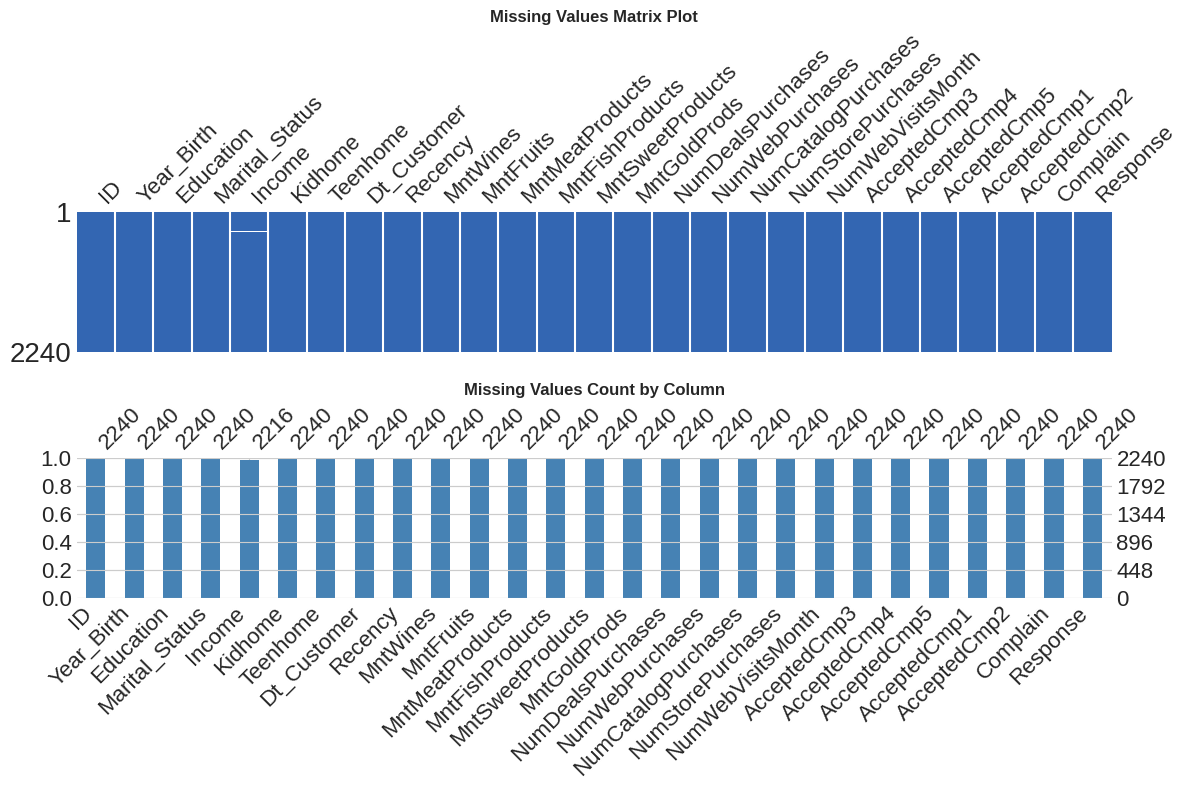

In [11]:
# Visualize with missno
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Matrix plot (top)
msno.matrix(df, ax=axes[0], sparkline=False, color=(0.2, 0.4, 0.7))
axes[0].set_title('Missing Values Matrix Plot', fontsize=12, fontweight='bold')

# Bar chart (bottom)
msno.bar(df, ax=axes[1], color='steelblue')
axes[1].set_title('Missing Values Count by Column', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


Using the missingno bar plot, we checked how complete each column is and saw that Income only has 2,216 non‑missing values out of 2,240 rows—so 24 entries are missing in that column.

### 1.3 Handle Missing Values (Median Imputation)

Since the missing values in Income only 1.07%, we decided to fill them with the median instead of dropping the rows. Median is better than mean here because if Income data has outliers, it won't get skewed by extreme values.

In [12]:
#FILL THE MISSING VALUES WITH THE MEDIAN VALUES.
df_old = df.copy()
df_clean = df.copy()
df_clean['Income']=df['Income'].fillna(df['Income'].median())

In [13]:
missing_data(df_clean).style.background_gradient(cmap='Reds')

,Total,Percentage


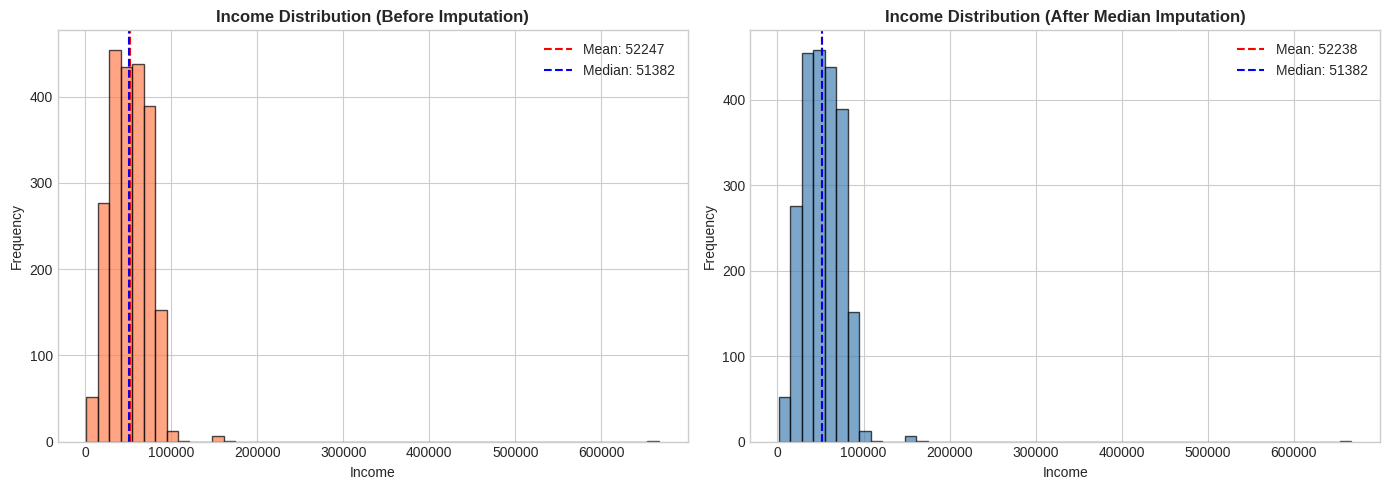

In [14]:
# VISUALIZE INCOME DISTRIBUTION AFTER IMPUTATION

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before imputation (with missing values dropped for visualization)
axes[0].hist(df_old['Income'].dropna(), bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0].axvline(df_old['Income'].mean(), color='red', linestyle='--', label=f"Mean: {df_old['Income'].mean():.0f}")
axes[0].axvline(df_old['Income'].median(), color='blue', linestyle='--', label=f"Median: {df_old['Income'].median():.0f}")
axes[0].set_title('Income Distribution (Before Imputation)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# After imputation
axes[1].hist(df_clean['Income'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(df_clean['Income'].mean(), color='red', linestyle='--', label=f"Mean: {df_clean['Income'].mean():.0f}")
axes[1].axvline(df_clean['Income'].median(), color='blue', linestyle='--', label=f"Median: {df_clean['Income'].median():.0f}")
axes[1].set_title('Income Distribution (After Median Imputation)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Income')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('income_imputation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


The Income distribution looks essentially the same before and after median imputation: the mean changes only slightly (52,247 → 52,238) while the median stays at 51,382. The shape remains right‑skewed, so filling the small amount of missing Income values did not affect the distribution of data.

### 1.4 Outlier Detection and Handling


Before handling outliers, we need to detect them using the IQR (Interquartile Range) method. Basically, it calculates Q1 (25th percentile) and Q3 (75th percentile), finds the IQR as the difference between them, then flags anything below Q1 - 1.5×IQR or above Q3 + 1.5×IQR as an outlier. The function also pulls descriptive stats like mean, median, mode, standard deviation, and min/max values for each numerical column to get a full picture of the data distribution. We compile all this data into a sorted dataframe so we can easily compare the outliers

In [15]:
def detect_outliers_iqr(df, column):
    # Calculate the first quartile (25th percentile)
    Q1 = df[column].quantile(0.25)
    # Calculate the third quartile (75th percentile)
    Q3 = df[column].quantile(0.75)
    # Calculate the Interquartile Range (IQR)
    IQR = Q3 - Q1
    # Calculate the lower bound for outlier detection
    lower_bound = Q1 - 1.5 * IQR
    # Calculate the upper bound for outlier detection
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers based on the calculated bounds
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
    # Count the number of outliers
    n_outliers = outliers.shape[0]
    # Calculate the percentage of outliers
    pct_outliers = (n_outliers / df.shape[0]) * 100

    # Calculate descriptive statistics for the column
    n = df[column].count()
    mean_val = df[column].mean()
    median_val = df[column].median()
    mode_val = df[column].mode()[0] if not df[column].mode().empty else None
    std_val = df[column].std()
    var_val = df[column].var()
    min_val = df[column].min()
    max_val = df[column].max()

    # Return all calculated statistics and outlier information
    return (lower_bound, upper_bound, n_outliers, pct_outliers,
            n, mean_val, median_val, mode_val, std_val, var_val, min_val, max_val)

def analyze_outliers(df):
    """Analyze outliers for all numerical columns"""
    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    outlier_data = []
    for col in numerical_cols:
        (lower, upper, n_outliers, pct_outliers,
         n, mean_val, median_val, mode_val,
         std_val, var_val, min_val, max_val) = detect_outliers_iqr(df, col)

        outlier_data.append({
            'Column': col,
            'N': n,
            'Mean': round(mean_val, 2),
            'Median': median_val,
            'Mode': mode_val,
            'SD': round(std_val, 2),
            'Var': round(var_val, 2),
            'Min': min_val,
            'Max': max_val,
            'Lower Bound': round(lower, 2),
            'Upper Bound': round(upper, 2),
            'Outliers': n_outliers,
            'Percentage (%)': round(pct_outliers, 2)
        })

    outlier_df = pd.DataFrame(outlier_data).sort_values('Percentage (%)', ascending=False)

    return outlier_df

In [16]:
outlier_df = analyze_outliers(df_clean)
outlier_df

,Column,N,Mean,Median,Mode,SD,Var,Min,Max,Lower Bound,Upper Bound,Outliers,Percentage (%)
23,Response,2240,0.15,0.0,0.0,0.36,1.300000e-01,0.0,1.0,0.00,0.00,334,14.91
10,MntSweetProducts,2240,27.06,8.0,0.0,41.28,1.704080e+03,0.0,263.0,-47.00,81.00,248,11.07
7,MntFruits,2240,26.30,8.0,0.0,39.77,1.581930e+03,0.0,199.0,-47.00,81.00,227,10.13
9,MntFishProducts,2240,37.53,12.0,0.0,54.63,2.984330e+03,0.0,259.0,-67.50,120.50,223,9.96
11,MntGoldProds,2240,44.02,24.0,1.0,52.17,2.721440e+03,0.0,362.0,-61.50,126.50,207,9.24
8,MntMeatProducts,2240,166.95,67.0,7.0,225.72,5.094743e+04,0.0,1725.0,-308.00,556.00,175,7.81
18,AcceptedCmp4,2240,0.07,0.0,0.0,0.26,7.000000e-02,0.0,1.0,0.00,0.00,167,7.46
17,AcceptedCmp3,2240,0.07,0.0,0.0,0.26,7.000000e-02,0.0,1.0,0.00,0.00,163,7.28
19,AcceptedCmp5,2240,0.07,0.0,0.0,0.26,7.000000e-02,0.0,1.0,0.00,0.00,163,7.28
20,AcceptedCmp1,2240,0.06,0.0,0.0,0.25,6.000000e-02,0.0,1.0,0.00,0.00,144,6.43


In [16]:
def visualize_outliers_boxplots(df, cols_per_row=5, figsize_per_row=4):
    """
    Visualizes boxplots for outlier detection across all numerical columns in a DataFrame.

    Parameters:
    ----------
    df : pandas.DataFrame
        Input DataFrame containing data for visualization.
    cols_per_row : int, optional (default=5)
        Number of subplot columns in each row.
    figsize_per_row : int or float, optional (default=4)
        Height of each subplot row, used to set the figure size.

    Usage:
    -----
    visualize_outliers_boxplots(df_clean)
    """

    # Select numerical columns (int64 and float64)
    numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    n_cols = len(numerical_cols)
    n_rows = (n_cols + cols_per_row - 1) // cols_per_row  # Ceiling division for number of rows

    plt.figure(figsize=(20, figsize_per_row * n_rows))

    for i, col in enumerate(numerical_cols):
        plt.subplot(n_rows, cols_per_row, i + 1)
        sns.boxplot(y=df[col], orient='v')
        plt.title(col, fontweight='bold')

    plt.tight_layout()
    plt.suptitle('Outlier Detection - Boxplots', fontsize=14, fontweight='bold', y=1.02)
    plt.show()

KeyboardInterrupt: 

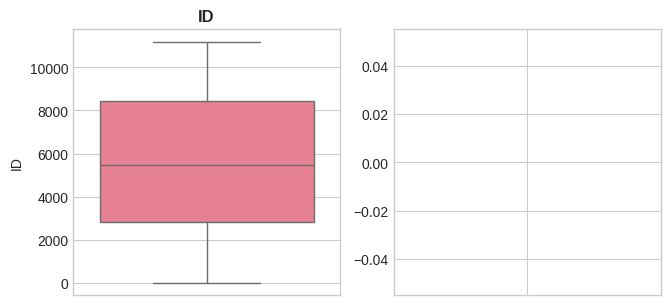

In [18]:
visualize_outliers_boxplots(df_clean)

Key Findings:

1. High Outlier Rates in Spending Variables: The spending columns (MntWines, MntMeatProducts, MntFruits, etc.) exhibit outlier rates between 7-11%, indicating that some customers spend significantly more than typical patterns. These are not data errors but represent genuine variation in customer buying behavior.

2. Purchase Channel Outliers: NumDealsPurchases (3.84% outliers) and NumCatalogPurchases show similar patterns where a small subset of customers make substantially more purchases through these channels compared to the average.

3. Data Quality Issues Identified:
* Year_Birth < 1920: Some records show birth years before 1920, implying customers over 106 years old, which is clearly implausible and indicates data entry errors.

* Income = 666666: This suspiciously round number appears to be a placeholder value or input error, falling far outside normal income ranges and well beyond the IQR upper bound of $117,416. Given that the marketing campaign targets middle-income customers, such extremely high income values are unrealistic for this dataset.

4. Variables Excluded from Treatment: Binary variables (Response, AcceptedCmp1-5, Complain) contain only 0 or 1 values, making outlier detection inapplicable. Additionally, variables with outlier rates at or below 0.5% are already well-distributed and require no adjustment.

5. We'll test two approaches for handling outliers. First, winsorization caps extreme values at set percentiles, keeping all data points intact. Second, we'll remove only clearly invalid entries—specifically, birth years before 1920 and incomes exceeding 200,000—which are logically impossible. We'll use distributional tests to see which method preserves the original data structure better.

We're taking a cautious approach to deletion because most outliers here probably represent real phenomena, not mistakes. As Frost (2021) explains, outliers often carry important information about natural variability, and cutting them out just for being extreme can actually skew your results. So we're only dropping entries that break basic logical rules.

### 1.4.1 Outlier Handling



### 1.4.1.1 Outlier Handling with winsorization

As the first method, we applied Winsorization as the outlier treatment because it caps extreme values at specified percentiles, preserves all observations, and reduces outlier impact without data loss.

In [17]:
# WINSORIZATION - Cap outliers at 1st and 95th percentile
df_winsor = df_clean.copy()

def winsorize_column(df, column, lower_percentile=0.01, upper_percentile=0.95):
    """
    Apply Winsorization to cap outliers at specified percentiles
    """
    lower_bound = df[column].quantile(lower_percentile)
    upper_bound = df[column].quantile(upper_percentile)
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

print("APPLYING WINSORIZATION (1st - 95th Percentile)")
print("="*60)

# Columns to winsorize (those with significant outliers)
cols_to_winsorize = ['Year_Birth', 'Income','MntWines', 'MntFruits', 'MntMeatProducts',
                'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
                'NumCatalogPurchases']

for col in cols_to_winsorize:
    original_min = df_winsor[col].min()
    original_max = df_winsor[col].max()
    df_winsor = winsorize_column(df_winsor, col)
    new_min = df_winsor[col].min()
    new_max = df_winsor[col].max()
    print(f"{col}: [{original_min:.0f}, {original_max:.0f}] → [{new_min:.0f}, {new_max:.0f}]")

print("\n Winsorization completed!")



APPLYING WINSORIZATION (1st - 95th Percentile)
Year_Birth: [1893, 1996] → [1945, 1988]
Income: [1730, 666666] → [7706, 83927]
MntWines: [0, 1493] → [1, 1000]
MntFruits: [0, 199] → [0, 123]
MntMeatProducts: [0, 1725] → [2, 687]
MntFishProducts: [0, 259] → [0, 168]
MntSweetProducts: [0, 263] → [0, 126]
MntGoldProds: [0, 362] → [0, 165]
NumDealsPurchases: [0, 15] → [0, 6]
NumCatalogPurchases: [0, 28] → [0, 9]

 Winsorization completed!


Winsorization at the 1st-95th percentile was initially applied to address extreme outliers across spending and income variables. However, these extreme values likely represent natural variation—genuine high-value customers rather than measurement errors. Since capping these values would distort true customer segments critical for clustering, alternative approaches were explored to preserve authentic behavioral patterns while maintaining model stability.

### 1.4.1.2 Outlier Handling with removal outlier

As the second method, we applied outlier removal for observations with extreme values. We removed rows with income above 200,000 and birth years before 1920. The remaining outliers are considered natural variance and left unchanged to preserve data uniqueness, following guidelines by Frost (2021) that emphasize distinguishing between measurement errors and legitimate variability in the population.

In [18]:
df_clean_impute = df_clean.copy()

In [19]:
# DROP Year_Birth < 1920 and Income > 200000

initial_rows = df_clean.shape[0]
print(f"Data shape BEFORE cleaning: {initial_rows} rows")

# Remove rows dengan KEDUA criteria invalid
df_clean = df_clean[(df_clean['Year_Birth'] >= 1920) & (df_clean['Income'] <= 200000)]

final_rows = df_clean.shape[0]
num_removed = initial_rows - final_rows

print(f"Removed {num_removed} row(s) with invalid criteria.")
print(f"Data shape AFTER cleaning: {final_rows} rows")

Data shape BEFORE cleaning: 2240 rows
Removed 4 row(s) with invalid criteria.
Data shape AFTER cleaning: 2236 rows


We ran a Kolmogorov-Smirnov test to see which outlier handling method—removal or winsorization—keeps our data distribution closest to the original. The KS test compares two datasets by measuring how different their cumulative distributions are, giving us a p-value that tells us if they're statistically similar. By comparing the original data against both outlier treatments, we can pick the method that deals with extreme values without distorting the data structures.

In [20]:
cols_to_test = ['Income', 'Year_Birth', 'MntWines', 'MntMeatProducts',
                     'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
                     'NumWebVisitsMonth']

all_results = []

for var in cols_to_test:
    ks1, p1 = ks_2samp(df_clean_impute[var], df_clean[var])
    ks2, p2 = ks_2samp(df_clean_impute[var], df_winsor[var])
    ks3, p3 = ks_2samp(df_clean[var], df_winsor[var])

    all_results.append({
        'Variable': var,
        'Before vs Removal (KS)': ks1,
        'Before vs Removal (p)': p1,
        'Before vs Winsor (KS)': ks2,
        'Before vs Winsor (p)': p2,
        'Removal vs Winsor (KS)': ks3,
        'Removal vs Winsor (p)': p3
    })

results_df = pd.DataFrame(all_results)

print("\nKS-TEST RESULTS FOR ALL VARIABLES:")

print(results_df.to_string(index=False))



KS-TEST RESULTS FOR ALL VARIABLES:
         Variable  Before vs Removal (KS)  Before vs Removal (p)  Before vs Winsor (KS)  Before vs Winsor (p)  Removal vs Winsor (KS)  Removal vs Winsor (p)
           Income                0.000795                    1.0               0.050000              0.007388                0.049642               0.007660
       Year_Birth                0.001339                    1.0               0.040625              0.049592                0.040698               0.047171
         MntWines                0.000987                    1.0               0.049554              0.008162                0.049642               0.007660
  MntMeatProducts                0.000831                    1.0               0.050000              0.007388                0.050089               0.006929
  MntFishProducts                0.000696                    1.0               0.050000              0.007388                0.050089               0.006929
 MntSweetProducts     

The removal method is superior due to minimal KS statistics (0.0006-0.0013, p=1.0), indicating that the distribution remains intact despite eliminating a few invalid rows. The two-sample Kolmogorov-Smirnov test is particularly suitable for this comparison as it is sensitive to differences in both location and shape of distributions (Frost, 2025). Winsorization, conversely, alters the distribution (KS=0.04-0.05, p<0.05) by capping values that represent legitimate observations. Therefore, removal was selected because it preserves data integrity with minimal data loss.

### 1.5 Feature Engineering

Basic Transformations

Before encoding, we create some derived features that will be useful for analysis.

This step performs feature engineering by creating new, more informative variables from raw columns to make EDA and modeling easier.

* Age: converts birth year into age.

* TotalSpending: adds up spending across all product types to get one “how much they spend” number.

* TotalPurchases: adds up purchases across channels to get one “how often they buy” number.

* TotalChildren: combines kids + teens into total children at home.

* TotalAcceptedCmp: counts how many past campaigns they accepted (leaves out Response so you don’t leak the target).

* CustomerTenure: how long they’ve been a customer, measured in days since signup (using the latest signup date in the data as the reference point).

* IsParent: simple flag for whether they have any children.



In [21]:
# CREATE DERIVED FEATURES

print("CREATING DERIVED FEATURES")
print("="*60)

# 1. Age from Year_Birth (assuming current year is 2025)
current_year = 2025
df_clean['Age'] = current_year - df_clean['Year_Birth']

# 2. Total Amount Spent on all products
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
                 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df_clean['TotalSpending'] = df_clean[spending_cols].sum(axis=1)


# 3. Total Number of Purchases across all channels
purchase_cols = ['NumDealsPurchases', 'NumWebPurchases',
                 'NumCatalogPurchases', 'NumStorePurchases']
df_clean['TotalPurchases'] = df_clean[purchase_cols].sum(axis=1)


# 4. Total number of children
df_clean['TotalChildren'] = df_clean['Kidhome'] + df_clean['Teenhome']

# 5. Total Accepted Campaigns (excluding current Response)
campaign_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
df_clean['TotalAcceptedCmp'] = df_clean[campaign_cols].sum(axis=1)

# 6. Customer Tenure (days since enrollment)
df_clean['Dt_Customer'] = pd.to_datetime(df_clean['Dt_Customer'], format='%d-%m-%Y')
reference_date = df_clean['Dt_Customer'].max()  # Use latest date as reference
df_clean['CustomerTenure'] = (reference_date - df_clean['Dt_Customer']).dt.days

# 7. Is Parent (has any children)
df_clean['IsParent'] = (df_clean['TotalChildren'] > 0).astype(int)


# 8. Ratio
#Conversion efficiency
df_clean['CVR'] = df_clean['TotalPurchases'] / df_clean['NumWebVisitsMonth'].replace(0, 1)
df_clean['CVR'] = df_clean['CVR'].round(2)

#  Purchase frequency relatif income

#  Channel preference - Catalog
df_clean['CatalogPurchaseRatio'] = df_clean['NumCatalogPurchases'] / (df_clean['TotalPurchases'] + 1)

#  Promo sensitivity
df_clean['DealsPurchaseRatio'] = df_clean['NumDealsPurchases'] / (df_clean['TotalPurchases'] + 1)

print(f"\n Current shape after feature creation: {df_clean.shape}")




CREATING DERIVED FEATURES

 Current shape after feature creation: (2236, 37)


In [22]:
# Drop original column

col_del = [
    "ID","Dt_Customer", "Year_Birth",
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5",
     'NumWebVisitsMonth',"NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumDealsPurchases",
    "Kidhome", "Teenhome",
    "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"
]

df_clean = df_clean.drop(columns=col_del)

print(f"\n Current shape after feature creation: {df_clean.shape}")


 Current shape after feature creation: (2236, 16)


table of feature engineering

| New Feature | Description | Source Features |
|-------------|-------------|-----------------|
| Age | Customer age calculated from Year_Birth (2025 - Year_Birth). More intuitive than birth year for modeling purposes. | Year_Birth |
| TotalSpending | Total amount spent across all product categories (wines, fruits, meat, fish, sweets, gold). Captures overall purchasing power. | MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts, MntGoldProds |
| TotalPurchases | Total number of purchases across all channels (deals, web, catalog, store). Indicates customer activity level. | NumDealsPurchases, NumWebPurchases, NumCatalogPurchases, NumStorePurchases |
| TotalChildren | Combined number of kids and teenagers at home. Simplifies family structure representation. | Kidhome, Teenhome |
| TotalAcceptedCmp | Number of previous campaigns accepted (Cmp1-5). Indicates customer receptiveness to marketing efforts. | AcceptedCmp1, AcceptedCmp2, AcceptedCmp3, AcceptedCmp4, AcceptedCmp5 |
| CustomerTenure | Number of days since enrollment. Distinguishes long-term customers from recent sign-ups. | Dt_Customer |
| IsParent | Binary indicator (0/1) showing whether customer has children. Simplifies parental status analysis. | TotalChildren |


**FEATURE ENGINEERING: DERIVED METRICS SUMMARY**

After data exploration, we engineered Five metrics to enhance model performance and business insights :

* CVR measures web-to-purchase conversion efficiency, identifying decisive buyers versus browsers needing nurturing.

* CatalogPurchaseRatio reveals channel preference, optimizing marketing spend between catalog, digital, and retail.

* DealsPurchaseRatio quantifies promotional sensitivity, separating price-driven customers from quality-focused buyers.


Some original features will also be removed later to avoid redundancy and multicollinearity.

| Category | Columns | Reason for Removal | Derived Feature |
|----------|---------|-------------------|-----------------|
| **Identifier** | ID | Not necessary for modeling | - |
| **Date Features** | Dt_Customer, Year_Birth | Already derived into new features | Age, CustomerTenure |
| **Campaign Response** | AcceptedCmp1, AcceptedCmp2, AcceptedCmp3, AcceptedCmp4, AcceptedCmp5 | Already aggregated | TotalAcceptedCmp |
| **Purchase Channels** | NumWebVisitsMonth, NumWebPurchases, NumCatalogPurchases, NumStorePurchases, NumDealsPurchases | Already aggregated | TotalPurchases, CVR|
| **Children** | Kidhome, Teenhome | Already aggregated | TotalChildren, IsParent |
| **Product Categories** | MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts, MntGoldProds | Already aggregated | TotalSpending, SpendingPerPurchase |


### 1.6 Categorical Variable Encoding



Chi-Square Test & Cramér's V Analysis:

We performed this test early because categorical data becomes lost after one-hot encoding, making the test impossible to run later.

Education (χ²=23.01, V=0.101):
Weakest effect—there's a difference in response across education levels but it's small.

Marital_Status (χ²=54.35, V=0.156):
Stronger than Education. Clear difference in campaign response between single and married customers.

IsParent (χ²=92.95, V=0.204):
Strongest of the three variables. Having children or not is the biggest differentiator. Parents likely respond less because they're busy and have tighter budgets.

In [23]:
from scipy.stats import chi2_contingency
import numpy as np

def chi_test(df, col, target='Response'):
    ct = pd.crosstab(df[col], df[target])
    chi2, p_val, _, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

    print(f"{col}: χ²={chi2:.2f}, p={p_val:.4f}, Cramér's V={cramers_v:.3f} {'v' if p_val < 0.05 else 'x'}")

print("Chi-Square Tests:")
print("-"*60)
for col in ['Education', 'Marital_Status', 'IsParent']:
    chi_test(df_clean, col)

Chi-Square Tests:
------------------------------------------------------------
Education: χ²=23.01, p=0.0001, Cramér's V=0.101 v
Marital_Status: χ²=54.35, p=0.0000, Cramér's V=0.156 v
IsParent: χ²=92.95, p=0.0000, Cramér's V=0.204 v


Most respondents have a Graduation degree (1,126, about 50%), followed by PhD (485) and Master (370). For marital status, Married dominates (864, roughly 39%) with Together second (578). A few categories like Basic, Alone, Absurd, and YOLO have very few cases and might need to be grouped or dropped in the next preprocessing step.

In [24]:
# EXPLORE CATEGORICAL VARIABLES

print("CATEGORICAL VARIABLES EXPLORATION")

print("\n Education Levels:")
print(df_clean['Education'].value_counts())

print("\n Marital Status:")
print(df_clean['Marital_Status'].value_counts())

CATEGORICAL VARIABLES EXPLORATION

 Education Levels:
Education
Graduation    1126
PhD            485
Master         370
2n Cycle       201
Basic           54
Name: count, dtype: int64

 Marital Status:
Marital_Status
Married     864
Together    578
Single      479
Divorced    231
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


We remap categories to simplify the data before encoding. Education gets standardized into five clear levels (High School, Diploma, Bachelor, Master, PhD). Marital Status gets collapsed into two groups: Single (covers Single, Divorced, Widow, Alone, Absurd, YOLO) and Partner (covers Married and Together). This reduces sparse categories and makes the data cleaner for modeling.

Then We apply different encoding strategies based on variable characteristics:
- **Education:** One-hot encoding (no natural order)
- **Marital_Status:** One-hot encoding (no natural order)

In [25]:
# Step 1: Map Education to clear categories
education_mapping = {
    'Basic': 'High School',
    '2n Cycle': 'Diploma',
    'Graduation': 'Bachelor',
    'Master': 'Master',
    'PhD': 'PhD'
}

# Step 2: Map Marital Status
marital_mapping = {
    'Single': 'Single',
    'Together': 'Partner',
    'Married': 'Partner',
    'Divorced': 'Single',
    'Widow': 'Single',
    'Alone': 'Single',
    'Absurd': 'Single',
    'YOLO': 'Single'
}

# Apply mappings
df_clean['Education'] = df_clean['Education'].map(education_mapping)
df_clean['Marital_Status'] = df_clean['Marital_Status'].map(marital_mapping)

print(f"\n Mapped values:")
print(f"   Education: {df_clean['Education'].unique()}")
print(f"   Marital Status: {df_clean['Marital_Status'].unique()}")

# Step 3: One-Hot Encoding
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
cat_cols = ['Education', 'Marital_Status']

# Fit and transform
encoded_array = encoder.fit_transform(df_clean[cat_cols])
encoded_feature_names = encoder.get_feature_names_out(cat_cols)

print(f"\n Encoded feature names:")
for name in encoded_feature_names:
    print(f"   - {name}")

df_clean = pd.concat([
    df_clean.drop(columns=['Education', 'Marital_Status']),
    pd.DataFrame(encoded_array, columns=encoded_feature_names, index=df_clean.index)
], axis=1)


print(f"\n Final shape after encoding: {df_clean.shape}")
print(f"\n Final columns:")
print(df_clean.columns.tolist())


 Mapped values:
   Education: ['Bachelor' 'PhD' 'Master' 'High School' 'Diploma']
   Marital Status: ['Single' 'Partner']

 Encoded feature names:
   - Education_Diploma
   - Education_High School
   - Education_Master
   - Education_PhD
   - Marital_Status_Single

 Final shape after encoding: (2236, 19)

 Final columns:
['Income', 'Recency', 'Complain', 'Response', 'Age', 'TotalSpending', 'TotalPurchases', 'TotalChildren', 'TotalAcceptedCmp', 'CustomerTenure', 'IsParent', 'CVR', 'CatalogPurchaseRatio', 'DealsPurchaseRatio', 'Education_Diploma', 'Education_High School', 'Education_Master', 'Education_PhD', 'Marital_Status_Single']


Post-encoding yields a dataset of 2,236 rows and 19 columns. The numeric behavior features remain unchanged, Response serves as the target variable, and categorical fields (Education, Marital Status) are converted into dummy variables. This lets the model work with categories as numbers without losing track of what each one represents.

### 1.7 Verify Data Preparation is Complete

We run a final check on the prepared dataset to confirm the dimensions, check for any remaining missing values, review the data types, and look at how the target variable Response is distributed. The response rate tells us what percentage of customers actually responded to the campaign.

In [26]:
# FINAL VERIFICATION

print("DATA PREPARATION - FINAL VERIFICATION")
print("="*60)

print(f"\n Dataset Shape: {df_clean.shape}")
print(f"\n Missing Values: {df_clean.isnull().sum().sum()}")
print(f"\n Data Types:")
print(df_clean.dtypes.value_counts())

# Verify target variable
print(f"\n Target Variable Distribution:")
print(df_clean['Response'].value_counts())
print(f"\n   Response Rate: {df_clean['Response'].mean()*100:.2f}%")


DATA PREPARATION - FINAL VERIFICATION

 Dataset Shape: (2236, 19)

 Missing Values: 0

 Data Types:
int64      10
float64     9
Name: count, dtype: int64

 Target Variable Distribution:
Response
0    1902
1     334
Name: count, dtype: int64

   Response Rate: 14.94%


Final verification shows the dataset is ready with 2,236 observations and 19 variables, no missing values, composed of 10 integer and 9 float columns. The target variable Response exhibits class imbalance with 334 positive cases (14.94%) versus 1,902 negative cases (85.06%), which requires special consideration in the modeling strategy.

## Distribution Validation

Then we create distribution visualizations for all numeric variables using histograms and KDE curves, calculate the skewness of each variable, and provide transformation recommendations (whether log/sqrt is needed). The output shows a grid of plots and a recommendation table to help decide which features need transformation.

In [27]:
def visualize_distribution_and_skewness(df, skew_thresh1=0.5, skew_thresh2=1.0, severe_skew=2.0,
                                        cols_per_row=4, figsize_width=18, figsize_height_per_row=3.5):
    """
    Visualize distributions (histogram + KDE) and print skewness + transformation recommendations
    for all numerical columns in a DataFrame with nice layout and sized figures.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe with data.

    skew_thresh1 : float (default=0.5)
        Threshold for "no transformation needed" skewness absolute value.

    skew_thresh2 : float (default=1.0)
        Threshold for "consider log/sqrt transformation".

    severe_skew : float (default=2.0)
        Threshold for "apply log transformation (severe skew)".

    cols_per_row : int (default=4)
        Number of plots per row.

    figsize_width : float (default=18)
        Width of the entire figure.

    figsize_height_per_row : float (default=3.5)
        Height allocated per row.
    """

    numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    n_cols = len(numerical_cols)
    n_rows = (n_cols + cols_per_row - 1) // cols_per_row  # round up

    figsize = (figsize_width, figsize_height_per_row * n_rows)
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=figsize)
    axes = axes.flatten() if n_cols > 1 else [axes]

    print("TRANSFORMATION RECOMMENDATIONS BASED ON SKEWNESS")
    print("="*60)
    print(f"\n{'Feature':25s} | {'Skew':>7s} | Recommendation")
    print("-" * 65)

    for i, feature in enumerate(numerical_cols):
        ax = axes[i]

        # Plot histogram with density
        ax.hist(df[feature], bins=30, color='steelblue', alpha=0.7,
                edgecolor='black', density=True)

        # Plot KDE
        df[feature].plot(kind='kde', ax=ax, color='red', linewidth=2, legend=False)

        # Calculate skewness and set label
        skew_val = df[feature].skew()
        if skew_val > skew_thresh1:
            skew_label = "Right-skewed"
        elif skew_val < -skew_thresh1:
            skew_label = "Left-skewed"
        else:
            skew_label = "Symmetric"

        # Set titles and labels with style similar to example
        ax.set_title(f"{feature}\nSkewness: {skew_val:.2f} ({skew_label})",
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Density')
        ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='both', labelsize=9)

        # Print transformation recommendation
        abs_skew = abs(skew_val)
        if abs_skew < skew_thresh1:
            recommendation = "No transformation needed"
        elif abs_skew < skew_thresh2:
            recommendation = "Consider log/sqrt transformation"
        else:
            if abs_skew >= severe_skew:
                recommendation = "Apply log transformation (severe)"
            else:
                recommendation = "Apply log/sqrt transformation"

        print(f"{feature:25s} | {skew_val:+7.2f} | {recommendation}")

    # Hide unused subplots if any
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.suptitle('Variable Distributions with Skewness Analysis',
                 fontsize=14, fontweight='bold')
    plt.show()

TRANSFORMATION RECOMMENDATIONS BASED ON SKEWNESS

Feature                   |    Skew | Recommendation
-----------------------------------------------------------------
Income                    |   +0.35 | No transformation needed
Recency                   |   -0.00 | No transformation needed
Complain                  |  +10.44 | Apply log transformation (severe)
Response                  |   +1.97 | Apply log/sqrt transformation
Age                       |   +0.09 | No transformation needed
TotalSpending             |   +0.86 | Consider log/sqrt transformation
TotalPurchases            |   +0.25 | No transformation needed
TotalChildren             |   +0.42 | No transformation needed
TotalAcceptedCmp          |   +2.72 | Apply log transformation (severe)
CustomerTenure            |   -0.02 | No transformation needed
IsParent                  |   -0.95 | Consider log/sqrt transformation
CVR                       |   +2.46 | Apply log transformation (severe)
CatalogPurchaseRatio      |

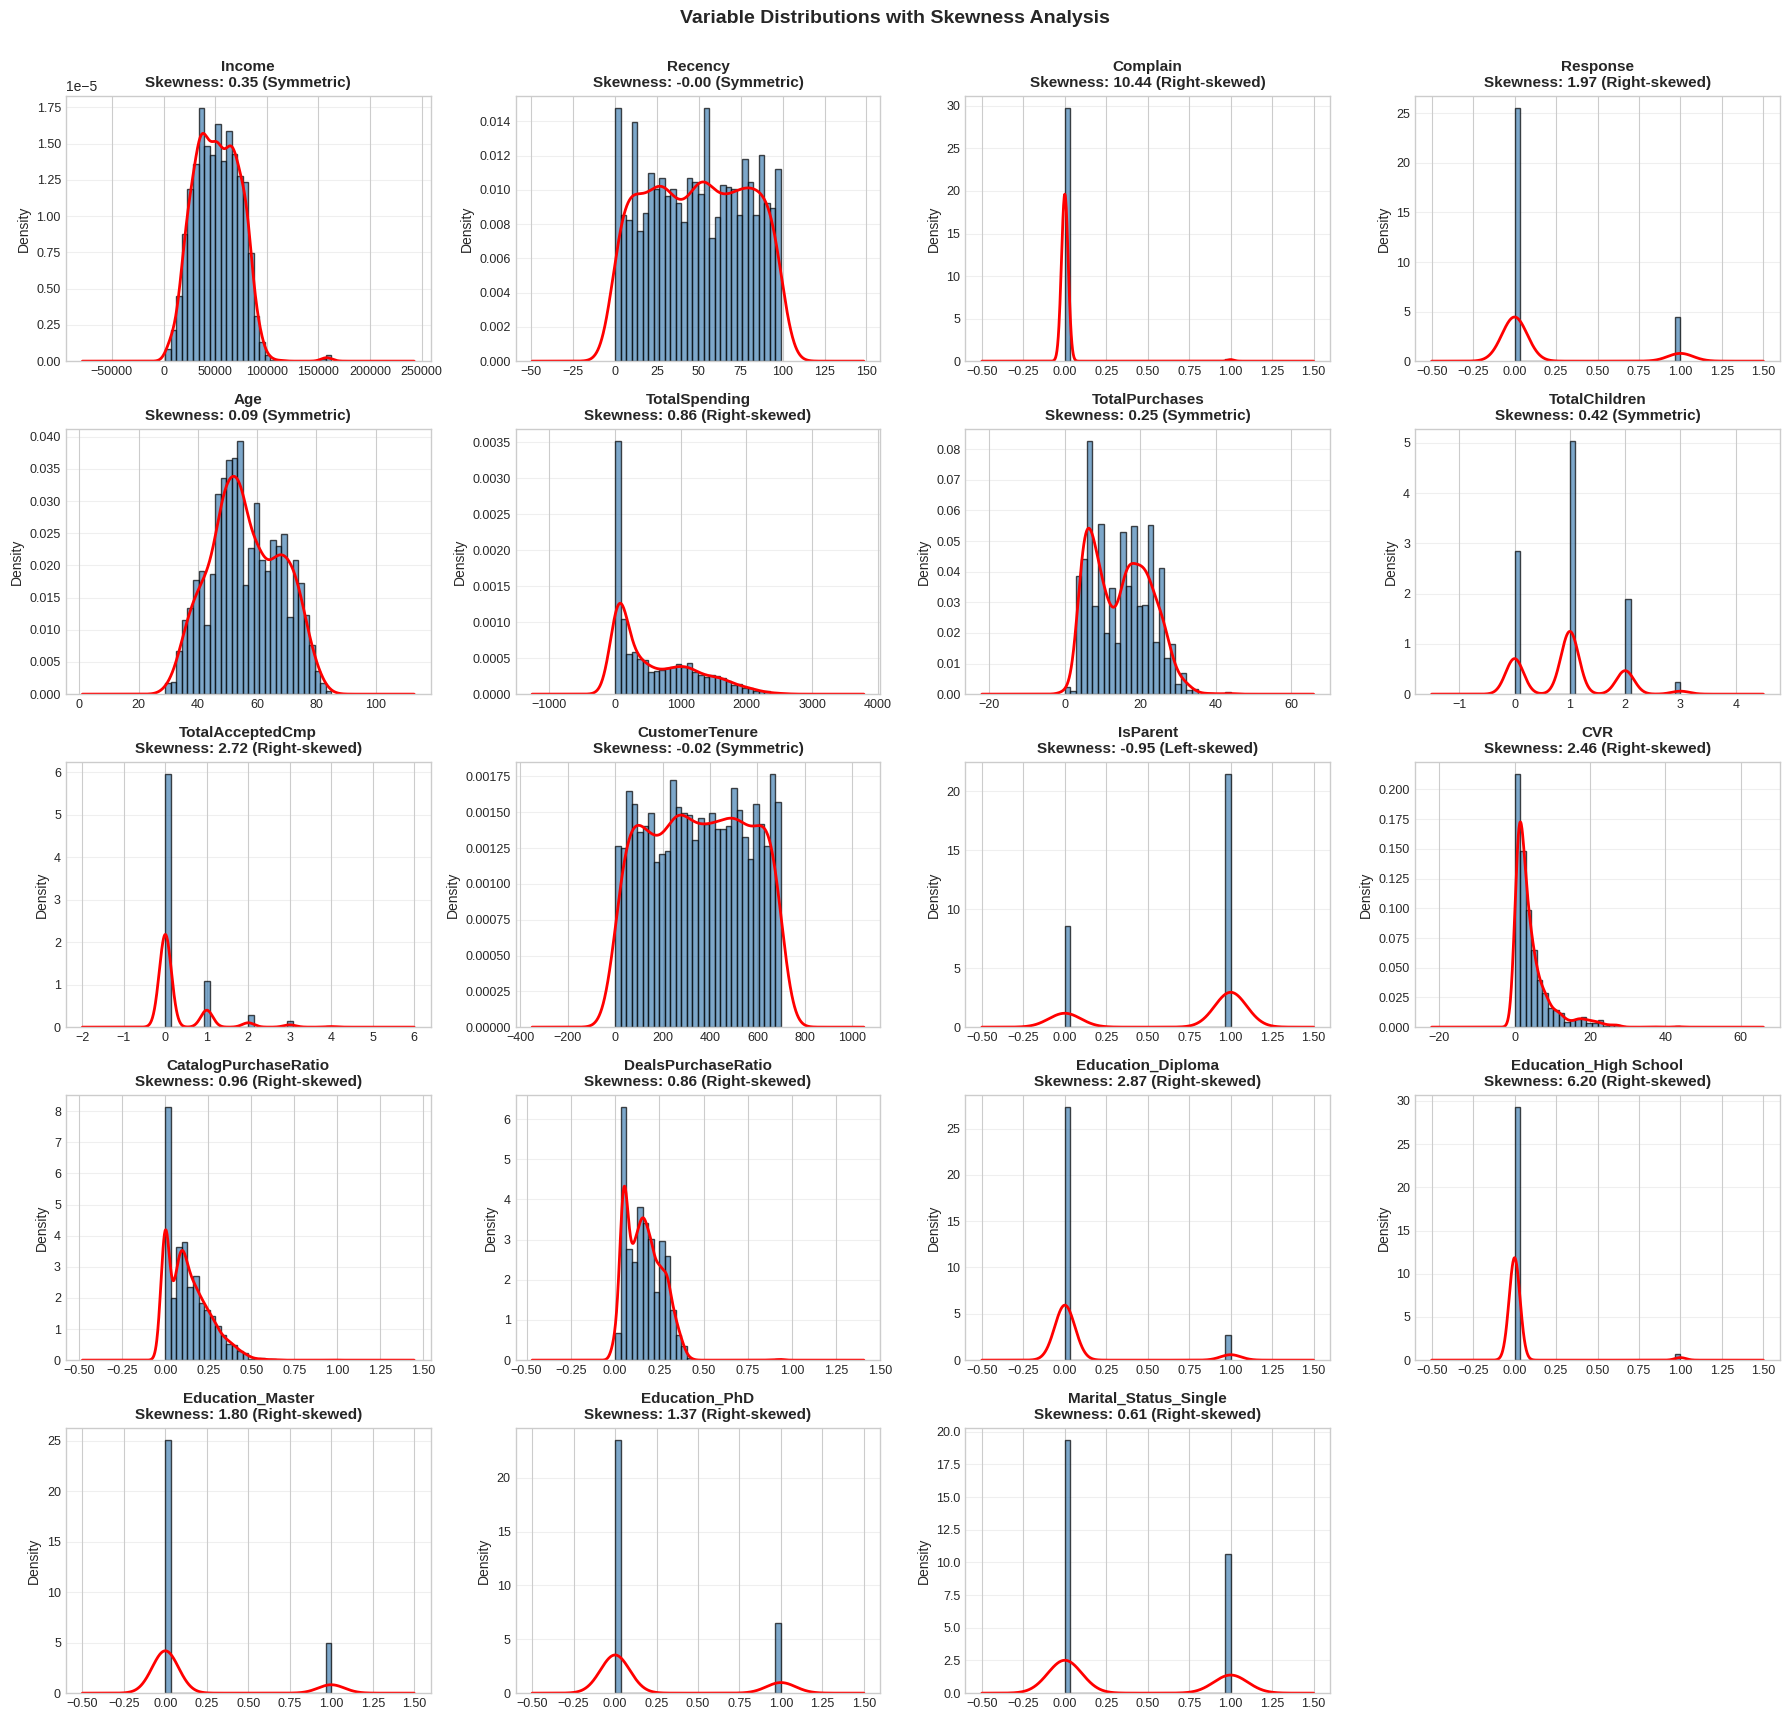

In [28]:
visualize_distribution_and_skewness(df_clean)

**Key Insight :**

After prior outlier treatment, most detected "outliers" are not data errors but natural variation or class imbalance. Transformation decisions depend on this distinction

1. Continuous Features - NO Transformation Needed
  Outliers were already handled before. Remaining are natural extreme values (high spenders, frequent buyers), not errors. Transformation would only harm interpretability without significant benefit

    | Feature        | Type              | Outliers (%) | Skewness | Decision     | Reason                             |
    | -------------- | ----------------- | ------------ | -------- | ------------ | ---------------------------------- |
    | Income         | Continuous        | 0.31%        | +0.35    | NO transform | Low skewness, natural high earners |
    | Recency        | Continuous (days) | 0%           | -0.00    | NO transform | Perfect balance                    |
    | Age            | Continuous        | 0%           | +0.09    | NO transform | Minimal skew                       |
    | TotalPurchases | Count             | 0.09%        | +0.25    | NO transform | Low skewness                       |
    | TotalChildren  | Count (0-3)       | 2.37%        | +0.42    | NO transform | Acceptable skew, few values        |
    | CustomerTenure | Continuous (days) | 0%           | -0.02    | NO transform | Perfectly balanced                 |
    


2. Binary/One-Hot Features - NO Transformation
  High "outliers" in binary features aren't problems. They're just minority classes. Transforming binary data makes no sense. ML models (tree-based, logistic regression) already handle this well via class weights or stratified sampling.
  | Feature | Type | Outliers (%) | Skewness | Decision | Reason |
|---------|------|--------------|----------|----------|--------|
| Complain | Binary | 0.89% | +10.44 | NO transform | Class imbalance, not data error |
| Response | Binary | 14.94% | +1.97 | NO transform | Target variable, imbalanced is expected |
| IsParent | Binary | 0% | -0.95 | NO transform | Balanced binary |
| Education_PhD | One-hot | 21.69% | +2.87 | NO transform | Class imbalance (22% have PhD) |
| Education_Master | One-hot | 16.55% | +1.80 | NO transform | Class imbalance (17% have Master) |
| Education_Diploma | One-hot | 8.99% | - | NO transform | Class imbalance (9% have Diploma) |
| Education_HighSchool | One-hot | 2.42% | +6.20 | NO transform | Class imbalance (2% have HS only) |
| Marital_Status_Single | One-hot | 0% | +0.61 | NO transform | Relatively balanced |

3. Need Transformation:
  Skewness makes linear models (logistic regression) unstable. Log transformation normalizes the distribution. It's not about outlier count, but the shape of the distribution being severely right-skewed.


    Feature                  | Skewness | Outliers (%) | Decision              | Reason
    -------------------------|----------|--------------|----------------------|---------------------------
    CVR                      | +2.46    | 8.50%        | Log Transform        | Severe right skew
    CatalogPurchaseRatio     | +0.96    | 0.45%        | Log/Sqrt Transform   | Moderate right skew
    DealsPurchaseRatio       | +0.86    | 0.13%        | Log/Sqrt Transform   | Moderate right skew
    | TotalSpending   |  +0.86        | 0.13%    | log transform | Moderate skew, minimal outliers    |


4. TotalAcceptedCmp is a count variable with only 5 possible values (0-4), not a continuous one, so applying log transform would just mess up the interpretability and lose the actual business meaning. The high skewness (2.72) comes from zero-inflation (most customers have 0 accepted campaigns), which is just how marketing data naturally looks—not because of outliers that need fixing.

    | Feature          | Type             | Outliers (%) | Skewness | Decision     | Reason                                            |
    | ---------------- | ---------------- | ------------ | -------- | ------------ | ------------------------------------------------- |
    | TotalAcceptedCmp | Count (Discrete) | 20.66%       | +2.72    | NO TRANSFORM | Only 5 values (0-4), zero-inflation is structural |




**Log Transformation**

Then we apply log transformation to variable, which has severe skewness, using log1p to compress extreme values and normalize the distribution:

- CVR
- Total Spending
- CatalogPurchaseRatio
- DealsPurchaseRatio

In [29]:
# Log transformation for highly skewed variables
#df_clean['log_SpendingPerPurchase'] = np.log1p(df_clean['SpendingPerPurchase'])  # Skew: +7.95
df_clean['log_CVR'] = np.log1p(df_clean['CVR'])  # Skew: +2.46
df_clean['log_CatalogPurchaseRatio'] = np.log1p(df_clean['CatalogPurchaseRatio'])
df_clean['log_DealsPurchaseRatio'] = np.log1p(df_clean['DealsPurchaseRatio'])
df_clean['log_TotalSpending'] = np.log1p(df_clean['TotalSpending'])


### 1.7 Normalization

We create code to analyze the structure and data type of each column in the dataset. The code collects information about column names, data types, count and percentage of missing values, number of unique values, and samples of unique values from each variable, then organizes it into a DataFrame for systematic review.

In [30]:
# DATA TYPES AND STRUCTURE

list_item = []
for col in df_clean.columns:
    list_item.append([
        col,
        df_clean[col].dtype,
        df_clean[col].isna().sum(),
        round(100*df_clean[col].isna().sum()/len(df_clean[col]), 2),
        df_clean[col].nunique(),
        df_clean[col].unique()[:5]
    ])

desc_df_clean = pd.DataFrame(
    data=list_item,
    columns=['feature', 'data_type', 'null_values',
             'null_percentage', 'unique_values', 'unique_sample']
)

desc_df_clean

,feature,data_type,null_values,null_percentage,unique_values,unique_sample
0,Income,float64,0,0.0,1971,"[58138.0, 46344.0, 71613.0, 26646.0, 58293.0]"
1,Recency,int64,0,0.0,100,"[58, 38, 26, 94, 16]"
2,Complain,int64,0,0.0,2,"[0, 1]"
3,Response,int64,0,0.0,2,"[1, 0]"
4,Age,int64,0,0.0,56,"[68, 71, 60, 41, 44]"
5,TotalSpending,int64,0,0.0,1054,"[1617, 27, 776, 53, 422]"
6,TotalPurchases,int64,0,0.0,39,"[25, 6, 21, 8, 19]"
7,TotalChildren,int64,0,0.0,4,"[0, 2, 1, 3]"
8,TotalAcceptedCmp,int64,0,0.0,5,"[0, 1, 2, 3, 4]"
9,CustomerTenure,int64,0,0.0,663,"[663, 113, 312, 139, 161]"


then we create code to detect multicollinearity among the predictors using the Variance Inflation Factor (VIF)

In [31]:
vif_features = [
    "Complain",
    "Age",
    "IsParent",
    "Income",
    "Recency",
    "CustomerTenure",
    "TotalChildren",
    "TotalPurchases",
    "log_TotalSpending",
    "TotalAcceptedCmp",
    "log_CVR",
    "log_CatalogPurchaseRatio",
    "log_DealsPurchaseRatio"
]

X_vif = df_clean[vif_features].copy()
X_vif = X_vif.replace([np.inf, -np.inf], np.nan).dropna()

vif_data = pd.DataFrame()
vif_data["Feature"] = vif_features
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(vif_features))]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print(vif_data.to_string(index=False))

                 Feature       VIF
       log_TotalSpending 89.278199
                  Income 28.084532
                 log_CVR 25.618720
                     Age 21.161300
          TotalPurchases 18.050663
                IsParent 10.604761
           TotalChildren  9.946854
  log_DealsPurchaseRatio  9.404397
log_CatalogPurchaseRatio  6.552749
          CustomerTenure  5.288489
                 Recency  3.811240
        TotalAcceptedCmp  1.510474
                Complain  1.014315


VIF on the transformed features shows moderate to high multicollinearity: log_TotalSpending is extremely high (89.28),
and Income (28.08) and log_CVR (25.62) are also highly collinear; Age (21.16) and TotalPurchases (18.05) are related as well.
Only TotalAcceptedCmp (1.51) and Complain (1.01) look relatively safe. To manage this, we standardize the features
(mean 0, std 1) so variables are on the same scale—this helps model training and improves numerical stability—and we apply
log transformations to the most skewed features to reduce extreme values and make distributions more well-behaved.
Feature scaling combined with log transformation reduces variance inflation from outliers and compresses the impact of
highly skewed variables on model coefficients..

In [32]:
standard_scaler = StandardScaler()

# Apply StandardScaler to each feature individually
df_clean['scaled_Income'] = standard_scaler.fit_transform(df_clean[['Income']])
df_clean['scaled_Recency'] = standard_scaler.fit_transform(df_clean[['Recency']])
df_clean['scaled_Age'] = standard_scaler.fit_transform(df_clean[['Age']])
df_clean['scaled_TotalPurchases'] = standard_scaler.fit_transform(df_clean[['TotalPurchases']])
df_clean['scaled_TotalChildren'] = standard_scaler.fit_transform(df_clean[['TotalChildren']])
df_clean['scaled_CustomerTenure'] = standard_scaler.fit_transform(df_clean[['CustomerTenure']])
df_clean['scaled_log_TotalSpending'] = standard_scaler.fit_transform(df_clean[['log_TotalSpending']])
df_clean['scaled_TotalAcceptedCmp'] = standard_scaler.fit_transform(df_clean[['TotalAcceptedCmp']])
df_clean['scaled_log_CVR'] = standard_scaler.fit_transform(df_clean[['log_CVR']])
df_clean['scaled_log_CatalogPurchaseRatio'] = standard_scaler.fit_transform(df_clean[['log_CatalogPurchaseRatio']])
df_clean['scaled_log_DealsPurchaseRatio'] = standard_scaler.fit_transform(df_clean[['log_DealsPurchaseRatio']])

In [33]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF ANALYSIS
print("VARIANCE INFLATION FACTOR (VIF) ANALYSIS")
print("="*80)

# Features for VIF (exclude Response as it's the target)
vif_features = [
    "Complain",
    "scaled_Age",
    "IsParent",
    "scaled_Income",
    "scaled_Recency",
    "scaled_CustomerTenure",
    "scaled_TotalChildren",
    "scaled_TotalPurchases",
    "scaled_log_TotalSpending",
    "scaled_TotalAcceptedCmp",
    "scaled_log_CVR",
    "scaled_log_CatalogPurchaseRatio",
    "scaled_log_DealsPurchaseRatio",
]

# Prepare data
X_vif = df_clean[vif_features]

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = vif_features
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(vif_features))]

# Sort by VIF
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print("\n" + vif_data.to_string(index=False))
print("\nNote: VIF > 10 indicates high multicollinearity")

VARIANCE INFLATION FACTOR (VIF) ANALYSIS

                        Feature      VIF
       scaled_log_TotalSpending 8.953063
          scaled_TotalPurchases 5.391873
                 scaled_log_CVR 5.156956
                  scaled_Income 4.093447
  scaled_log_DealsPurchaseRatio 2.988955
scaled_log_CatalogPurchaseRatio 2.834283
           scaled_TotalChildren 2.486895
          scaled_CustomerTenure 1.301651
                       IsParent 1.255232
        scaled_TotalAcceptedCmp 1.251776
                     scaled_Age 1.094612
                       Complain 1.013158
                 scaled_Recency 1.005421

Note: VIF > 10 indicates high multicollinearity


Post-transformation VIF analysis demonstrates substantial improvement in multicollinearity metrics. All features now exhibit VIF < 10,
with the majority below 3, indicating minimal multicollinearity concerns. Most notably, scaled_log_TotalSpending improved from 89.28
to 8.95 (90.1% reduction), demonstrating the effectiveness of log transformation combined with standardization in handling severely
skewed distributions. Features such as scaled_Recency (1.01), Complain (1.01), and scaled_Age (1.09) exhibit near-perfect independence
from other predictors.

TRANSFORMATION RECOMMENDATIONS BASED ON SKEWNESS

Feature                   |    Skew | Recommendation
-----------------------------------------------------------------
Response                  |   +1.97 | Apply log/sqrt transformation
Complain                  |  +10.44 | Apply log transformation (severe)
scaled_Age                |   +0.09 | No transformation needed
IsParent                  |   -0.95 | Consider log/sqrt transformation
scaled_Income             |   +0.35 | No transformation needed
scaled_Recency            |   -0.00 | No transformation needed
scaled_CustomerTenure     |   -0.02 | No transformation needed
scaled_TotalChildren      |   +0.42 | No transformation needed
scaled_TotalPurchases     |   +0.25 | No transformation needed
scaled_log_TotalSpending  |   -0.37 | No transformation needed
scaled_TotalAcceptedCmp   |   +2.72 | Apply log transformation (severe)
scaled_log_CVR            |   +0.66 | Consider log/sqrt transformation
scaled_log_CatalogPurchaseRatio |   

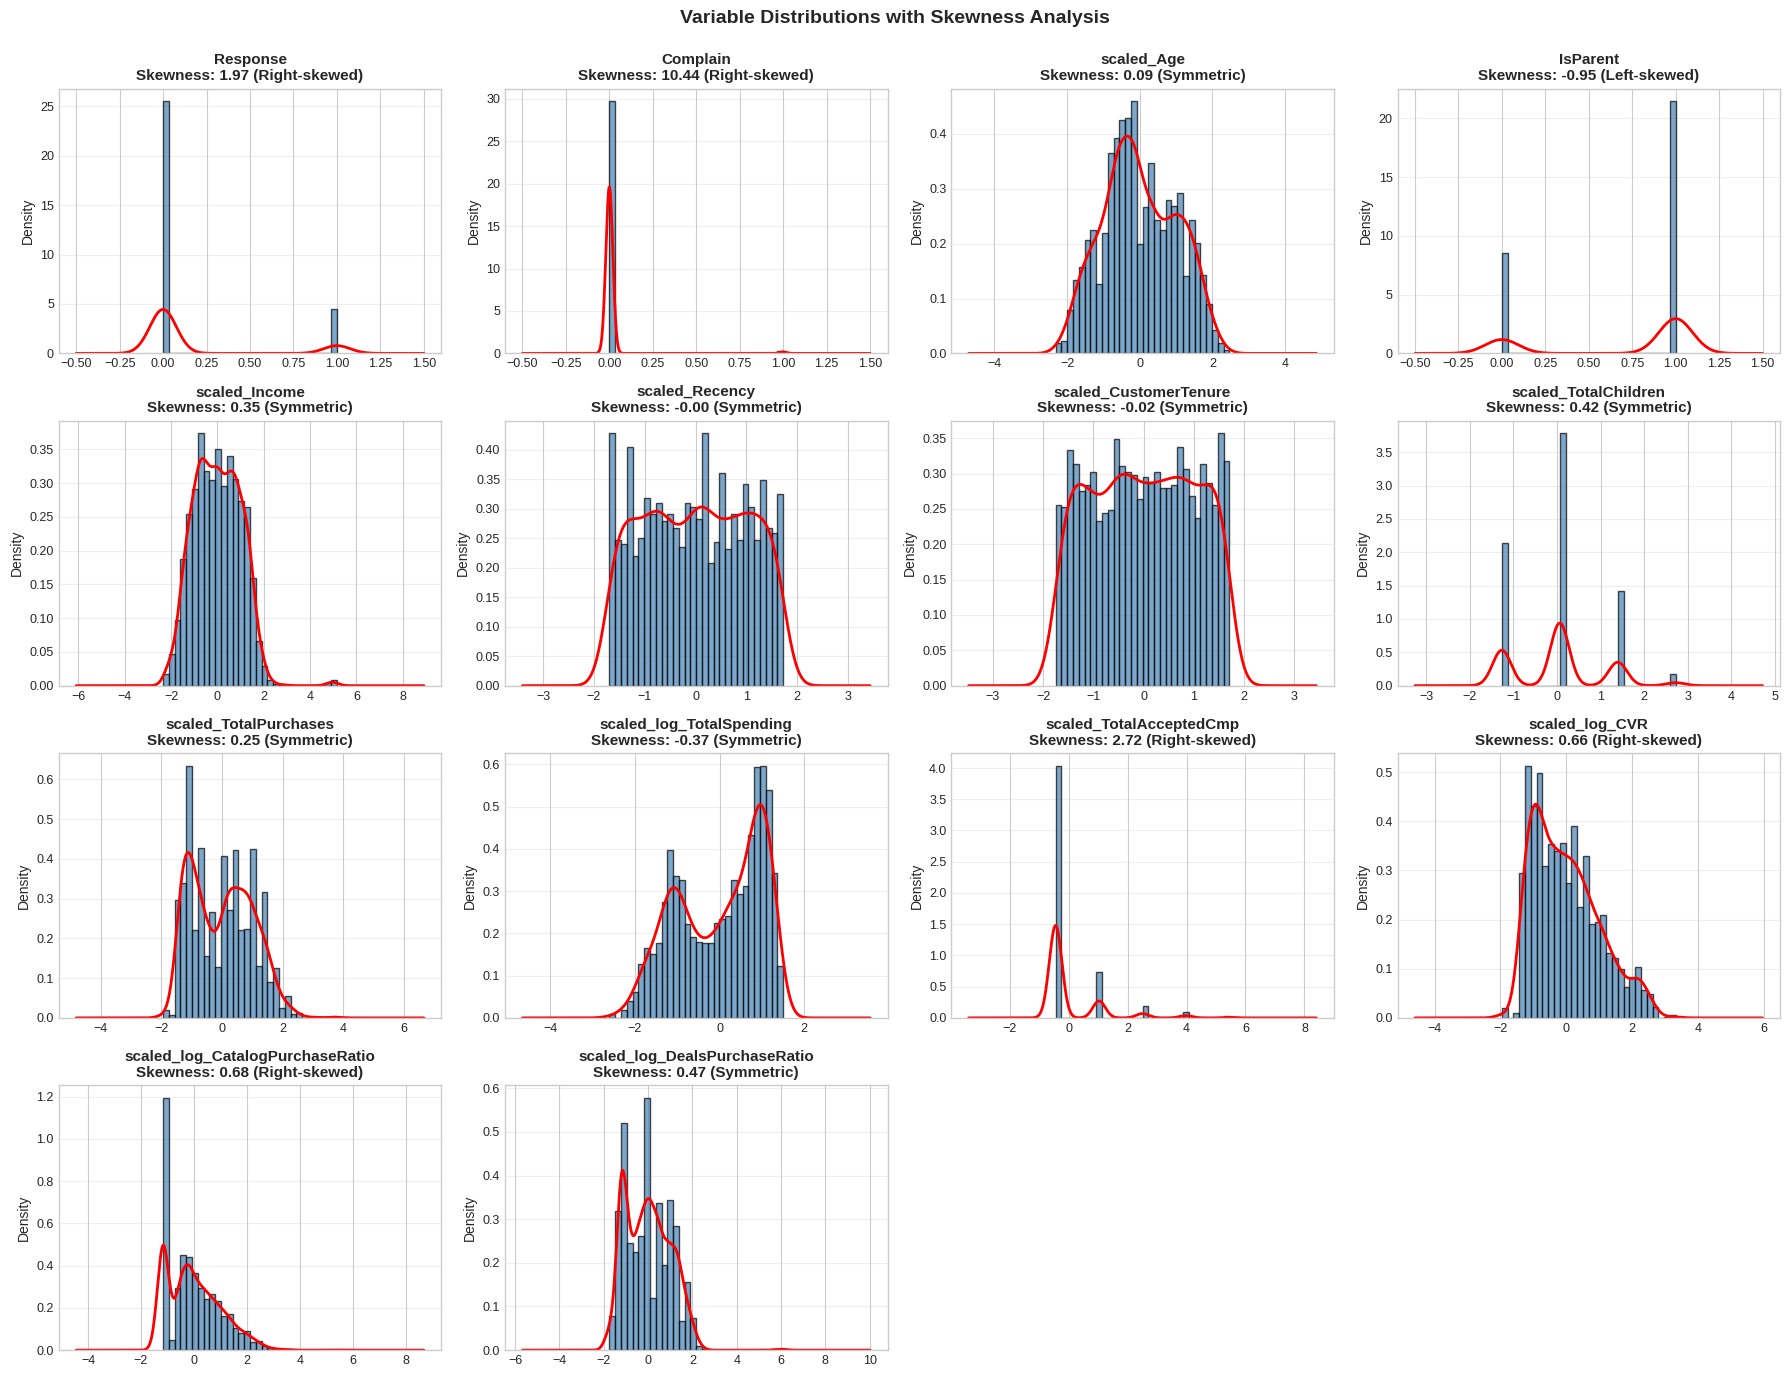

In [34]:
after_scaling = [
    "Response",
    "Complain",
    "scaled_Age",
    "IsParent",
    "scaled_Income",
    "scaled_Recency",
    "scaled_CustomerTenure",
    "scaled_TotalChildren",
    "scaled_TotalPurchases",
    "scaled_log_TotalSpending",
    "scaled_TotalAcceptedCmp",
    "scaled_log_CVR",
    "scaled_log_CatalogPurchaseRatio",
    "scaled_log_DealsPurchaseRatio",
]

# Pass the DataFrame subset with only the relevant scaled and binary columns to the visualization function
visualize_distribution_and_skewness(df_clean[after_scaling])

After examining skewness on scaled features, most variables exhibit balanced distributions with low skewness values and require
no additional transformation. scaled_Age, scaled_Income, scaled_Recency, scaled_CustomerTenure, scaled_TotalChildren, and
scaled_TotalPurchases are all approximately symmetric (skewness < |0.5|) and can be retained unchanged.

High skewness values in some variables are natural consequences of the data structure, not problematic conditions requiring
transformation:

• Complain (skew +10.44) is a binary variable with most values at 0 and a small portion at 1. For binary variables, logarithmic
or square-root transformations are not applicable; the 0/1 format is already optimal.

• Response (skew +1.97) as a binary target variable does not require logarithmic or square-root transformation; the 0/1 format
is retained as-is for classification modeling.

• scaled_TotalAcceptedCmp (skew +2.72) is the sum of five binary variables (AcceptedCmp1–AcceptedCmp5), resulting in a
distribution concentrated at 0 with sparse observations at higher values. Applying log transformation would unnecessarily alter
the distribution. The skewness of +2.72 is natural for accumulated count data from binary variables and does not require correction.

• scaled_log_CVR (skew +0.66), scaled_log_CatalogPurchaseRatio (skew +0.68), and IsParent (skew -0.95) exhibit moderate skewness
but remain within acceptable ranges (|skew| < 1) for regression modeling. No further transformation is necessary.

• scaled_log_DealsPurchaseRatio (skew +0.47) and scaled_log_TotalSpending (skew -0.37) demonstrate near-symmetric distributions
requiring no additional transformation.


In [35]:
# List of scaled numerical and binary/encoded features
features_scaled = [
    'scaled_Income', 'scaled_Recency', 'scaled_Age', 'scaled_TotalPurchases',
    'scaled_TotalChildren', 'scaled_CustomerTenure', 'Education_Diploma',
    'Education_High School', 'Education_Master', 'Education_PhD',
    'IsParent', 'scaled_log_TotalSpending',
    'scaled_TotalAcceptedCmp', 'scaled_log_CVR',
    'scaled_log_CatalogPurchaseRatio', 'scaled_log_DealsPurchaseRatio',
    "Marital_Status_Single", 'Response', 'Complain'
]

# Create new dataframe with only scaled features
df_scaled = df_clean[features_scaled].copy()

print(f"New scaled dataset shape: {df_scaled.shape}")
print(f"Columns: {df_scaled.columns.tolist()}")

New scaled dataset shape: (2236, 19)
Columns: ['scaled_Income', 'scaled_Recency', 'scaled_Age', 'scaled_TotalPurchases', 'scaled_TotalChildren', 'scaled_CustomerTenure', 'Education_Diploma', 'Education_High School', 'Education_Master', 'Education_PhD', 'IsParent', 'scaled_log_TotalSpending', 'scaled_TotalAcceptedCmp', 'scaled_log_CVR', 'scaled_log_CatalogPurchaseRatio', 'scaled_log_DealsPurchaseRatio', 'Marital_Status_Single', 'Response', 'Complain']


We create a new DataFrame df_scaled containing only the scaled and encoded features by copying the relevant columns from df_clean. This gives us the dataset dimensions and column names—everything ready to feed into the model.

In [36]:
df_scaled.head()

,scaled_Income,scaled_Recency,scaled_Age,scaled_TotalPurchases,scaled_TotalChildren,scaled_CustomerTenure,Education_Diploma,Education_High School,Education_Master,Education_PhD,IsParent,scaled_log_TotalSpending,scaled_TotalAcceptedCmp,scaled_log_CVR,scaled_log_CatalogPurchaseRatio,scaled_log_DealsPurchaseRatio,Marital_Status_Single,Response,Complain
0,0.288947,0.306856,1.016868,1.319340,-1.264308,1.529793,0.0,0.0,0.0,0.0,0,1.202519,-0.438933,0.153968,1.999889,-0.454638,1.0,1,0
1,-0.262003,-0.383971,1.273264,-1.155857,1.395139,-1.191143,0.0,0.0,0.0,0.0,1,-1.558363,-0.438933,-0.860271,0.134054,1.231315,1.0,0,0
2,0.918423,-0.798467,0.333146,0.798246,-1.264308,-0.206659,0.0,0.0,0.0,0.0,0,0.703320,-0.438933,0.588307,-0.318279,-1.222757,0.0,0,0
3,-1.182183,-0.798467,-1.290693,-0.895310,0.065416,-1.062517,0.0,0.0,0.0,0.0,1,-1.111381,-0.438933,-0.780621,-1.164327,0.630514,0.0,0,0
4,0.296187,1.550344,-1.034298,0.537699,0.065416,-0.953679,0.0,0.0,0.0,1.0,1,0.289489,-0.438933,0.222092,0.194636,0.897116,0.0,0,0


---
## Step 2: Exploratory Data Analysis (EDA)

In this section, we perform comprehensive EDA to:
1. Understand variable distributions
2. Analyze correlations between features
3. Explore relationships with the target variable
4. Apply clustering to identify customer segments
5. Visualize patterns and insights

### 2.1 Target Variable Analysis

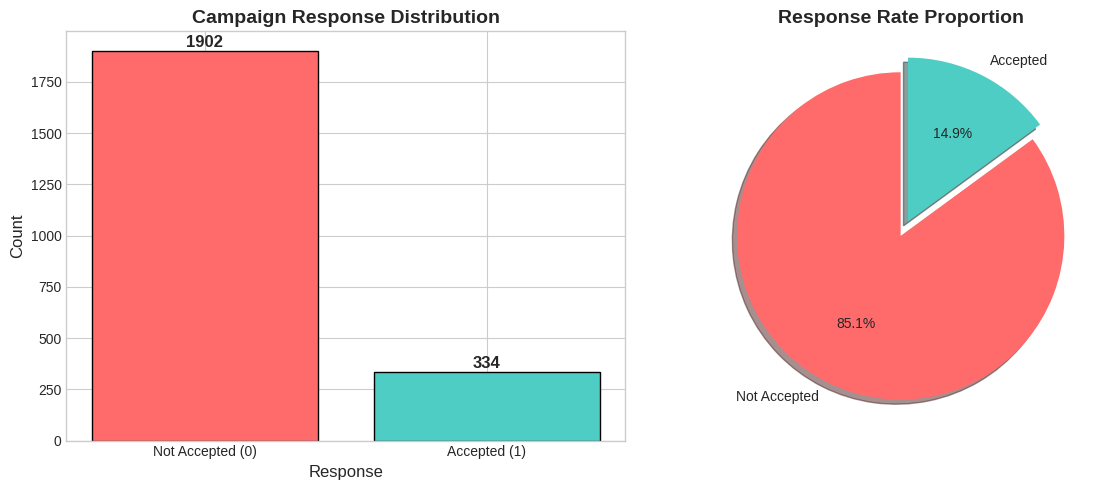


 Insight: The dataset shows class imbalance with only ~15% positive responses.
   This will be addressed using SMOTE or class weights during model training.


In [37]:
# TARGET VARIABLE DISTRIBUTION


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
response_counts = df_scaled['Response'].value_counts()
colors = ['#ff6b6b', '#4ecdc4']

axes[0].bar(response_counts.index.astype(str), response_counts.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Response', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Campaign Response Distribution', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Not Accepted (0)', 'Accepted (1)'])

# Add count labels on bars
for i, v in enumerate(response_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(response_counts.values, labels=['Not Accepted', 'Accepted'],
            autopct='%1.1f%%', colors=colors, explode=(0, 0.1),
            shadow=True, startangle=90)
axes[1].set_title('Response Rate Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Insight: The dataset shows class imbalance with only ~15% positive responses.")
print("   This will be addressed using SMOTE or class weights during model training.")

We created a bar chart and pie chart to show how many customers accepted or did not accept the campaign. The bar chart displays the actual counts, while the pie chart shows the percentage breakdown.

The results reveal a clear imbalance: most customers (85.1%) did not accept the campaign, while only a small portion (14.9%) responded positively. This suggests that any model built on this data should address this class imbalance.

### 2.2 Numerical and Categorical Features Distribution



### 2.2.1 Numerical Features Distribution

Summary table was created to show statistical characteristics of all scaled features including mean, standard deviation, percentiles, skewness, and kurtosis to verify that preprocessing was successful. This confirms all continuous features have been properly standardized to mean≈0 and std≈1, while binary features remain as 0/1 values, ensuring the dataset is ready for model training.

In [38]:
# Select key numerical features
key_features = [
    'scaled_Income', 'scaled_Recency', 'scaled_Age', 'scaled_TotalPurchases',
    'scaled_TotalChildren', 'scaled_CustomerTenure',
    'IsParent', 'scaled_log_TotalSpending',
    'scaled_TotalAcceptedCmp', 'scaled_log_CVR',
    'scaled_log_CatalogPurchaseRatio', 'scaled_log_DealsPurchaseRatio',
    'Response', 'Complain'
]
# Create summary statistics
summary_stats = df_scaled[key_features].describe().round(2).T

# Add additional statistics
summary_stats['skewness'] = df_scaled[key_features].skew().round(2)
summary_stats['kurtosis'] = df_scaled[key_features].kurtosis().round(2)

print("DESCRIPTIVE STATISTICS SUMMARY")
print("="*80)
print(summary_stats)

DESCRIPTIVE STATISTICS SUMMARY
                                  count  mean   std   min   25%   50%   75%  \
scaled_Income                    2236.0 -0.00  1.00 -2.35 -0.77 -0.03  0.76   
scaled_Recency                   2236.0 -0.00  1.00 -1.70 -0.87 -0.00  0.86   
scaled_Age                       2236.0  0.00  1.00 -2.32 -0.69 -0.09  0.85   
scaled_TotalPurchases            2236.0  0.00  1.00 -1.94 -0.90  0.02  0.80   
scaled_TotalChildren             2236.0  0.00  1.00 -1.26 -1.26  0.07  0.07   
scaled_CustomerTenure            2236.0  0.00  1.00 -1.75 -0.86  0.01  0.87   
IsParent                         2236.0  0.72  0.45  0.00  0.00  1.00  1.00   
scaled_log_TotalSpending         2236.0  0.00  1.00 -2.61 -0.93  0.25  0.91   
scaled_TotalAcceptedCmp          2236.0 -0.00  1.00 -0.44 -0.44 -0.44 -0.44   
scaled_log_CVR                   2236.0  0.00  1.00 -1.95 -0.83 -0.15  0.63   
scaled_log_CatalogPurchaseRatio  2236.0 -0.00  1.00 -1.16 -1.16 -0.14  0.68   
scaled_log_DealsPurch

The summary shows continuous features are well standardized with mean close to 0 and standard deviation near 1, confirming successful preprocessing.
Skewness values indicate most continuous variables are fairly symmetric, while some binary/categorical features (e.g., Complain, Response) and biner-count based variable (scaled_TotalAcceptedCmp) are skewed, as expected.
The distribution plots visualize these characteristics, showing mostly symmetric continuous data and clearly skewed binary features.

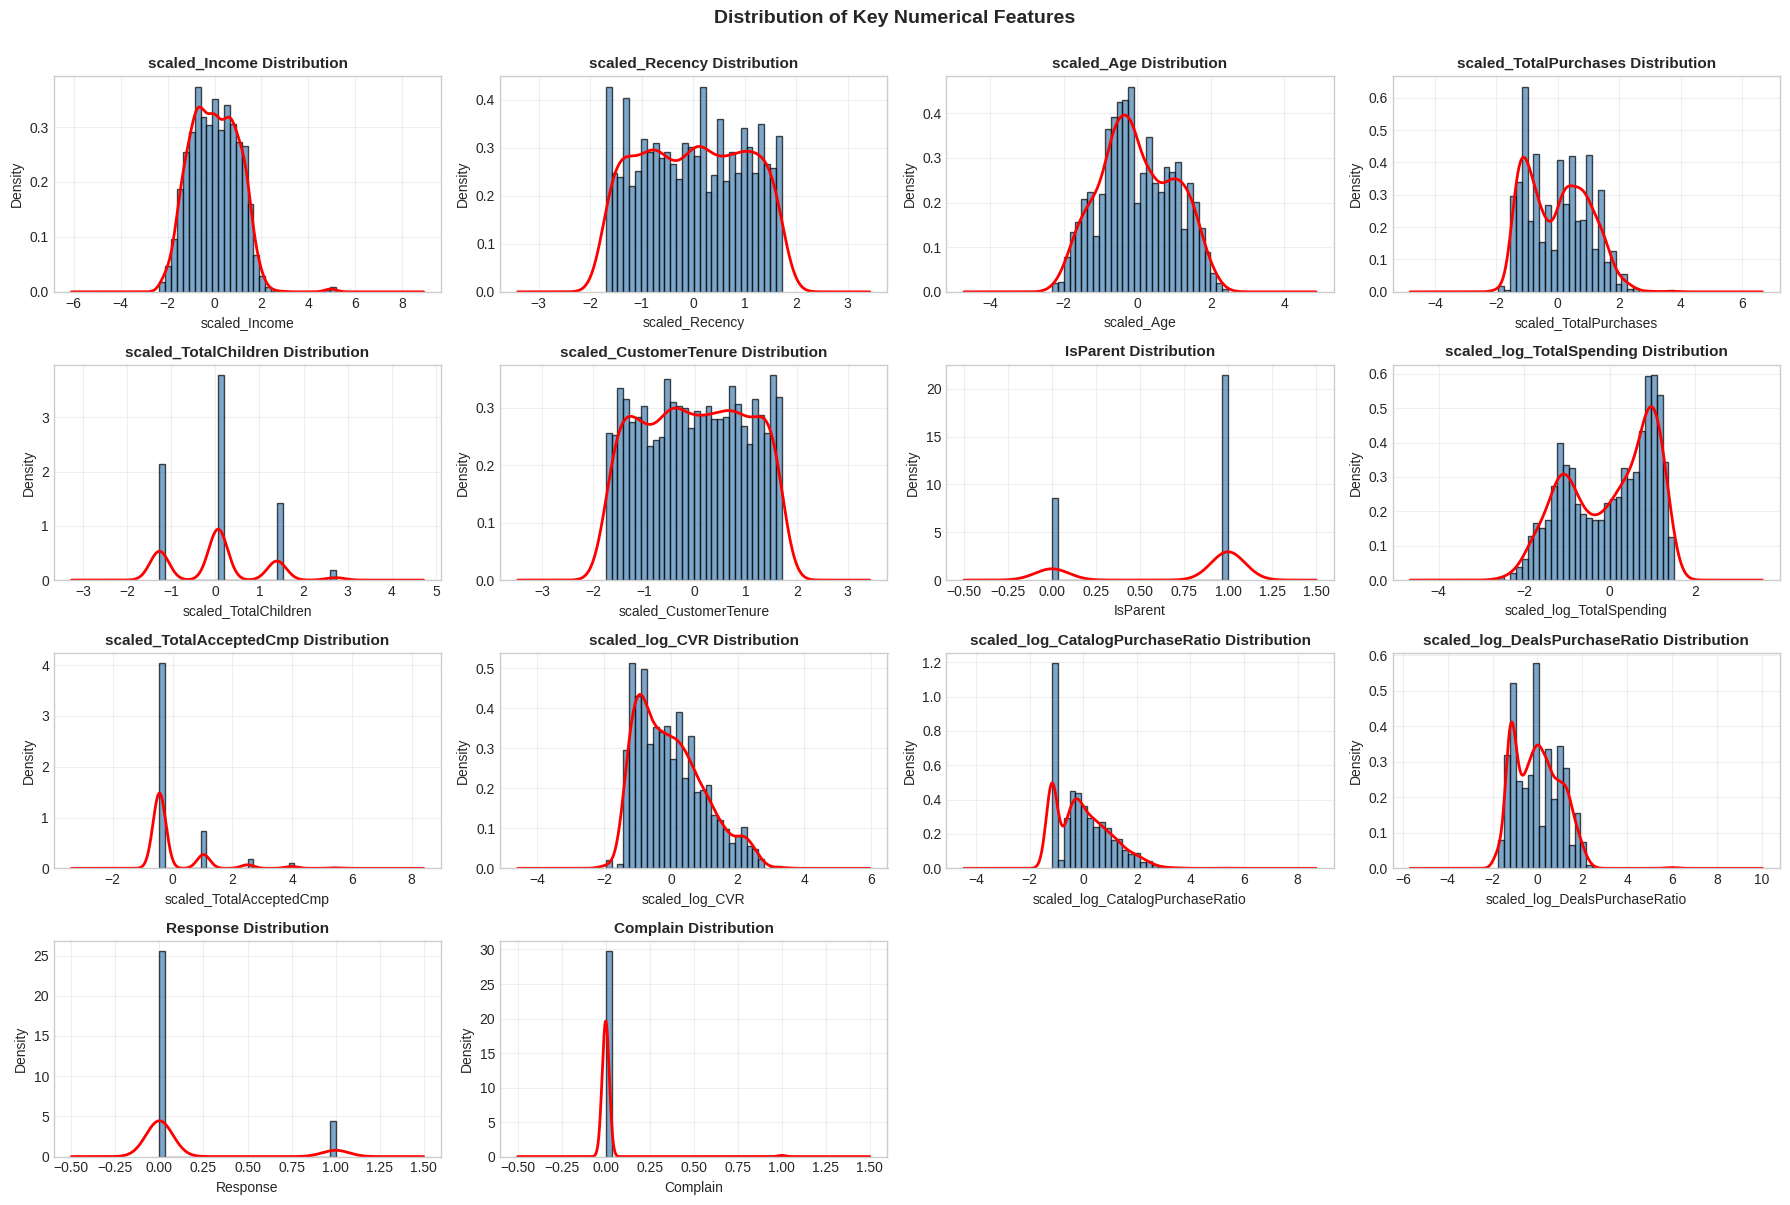


Created 14 distribution plots


In [39]:
# DISTRIBUTION OF KEY NUMERICAL FEATURES

n_features = len(key_features)  #
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))  # automatically calculate rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for idx, col in enumerate(key_features):
    # Plot histogram with KDE
    axes[idx].hist(df_scaled[col], bins=30, color='steelblue',
                   edgecolor='black', alpha=0.7, density=True)
    df_scaled[col].plot(kind='kde', ax=axes[idx], color='red', linewidth=2)

    axes[idx].set_title(f'{col} Distribution', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Density')
    axes[idx].grid(True, alpha=0.3)

# Hide unused subplots if any
for j in range(n_features, len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribution of Key Numerical Features', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nCreated {n_features} distribution plots")

To visualize this, We create a set of distribution plots for key numerical features after scaling, showing histograms with overlaid KDE lines for each variable. It highlights how most continuous features have near-normal shapes, while certain count or aggregated features like scaled_TotalAcceptedCmp have naturally skewed distributions due to their construction.

As discussed before, scaled_TotalAcceptedCmp (skewness 2.72) represents the sum of five binary variables, causing its distribution to cluster heavily at zero with sparse higher values. Applying a log transformation here is unnecessary and could distort the data, since its skewness is expected and normal for summed binary counts.

### 2.2.2 Categorical Features Distribution

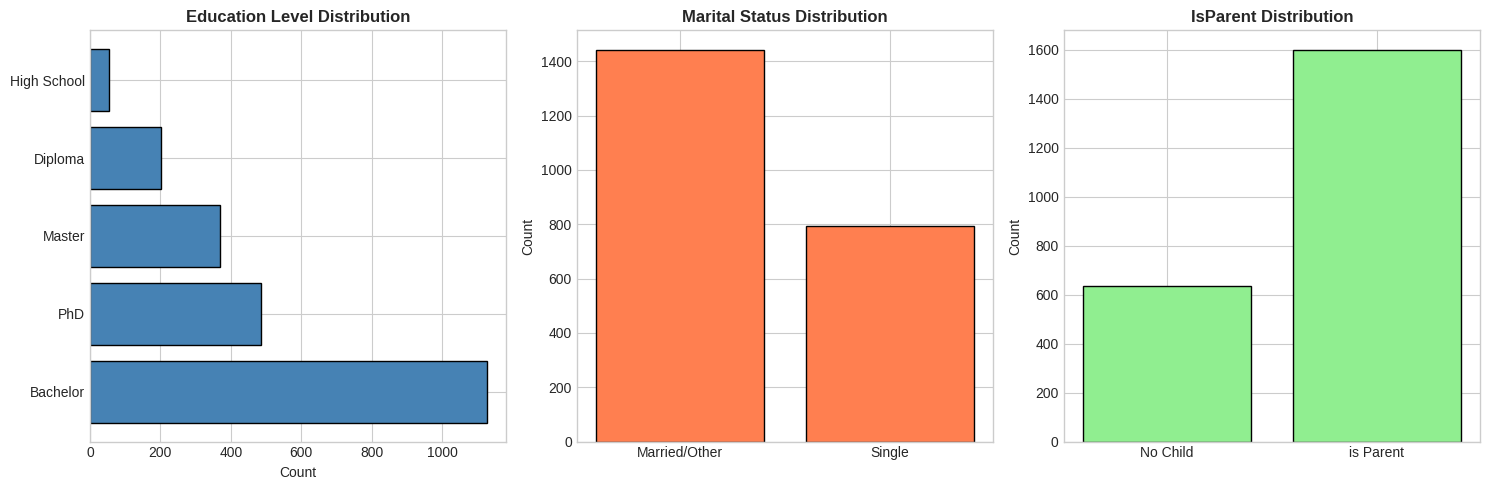

Education distribution:
Education_Bachelor       1126.0
Education_PhD             485.0
Education_Master          370.0
Education_Diploma         201.0
Education_High School      54.0
dtype: float64

Marital status distribution:
Marital_Status_Single
0.0    1442
1.0     794
Name: count, dtype: int64

IsParent distribution:
IsParent
0     637
1    1599
Name: count, dtype: int64


In [40]:
# Get all education columns
education_cols = [col for col in df_scaled.columns if col.startswith('Education_')]

# Count each education level
education_counts = df_scaled[education_cols].sum().to_dict()

# Count Bachelor (reference category - all education columns = 0)
bachelor_count = len(df_scaled) - sum(education_counts.values())
education_counts['Education_Bachelor'] = bachelor_count

# Sort and prepare for plotting
education_counts = pd.Series(education_counts).sort_values(ascending=False)

# Marital Status
marital_single = df_scaled['Marital_Status_Single'].value_counts().sort_index()

# IsParent
isparent_counts = df_scaled['IsParent'].value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Education
axes[0].barh(education_counts.index, education_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Education Level Distribution', fontweight='bold')
axes[0].set_xlabel('Count')
axes[0].set_yticklabels([label.replace('Education_', '') for label in education_counts.index])

# Marital Status
axes[1].bar(['Married/Other', 'Single'], [marital_single[0], marital_single[1]],
            color='coral', edgecolor='black')
axes[1].set_title('Marital Status Distribution', fontweight='bold')
axes[1].set_ylabel('Count')

# IsParent
axes[2].bar(['No Child', 'is Parent'], [isparent_counts[0], isparent_counts[1]],
            color='lightgreen', edgecolor='black')
axes[2].set_title('IsParent Distribution', fontweight='bold')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('categorical_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Education distribution:\n{education_counts}")
print(f"\nMarital status distribution:\n{marital_single}")
print(f"\nIsParent distribution:\n{isparent_counts}")

We analyzed categorical variable distributions by aggregating one-hot encoded education columns and counting binary variables for marital status and parental status. Results show most customers hold Bachelor's degrees (1,126), are married (1,442), and are parents (1,599). This demographic profile—educated, married, with families—provides important context for designing targeted marketing campaigns and customer segmentation strategies.

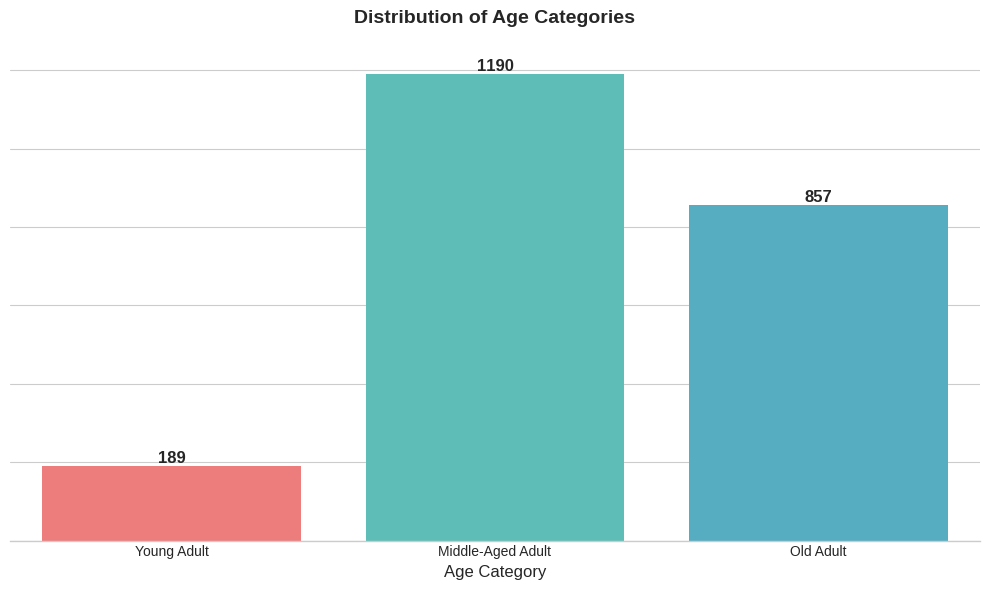

In [41]:
# Create temporary age categories
df_clean['Age_Categories'] = np.where(df_clean['Age'] < 40, 'Young Adult',
                              np.where(df_clean['Age'] < 60, 'Middle-Aged Adult',
                                       'Old Adult'))

# Single plot with custom colors
plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']  # coral, teal, blue
ax = sns.countplot(x='Age_Categories', data=df_clean, palette=colors,
                   order=['Young Adult', 'Middle-Aged Adult', 'Old Adult'])

# Add count labels on bars
for bar in ax.patches:
    count = int(bar.get_height())
    ax.annotate(count,
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Distribution of Age Categories', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Age Category', fontsize=12)
plt.ylabel('')
plt.tick_params(axis='y', left=False, labelleft=False)
sns.despine(left=True, bottom=False)  # Remove left border
plt.tight_layout()
plt.savefig('age_categories_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


**Age Segmentation Analysis**


We created three age categories to simplify customer analysis: Young Adult (<40), Middle-Aged Adult (40-59), and Old Adult (≥60). The distribution was visualized using a bar chart with count labels for clear interpretation.

Results
* Middle-Aged Adult: 1,190 individuals (dominant segment)

* Old Adult: 857 individuals

* Young Adult: 189 individuals (smallest segment)

The customer base is predominantly aged 40+, representing over 90% of the population. This suggests marketing and product strategies should prioritize the mature market segment, while the Young Adult segment (8%) presents untapped growth potential.

### 2.3 Correlation Analysis

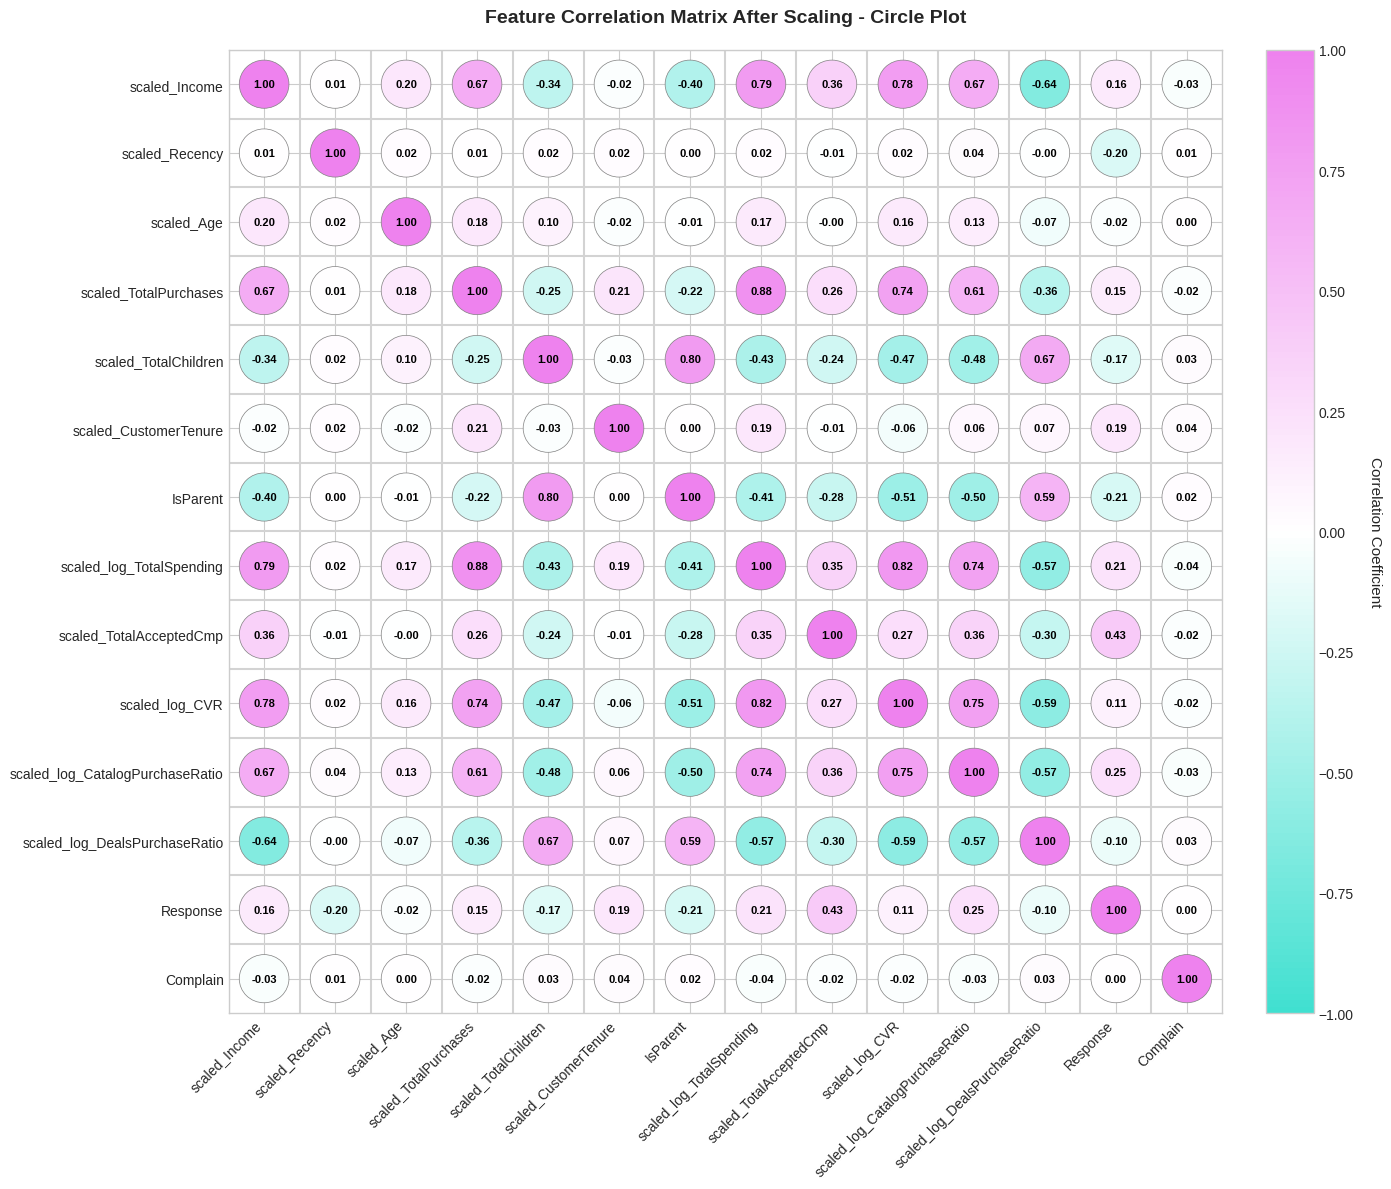

In [42]:
# Features to include in correlation matrix (scaled versions)
scaled_features = [
    'scaled_Income', 'scaled_Recency', 'scaled_Age', 'scaled_TotalPurchases',
    'scaled_TotalChildren', 'scaled_CustomerTenure',
    'IsParent', 'scaled_log_TotalSpending',
    'scaled_TotalAcceptedCmp', 'scaled_log_CVR',
    'scaled_log_CatalogPurchaseRatio', 'scaled_log_DealsPurchaseRatio',
    'Response', 'Complain'
]


# Calculate correlation matrix for scaled features
corr_matrix = df_scaled[scaled_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))
colors = ['#40E0D0', '#FFFFFF', '#EE82EE']  # turquoise, white, violet
cmap = LinearSegmentedColormap.from_list('corrplot', colors, N=150)
n = len(corr_matrix)

ax.set_facecolor('white')

for i in range(n):
    for j in range(n):
        corr = corr_matrix.iloc[i, j]
        circle = Circle(
            (j, i),
            0.35,  # fixed radius
            color=cmap((corr + 1) / 2),
            ec='gray', linewidth=0.5
        )
        ax.add_patch(circle)

        ax.text(j, i, f'{corr:.2f}', ha='center', va='center',
                fontsize=8, color='black', weight='bold')

ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(n - 0.5, -0.5)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(corr_matrix.columns, fontsize=10)

ax.grid(which='minor', color='lightgray', linestyle='-', linewidth=1.5)
ax.set_xticks(np.arange(n) - 0.5, minor=True)
ax.set_yticks(np.arange(n) - 0.5, minor=True)
ax.tick_params(which='minor', size=0)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-1, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Correlation Coefficient', rotation=270, labelpad=20, fontsize=11)

plt.title('Feature Correlation Matrix After Scaling - Circle Plot', fontsize=14, weight='bold', pad=20)

plt.tight_layout()
plt.savefig('correlation_circle_matrix_scaled.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
# Display correlation matrix as DataFrame
print("CORRELATION MATRIX AFTER SCALING")
print("="*80)

# Convert to DataFrame and display
corr_df = corr_matrix.round(3)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

corr_df


CORRELATION MATRIX AFTER SCALING


,scaled_Income,scaled_Recency,scaled_Age,scaled_TotalPurchases,scaled_TotalChildren,scaled_CustomerTenure,IsParent,scaled_log_TotalSpending,scaled_TotalAcceptedCmp,scaled_log_CVR,scaled_log_CatalogPurchaseRatio,scaled_log_DealsPurchaseRatio,Response,Complain
scaled_Income,1.000,0.008,0.199,0.666,-0.341,-0.024,-0.401,0.788,0.364,0.782,0.666,-0.643,0.161,-0.028
scaled_Recency,0.008,1.000,0.019,0.006,0.018,0.024,0.000,0.018,-0.012,0.016,0.035,-0.001,-0.199,0.005
scaled_Age,0.199,0.019,1.000,0.180,0.096,-0.016,-0.011,0.172,-0.000,0.161,0.134,-0.069,-0.019,0.004
scaled_TotalPurchases,0.666,0.006,0.180,1.000,-0.246,0.207,-0.221,0.876,0.257,0.744,0.606,-0.361,0.155,-0.016
scaled_TotalChildren,-0.341,0.018,0.096,-0.246,1.000,-0.026,0.798,-0.433,-0.244,-0.471,-0.481,0.672,-0.169,0.031
scaled_CustomerTenure,-0.024,0.024,-0.016,0.207,-0.026,1.000,0.001,0.188,-0.012,-0.063,0.056,0.070,0.194,0.036
IsParent,-0.401,0.000,-0.011,-0.221,0.798,0.001,1.000,-0.414,-0.281,-0.510,-0.504,0.590,-0.205,0.018
scaled_log_TotalSpending,0.788,0.018,0.172,0.876,-0.433,0.188,-0.414,1.000,0.350,0.819,0.740,-0.566,0.213,-0.037
scaled_TotalAcceptedCmp,0.364,-0.012,-0.000,0.257,-0.244,-0.012,-0.281,0.350,1.000,0.266,0.358,-0.296,0.426,-0.021
scaled_log_CVR,0.782,0.016,0.161,0.744,-0.471,-0.063,-0.510,0.819,0.266,1.000,0.753,-0.592,0.112,-0.021


**CORRELATION ANALYSIS: RELATIONSHIP WITH RESPONSE AND INTER-FEATURE PATTERNS**

**Correlation with Response (Target Variable)**

The strongest predictor is scaled_TotalAcceptedCmp (0.426), indicating that customers with prior campaign acceptance are
significantly more likely to respond to future campaigns. Moderate positive correlations appear in scaled_log_CatalogPurchaseRatio
(0.249), scaled_log_TotalSpending (0.213), and scaled_CustomerTenure (0.194), suggesting that catalog shopping behavior, overall
spending levels, and customer loyalty influence campaign responsiveness.

Weaker predictors include scaled_Income (0.161), scaled_TotalPurchases (0.155), and scaled_log_CVR (0.112). Negative correlations
emerge in IsParent (-0.205), scaled_Recency (-0.199), and scaled_TotalChildren (-0.169), indicating that parents, customers with
recent purchases, and those with more children respond less frequently to campaigns. scaled_log_DealsPurchaseRatio shows a weak
negative correlation (-0.1), while scaled_Age (-0.019) and Complain (0.0) exhibit negligible relationships with response.

**Inter-Feature Relationships**

scaled_TotalPurchases and scaled_log_TotalSpending demonstrate the strongest correlation (0.876), confirming that frequent
shoppers generate higher cumulative revenue. scaled_log_CVR and scaled_log_TotalSpending are highly correlated (0.819),
indicating that customers with higher conversion rates contribute substantially to overall spending. scaled_Income strongly
correlates with scaled_log_TotalSpending (0.788) and scaled_log_CVR (0.782), demonstrating that higher-income customers
exhibit both greater spending per transaction and higher web visit conversion rates.

Parental status exhibits strong negative relationships with spending behavior: IsParent negatively correlates with
scaled_log_CVR (-0.51), scaled_log_CatalogPurchaseRatio (-0.504), scaled_log_TotalSpending (-0.414), and scaled_Income (-0.401).
Similarly, scaled_TotalChildren shows negative correlations with scaled_log_CatalogPurchaseRatio (-0.481) and scaled_log_CVR
(-0.471), confirming that families with children face constrained spending capacity and lower catalog purchasing behavior.

Deal-seeking behavior displays distinct patterns: scaled_log_DealsPurchaseRatio negatively correlates with scaled_Income (-0.643),
scaled_log_CVR (-0.592), and scaled_log_TotalSpending (-0.566), indicating that lower-income customers rely more heavily on
promotional deals. Conversely, scaled_TotalChildren positively correlates with scaled_log_DealsPurchaseRatio (0.672), suggesting
families with children prioritize discount purchases to manage budget constraints.

**Multicollinearity Assessment**

Despite strong inter-feature correlations, multicollinearity is not a concern. VIF testing conducted after log transformation
and standardization confirmed all features exhibit VIF values below 10 (with most below 5), meeting acceptable threshold criteria
and ensuring model stability for regression analysis.



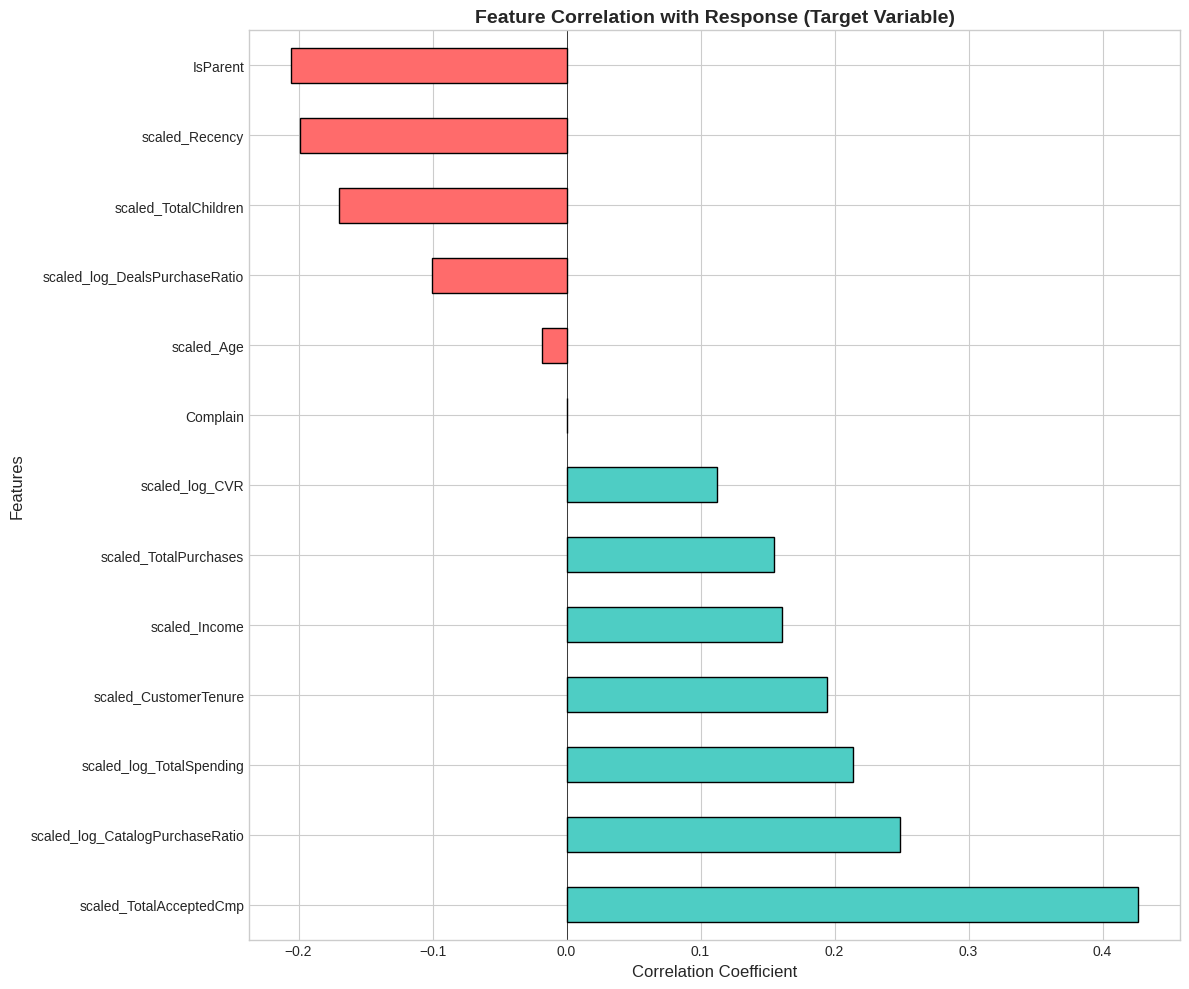


 Top 5 Positive Correlations with Response:
scaled_TotalAcceptedCmp            0.426206
scaled_log_CatalogPurchaseRatio    0.248984
scaled_log_TotalSpending           0.213446
scaled_CustomerTenure              0.194232
scaled_Income                      0.161121
Name: Response, dtype: float64

 Top 5 Negative Correlations with Response:
scaled_Age                      -0.018557
scaled_log_DealsPurchaseRatio   -0.100265
scaled_TotalChildren            -0.169451
scaled_Recency                  -0.198781
IsParent                        -0.205278
Name: Response, dtype: float64


In [44]:
# CORRELATION WITH TARGET VARIABLE


# Get correlations with Response
target_corr = corr_matrix['Response'].drop('Response').sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 10))
colors = ['#4ecdc4' if x > 0 else '#ff6b6b' for x in target_corr.values]
target_corr.plot(kind='barh', color=colors, edgecolor='black')
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Correlation with Response (Target Variable)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig('target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Top 5 Positive Correlations with Response:")
print(target_corr.head())
print("\n Top 5 Negative Correlations with Response:")
print(target_corr.tail())

The strongest positive correlation with Response is from scaled_TotalAcceptedCmp, indicating prior campaign acceptance strongly predicts future responsiveness, followed by scaled_log_CatalogPurchaseRatio, scaled_log_TotalSpending, scaled_CustomerTenure, and scaled_Income, which relate to catalog shopping behavior, customer spending, loyalty, and income levels. In contrast, features like IsParent, scaled_Recency, scaled_TotalChildren, and scaled_log_DealsPurchaseRatio show negative correlations, suggesting that being a parent, having recent purchase activity, having more children, or relying heavily on promotional deals is associated with lower campaign responsiveness.

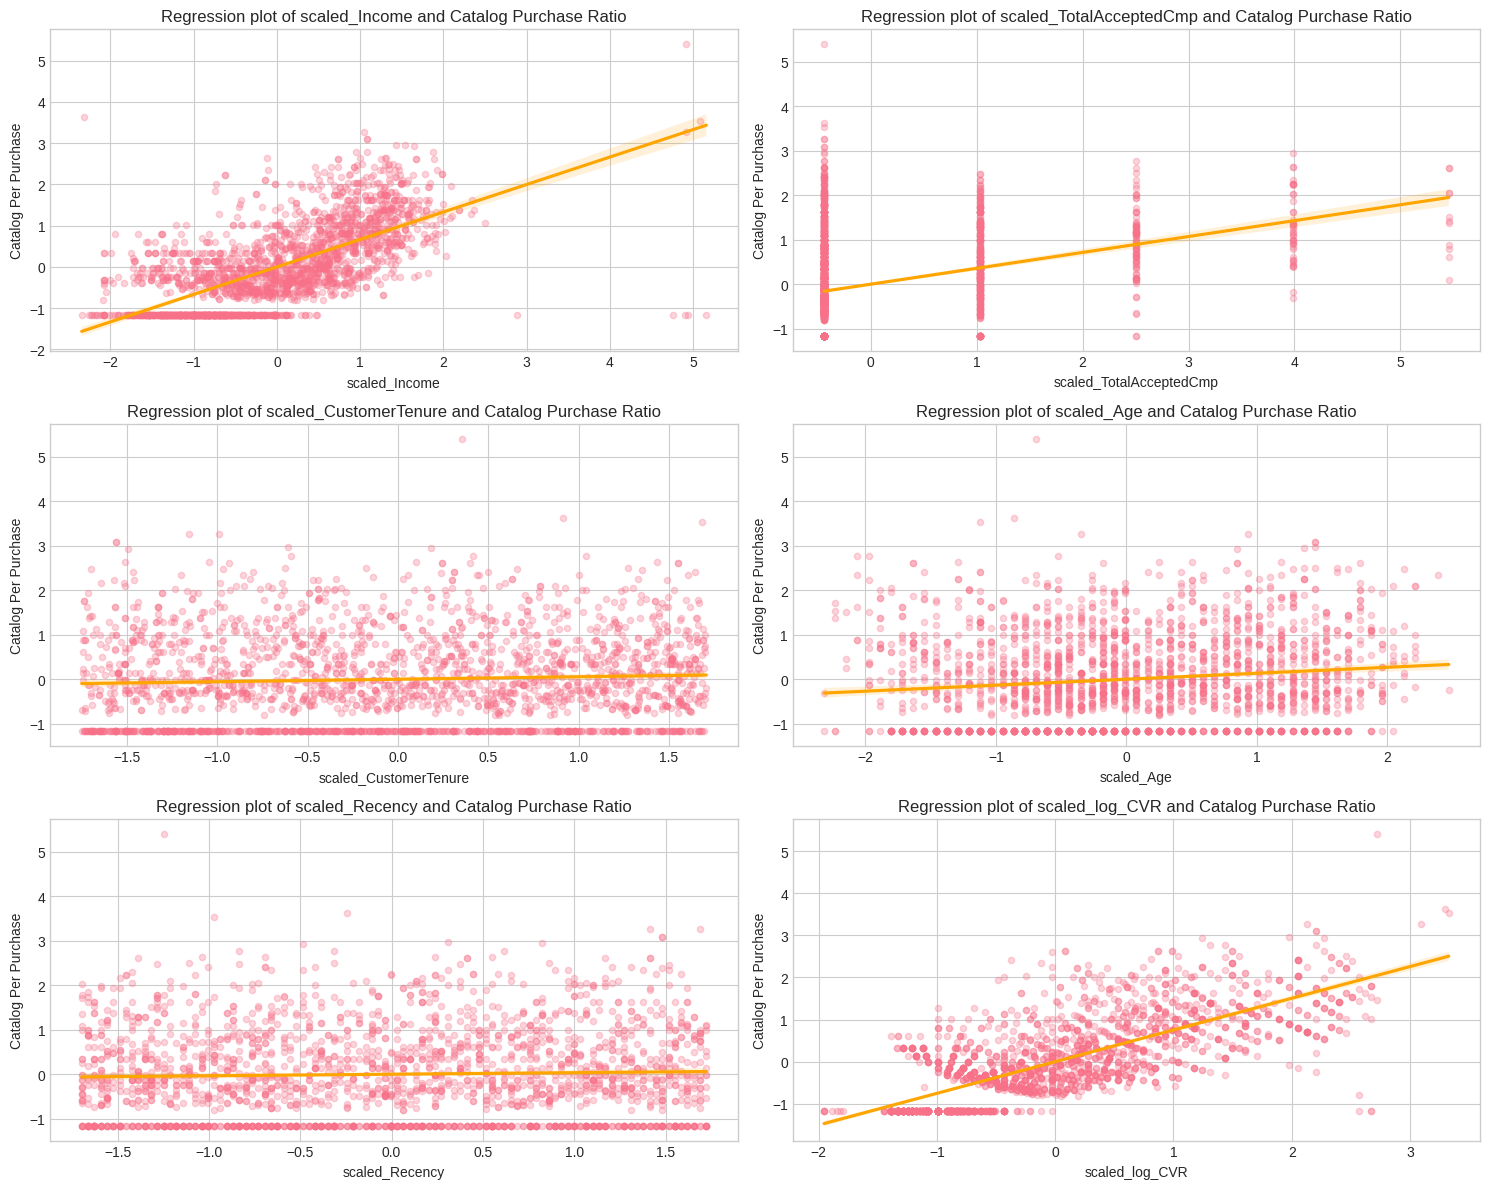

In [45]:
variables_scaled = ['scaled_Income', 'scaled_TotalAcceptedCmp', 'scaled_CustomerTenure', 'scaled_Age', 'scaled_Recency', 'scaled_log_CVR']

plt.figure(figsize=(15, 12))  # Larger height to fit 3 rows x 2 cols

for i, var in enumerate(variables_scaled):
    plt.subplot(3, 2, i + 1)  # 3 rows, 2 columns grid
    sns.regplot(x=df_scaled[var], y=df_scaled['scaled_log_CatalogPurchaseRatio'],
                scatter_kws={'s': 20, 'alpha': 0.3},
                line_kws={'color': 'orange'})
    plt.title(f'Regression plot of {var} and Catalog Purchase Ratio', fontsize=12)
    plt.xlabel(var)
    plt.ylabel('Catalog Per Purchase')

# Turn off the last unused subplot (6th subplot)
if len(variables_scaled) < 6:
    plt.subplot(3, 2, 6).axis('off')

plt.tight_layout()
plt.show()

**REGRESSION ANALYSIS: PREDICTORS OF CATALOG PURCHASE BEHAVIOR**

The regression plots show how different customer features relate to catalog purchase behavior. scaled_Income has a clear positive linear relationship with catalog purchases—customers with higher income buy more through catalogs. scaled_log_CVR shows a similar strong pattern, where customers with better conversion rates on the website also prefer catalog shopping. This makes sense: engaged customers tend to use multiple channels.

scaled_TotalAcceptedCmp shows a positive trend too, but the data is more scattered and clustered at discrete points. Customers who respond to more campaigns do buy more via catalogs, but the relationship isn't as tight. scaled_CustomerTenure and scaled_Age both show weak trends with lots of scatter, suggesting that how long someone has been a customer or their age doesn't strongly predict catalog preferences.

scaled_Recency is nearly flat—there's almost no relationship between recent purchase activity and catalog buying. This means recency doesn't matter much for catalog channel choice. Overall, income and conversion behavior drive catalog purchases most strongly, while age, tenure, and recency have little effect on whether customers prefer this channel.


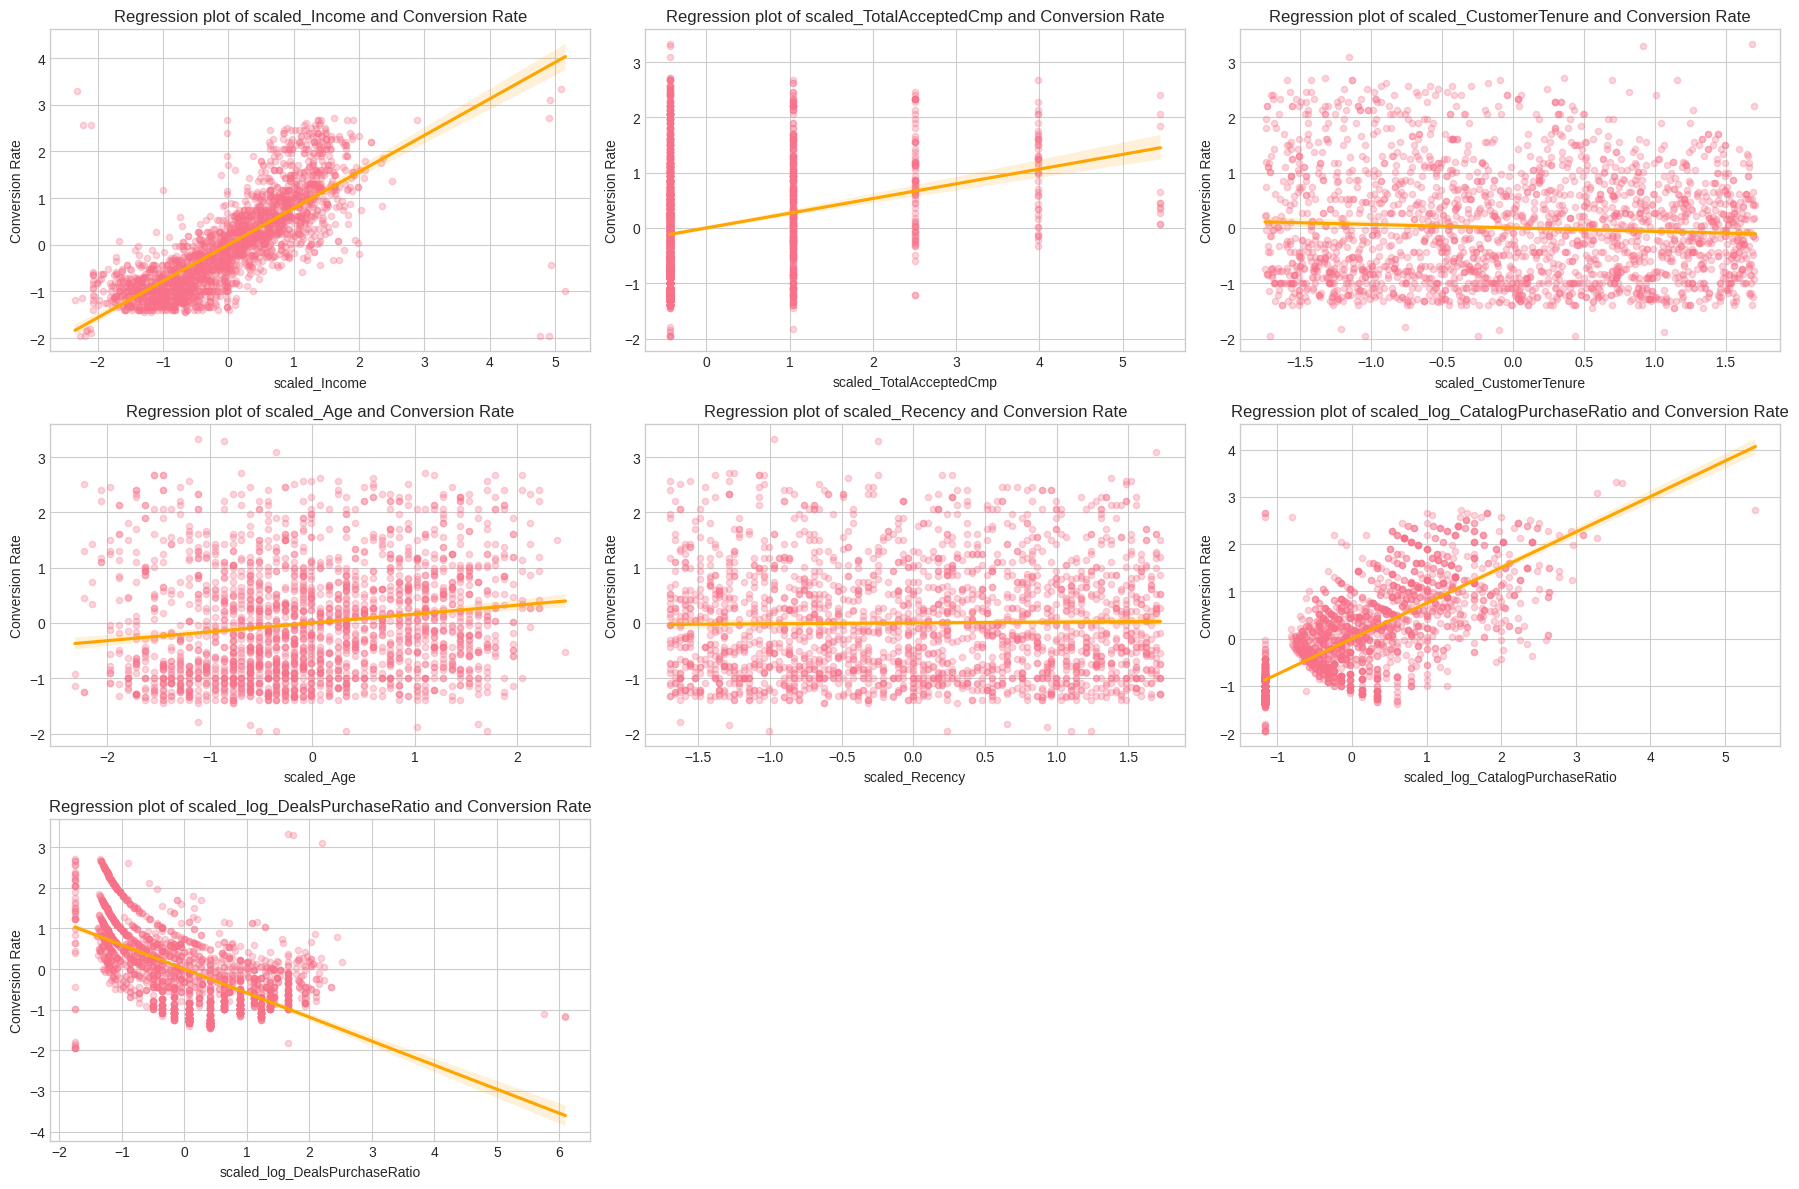

In [46]:
variables = ['scaled_Income', 'scaled_TotalAcceptedCmp', 'scaled_CustomerTenure', 'scaled_Age', 'scaled_Recency', 'scaled_log_CatalogPurchaseRatio', 'scaled_log_DealsPurchaseRatio',]

plt.figure(figsize=(18, 12))  # Larger size to accommodate all plots

for i, var in enumerate(variables):
    # Adjusted to a 4x2 grid to accommodate 7 plots, or 3x3 if you prefer fewer rows.
    # Using 3 rows and 3 columns (total 9 plots) will ensure all 7 variables fit.
    plt.subplot(3, 3, i + 1)  # 3 rows and 3 columns layout
    if var == 'Income' or var == 'Age':
        sns.regplot(x=df_clean[var], y=df_clean['CVR'],
                    scatter_kws={'s': 20, 'alpha': 0.3},
                    line_kws={'color': 'orange'})
    else:
        sns.regplot(x=df_scaled[var], y=df_scaled['scaled_log_CVR'],
                    scatter_kws={'s': 20, 'alpha': 0.3},
                    line_kws={'color': 'orange'})
    plt.title(f'Regression plot of {var} and Conversion Rate')
    plt.xlabel(var)
    plt.ylabel('Conversion Rate')

# Hide unused subplots if any (e.g., if using 3x3 grid for 7 plots, hide the last 2)
# len(variables) is 7, so (i+1) will go up to 7.
# If using 3x3 (9 plots total), we need to hide the 8th and 9th.
# If using 4x2 (8 plots total), we need to hide the 8th.
# Let's stick to 3x3 for simplicity to fit 7 plots.
num_subplots_created = len(variables)
total_grid_positions = 3 * 3
for j in range(num_subplots_created, total_grid_positions):
    plt.subplot(3, 3, j + 1).axis('off')

plt.tight_layout()
plt.show()

The regression plots show a clear positive relationship between scaled income and conversion rate, indicating that customers with higher income tend to convert better when they visit the site. Similarly, the total number of accepted campaigns (scaled_TotalAcceptedCmp) also correlates positively with conversion rate, although the data points reflect discrete counts rather than a continuous gradient.

In contrast, age and recency show very little impact on conversion behavior. While age exhibits a slight positive trend, it has high variability throughout, suggesting it is not a strong predictor of conversion. Recency—the time since last engagement—shows nearly no correlation with conversion, indicating that how recently a customer interacted does not significantly influence their likelihood to convert.

Finally, the plot of the log-transformed catalog purchase ratio against conversion rate shows a strong positive linear relationship, reinforcing that customers who prefer catalog purchases tend to have higher conversion rates. Meanwhile, the deals purchase ratio shows a negative association with conversion rate, implying that customers buying mostly during promotions may convert less efficiently overall.

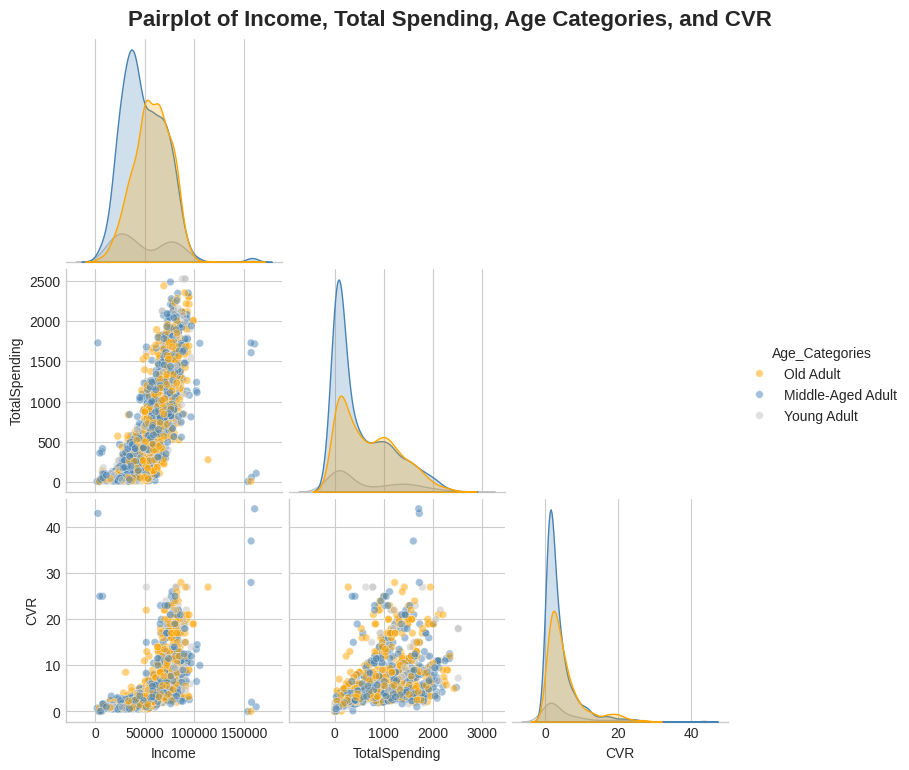

In [47]:
# Create Age_Categories based on Age
df_clean['Age_Categories'] = np.where(df_clean['Age'] < 40, 'Young Adult',
                              np.where(df_clean['Age'] < 60, 'Middle-Aged Adult', 'Old Adult'))

# Now plot pairplot with hue by Age_Categories
sns.pairplot(df_clean[['Income', 'TotalSpending', 'Age_Categories', 'CVR']],
             hue='Age_Categories',
             palette=['orange', 'steelblue', 'silver'],
             corner=True,
             plot_kws={'alpha': 0.5, 's': 30})

plt.suptitle('Pairplot of Income, Total Spending, Age Categories, and CVR', y=1.02, fontsize=16, weight='bold')
plt.show()

This pairplot visualizes the distributions and relationships among Income, Total Spending, Conversion Rate (CVR), and Age Categories grouped into Young Adult, Middle-Aged Adult, and Old Adult.

* The diagonal plots show the distribution of each variable for the different age groups. For example, Young Adults (light gray) tend to have lower income and total spending compared to Middle-Aged (blue) and Old Adults (orange).
* Scatterplots below the diagonal reveal positive relationships between Income and Total Spending, and between Income and CVR across all age groups, indicating that customers with higher income tend to spend more and convert better.
* The relationship between Total Spending and CVR is also positively correlated but with more variability.
* Across all scatterplots, data points from different age groups overlap but Younger adults cluster more tightly at lower incomes and spending levels, while Middle-Aged and Old Adults spread wider with higher values.

This visualization highlights that age categories differ in purchasing power and conversion behavior.

### 2.4 Feature Distribution by Response

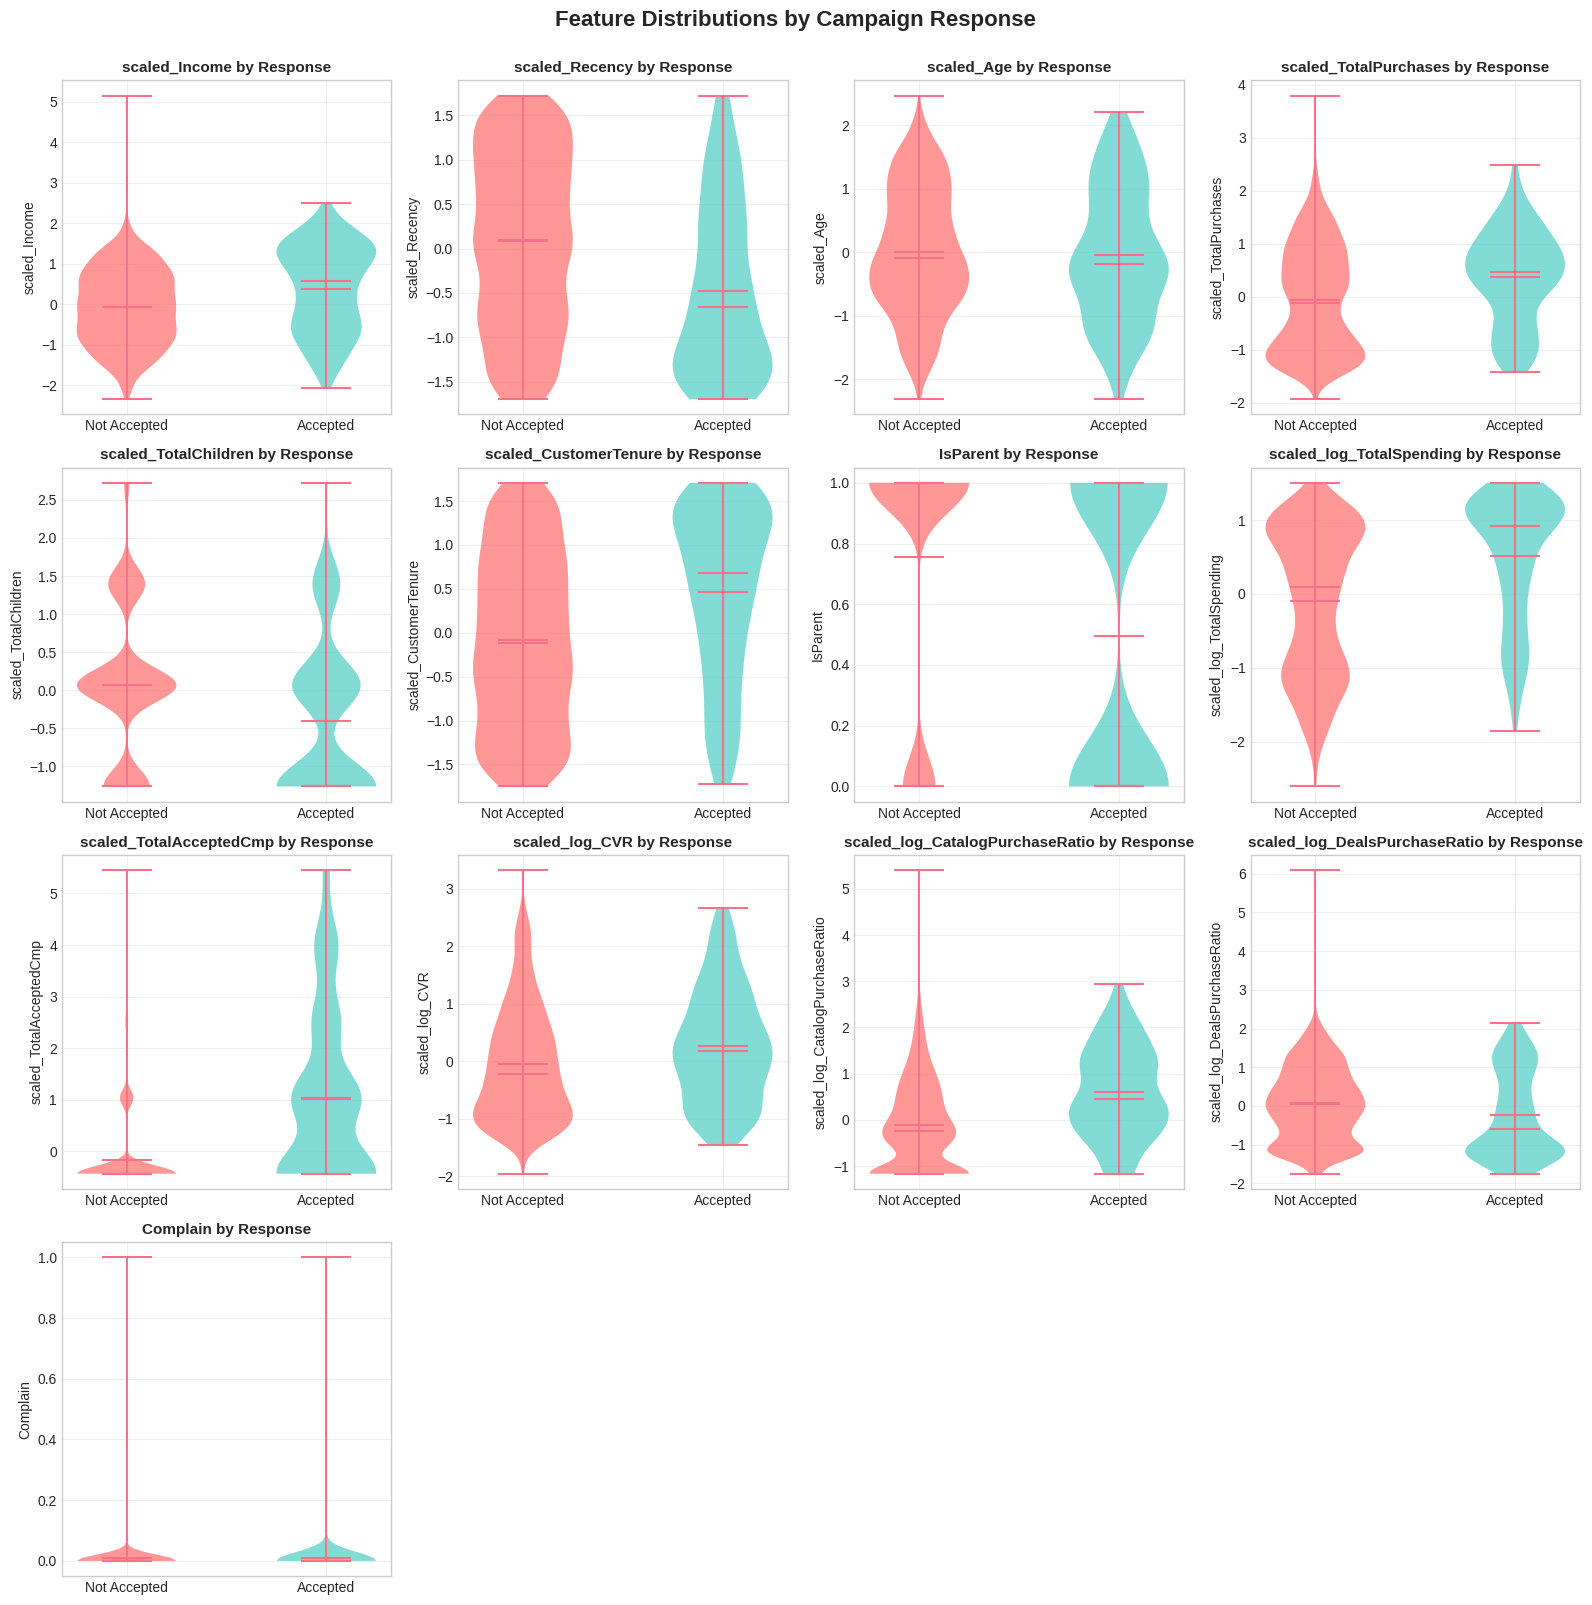


Insights:
   - Higher income customers tend to accept campaigns more often
   - Customers with higher total spending are more likely to respond
   - Previous campaign acceptance strongly predicts future response


In [48]:
# FEATURE COMPARISON BY RESPONSE

key_features_comparison = [
    'scaled_Income', 'scaled_Recency', 'scaled_Age', 'scaled_TotalPurchases',
    'scaled_TotalChildren', 'scaled_CustomerTenure',
    'IsParent', 'scaled_log_TotalSpending',
    'scaled_TotalAcceptedCmp', 'scaled_log_CVR',
    'scaled_log_CatalogPurchaseRatio', 'scaled_log_DealsPurchaseRatio',
    'Complain'
]
n_features = len(key_features_comparison)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(key_features_comparison):
    # Separate data by response
    not_accepted = df_scaled[df_scaled['Response'] == 0][col]
    accepted = df_scaled[df_scaled['Response'] == 1][col]

    # Create violin plot
    parts = axes[idx].violinplot([not_accepted, accepted], positions=[0, 1],
                                showmeans=True, showmedians=True)

    # Color the violin plots
    colors = ['#ff6b6b', '#4ecdc4']
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)

    axes[idx].set_xticks([0, 1])
    axes[idx].set_xticklabels(['Not Accepted', 'Accepted'])
    axes[idx].set_title(f'{col} by Response', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(True, alpha=0.3)

# Hide unused subplots if any
for j in range(n_features, len(axes)):
    axes[j].axis('off')

plt.suptitle('Feature Distributions by Campaign Response', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('feature_by_response.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInsights:")
print("   - Higher income customers tend to accept campaigns more often")
print("   - Customers with higher total spending are more likely to respond")
print("   - Previous campaign acceptance strongly predicts future response")

"""
### Violin Plot Analysis: Feature Distributions by Campaign Response

The violin plots reveal strong differentiators between campaign responders and non-responders. Income, total spending, and spending per purchase are notably higher among responders, showing that wealthier customers who spend more per transaction are more receptive to campaigns. Total accepted campaigns shows clear separation, confirming that customers with prior acceptance history respond more often. Customer tenure and conversion rate are also elevated for responders, indicating loyal customers with better conversion efficiency engage more with campaigns. Recency is lower among responders (more recent activity), and total purchases are higher, emphasizing that active customers convert better.

Moderate differentiators include parental status and total children, which show slight distributional differences but are not primary drivers. Features like complaints and age display nearly identical distributions between groups, indicating minimal predictive value. Overall, campaign responsiveness is driven primarily by financial engagement and customer loyalty rather than demographics or complaint history, suggesting marketing efforts should target high-value and loyal customer segments.


### 2.5 Statistical Tests for Feature Significance

In [49]:
# Mann-Whitney U Test for key numerical features (non-parametric)

key_features_comparison = [
    'scaled_Income', 'scaled_Recency', 'scaled_Age', 'scaled_TotalPurchases',
    'scaled_TotalChildren', 'scaled_CustomerTenure',
    'scaled_log_TotalSpending',
    'scaled_TotalAcceptedCmp', 'scaled_log_CVR',
    'scaled_log_CatalogPurchaseRatio', 'scaled_log_DealsPurchaseRatio'
]
significance_results = []

# Perform tests and collect results without printing each line
for feature in key_features_comparison:
    if feature in df_scaled.columns:
        group_0 = df_scaled[df_scaled['Response'] == 0][feature]
        group_1 = df_scaled[df_scaled['Response'] == 1][feature]

        stat, p_value = mannwhitneyu(group_0, group_1, alternative='two-sided')

        significance_results.append({
            'Feature': feature,
            'U-Statistic': stat,
            'P-Value': p_value,
            'Significant': p_value < 0.05
        })

# Convert results to DataFrame and format output
significance_df = pd.DataFrame(significance_results)
significance_df = significance_df.sort_values('P-Value')

# Format "Significant?" column as Yes/No
significance_df['Significant?'] = significance_df['Significant'].apply(lambda x: 'Yes' if x else 'No')

# Select and rename columns for readability
summary_table = significance_df.rename(columns={
    'U-Statistic': 'U-Statistic',
    'P-Value': 'P-Value',
    'Significant?': 'Significant?'
})[['Feature', 'U-Statistic', 'P-Value', 'Significant?']]

print("STATISTICAL SIGNIFICANCE TESTS (Mann-Whitney U Test)")
print("="*65)
print(summary_table.to_string(index=False))


STATISTICAL SIGNIFICANCE TESTS (Mann-Whitney U Test)
                        Feature  U-Statistic      P-Value Significant?
        scaled_TotalAcceptedCmp     176739.0 2.961550e-75          Yes
scaled_log_CatalogPurchaseRatio     191982.5 2.227294e-31          Yes
       scaled_log_TotalSpending     194840.5 1.578260e-29          Yes
                 scaled_Recency     419728.0 6.464432e-21          Yes
          scaled_CustomerTenure     217589.5 3.809866e-20          Yes
           scaled_TotalChildren     400951.0 7.459937e-17          Yes
                  scaled_Income     234919.0 2.942333e-14          Yes
          scaled_TotalPurchases     235815.5 5.236500e-14          Yes
                 scaled_log_CVR     256517.5 1.944154e-08          Yes
  scaled_log_DealsPurchaseRatio     375236.0 1.176436e-07          Yes
                     scaled_Age     327896.0 3.455430e-01           No


We use the Mann-Whitney U test to check if feature distributions differ between campaign responders and non-responders. This
test works well for comparing two groups without assuming the data follows a normal distribution. Results show 10 out of 11
features have significant differences (p < 0.05), meaning there are clear patterns separating the two groups.

The strongest differences appear in scaled_TotalAcceptedCmp (p = 2.96e-75), scaled_log_CatalogPurchaseRatio (p = 2.23e-31),
and scaled_log_TotalSpending (p = 1.58e-29). Past campaign engagement, catalog shopping, and spending behavior are the best
separators. Features like scaled_Recency, scaled_CustomerTenure, and scaled_Income also show significant differences. Only
scaled_Age (p = 0.346) isn't significant, confirming age doesn't strongly predict campaign response.

For clustering, we want features that reflect customers' natural characteristics rather than their response behavior. We include
scaled_Income, scaled_Recency, scaled_Age, scaled_TotalPurchases, scaled_TotalChildren, scaled_CustomerTenure, IsParent,
scaled_log_TotalSpending, scaled_log_CVR, scaled_log_CatalogPurchaseRatio, and scaled_log_DealsPurchaseRatio. We exclude
scaled_TotalAcceptedCmp and Response because they're too tied to campaign outcomes and would just make clusters mirror the
response pattern

### 2.6 Customer Segmentation with K-Means Clustering

**PCA Dimensionality reduction**

We set a random seed for consistency and selected key scaled features from the data. Then, we applied PCA to reduce dimensionality by capturing the most variance in fewer components. We looked at how much variance each component explains individually and cumulatively.

In [50]:
# STEP 1 : First Setup
SEED= 42
np.random.seed(SEED)

# List your significant scaled features here
significant_features = [
    'scaled_Income', 'scaled_Recency', 'scaled_Age', 'scaled_TotalPurchases',
    'scaled_TotalChildren', 'scaled_CustomerTenure',
    'scaled_log_TotalSpending',
    'scaled_log_CVR',
    'scaled_log_CatalogPurchaseRatio', 'scaled_log_DealsPurchaseRatio'
]

# Prepare data
X = df_scaled[significant_features].copy()

# Fit PCA
pca = PCA(random_state=SEED).fit(X)

# Individual and cumulative explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

We created two plots to understand how much information each principal component captures:

A bar chart shows the variance percentage explained by each PC individually. The line plot displays cumulative variance, showing how total information accumulates as more PCs are added. Reference lines at 70%, 80%, and 90% help identify how many components are needed to reach these thresholds.

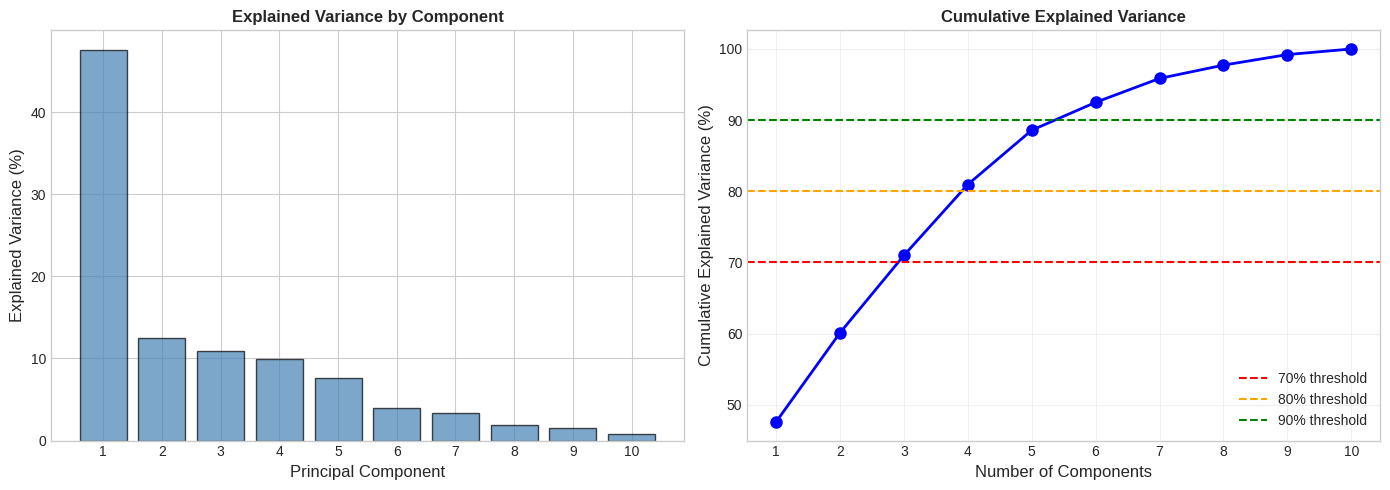


PCA EXPLAINED VARIANCE SUMMARY
Component    Variance %      Cumulative %   
------------------------------------------
PC1          47.60           47.60          
PC2          12.52           60.12          
PC3          10.87           70.99          
PC4          9.97            80.96          
PC5          7.62            88.58          
PC6          3.92            92.50          
PC7          3.36            95.86          
PC8          1.87            97.73          
PC9          1.49            99.21          
PC10         0.79            100.00         

 Components needed for:
   - 70% variance: 3 components
   - 80% variance: 4 components
   - 90% variance: 6 components

 For 2D VISUALIZATION: Using 2 components explains 60.1% of variance
   This is sufficient for visualization purposes.


In [51]:
# STEP 2 : PCA Visualization
# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Individual explained variance (FIXED: pca_full → pca)
axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1),
            pca.explained_variance_ratio_ * 100,
            color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance (%)', fontsize=12)
axes[0].set_title('Explained Variance by Component', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(1, len(pca.explained_variance_ratio_) + 1))

# Plot 2: Cumulative explained variance
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100,
             'bo-', linewidth=2, markersize=8)
axes[1].axhline(y=70, color='red', linestyle='--', label='70% threshold')
axes[1].axhline(y=80, color='orange', linestyle='--', label='80% threshold')
axes[1].axhline(y=90, color='green', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance (%)', fontsize=12)
axes[1].set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(1, len(cumulative_variance) + 1))
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_variance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print variance summary (FIXED: pca_full → pca)
print("\n" + "="*60)
print("PCA EXPLAINED VARIANCE SUMMARY")
print("="*60)
print(f"{'Component':<12} {'Variance %':<15} {'Cumulative %':<15}")
print("-"*42)
for i, (var, cum_var) in enumerate(zip(pca.explained_variance_ratio_, cumulative_variance), 1):
    print(f"PC{i:<10} {var*100:<15.2f} {cum_var*100:<15.2f}")

# Determine n_components for different thresholds
n_70 = np.argmax(cumulative_variance >= 0.70) + 1
n_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(f"\n Components needed for:")
print(f"   - 70% variance: {n_70} components")
print(f"   - 80% variance: {n_80} components")
print(f"   - 90% variance: {n_90} components")

print(f"\n For 2D VISUALIZATION: Using 2 components explains {cumulative_variance[1]*100:.1f}% of variance")
print(f"   This is {'sufficient' if cumulative_variance[1] >= 0.5 else 'limited but acceptable'} for visualization purposes.")

### PCA Variance Explained Analysis

PC1 captures 47.60% of variance, showing the dataset's primary variability concentrates in one main dimension. PC2,PC3,PC4
add 12.52%, 10.87%, and 9.97% respectively, bringing cumulative variance to 80.96%, this meets the standard 80% threshold for
dimensionality reduction, meaning 4 components retain most of the original information while reducing from 11 features to
4.



In [52]:
# STEP 3: DETERMINE NUMBER OF PC & APPLY PCA

# Apply PCA
pca = PCA(n_components=4, random_state=SEED)
X_pca = pca.fit_transform(X)

print(f"\nShape before PCA  : {X.shape}")
print(f"Shape after PCA  : {X_pca.shape}")


Shape before PCA  : (2236, 10)
Shape after PCA  : (2236, 4)


In [53]:
# Create DataFrame for loading matrix
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=significant_features
)

print("PCA LOADINGS MATRIX")
print("="*80)
print(loadings.round(3))

PCA LOADINGS MATRIX
                                   PC1    PC2    PC3    PC4
scaled_Income                    0.398  0.049 -0.152 -0.015
scaled_Recency                   0.008  0.132  0.029  0.989
scaled_Age                       0.089  0.463 -0.575 -0.031
scaled_TotalPurchases            0.371  0.342  0.088 -0.081
scaled_TotalChildren            -0.270  0.513 -0.236 -0.054
scaled_CustomerTenure            0.033  0.446  0.748 -0.066
scaled_log_TotalSpending         0.425  0.180  0.093 -0.037
scaled_log_CVR                   0.417  0.000 -0.110 -0.000
scaled_log_CatalogPurchaseRatio  0.388 -0.020  0.016  0.036
scaled_log_DealsPurchaseRatio   -0.341  0.392  0.028 -0.060


We performed elbow and silhouette analysis to determine the optimal number of clusters for customer segmentation.

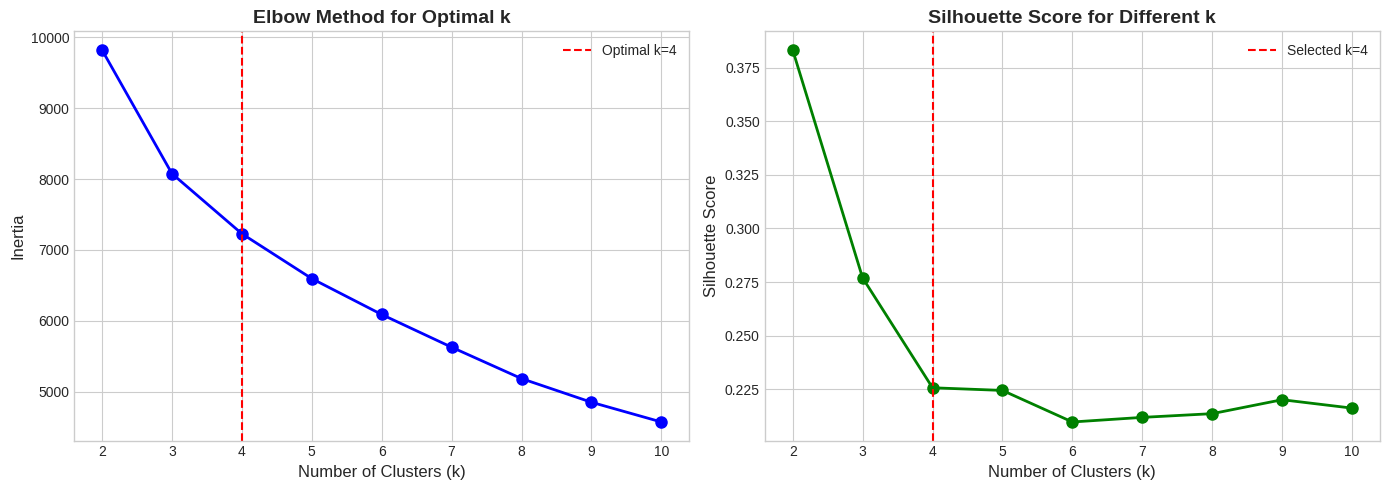

In [54]:
# Find the optimal k value using inertia parameter
# Initialize lists with correct names
inertias = []
silhouette_scores = []

K_range = range(2,11)

# Fit model
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    kmeans.fit(X_pca)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, kmeans.labels_))

# Plot Elbow curve and Silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia', fontsize=12)
axes[0].set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
axes[0].axvline(x=4, color='red', linestyle='--', label='Optimal k=4')
axes[0].legend()

# Silhouette score plot
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score for Different k', fontsize=14, fontweight='bold')
axes[1].axvline(x=4, color='red', linestyle='--', label='Selected k=4')
axes[1].legend()

plt.tight_layout()
plt.savefig('clustering_optimal_k.png', dpi=150, bbox_inches='tight')
plt.show()

The elbow method examines inertia (within-cluster sum of squares) across different k values, while silhouette score measures how well each point fits within its cluster and how separated clusters are from each other. By combining both metrics, we can identify where adding more clusters provides diminishing returns.

In [55]:
print("\nElbow & Silhouette Comparison:")
print("-"*45)
print(f"{'k':<5} {'Inertia':<15} {'Silhouette':<15}")
print("-"*45)

best_k = None
best_silhouette = -1  # Initialize to lowest possible silhouette
prev_inertia = None

for k, iner, sil in zip(K_range, inertias, silhouette_scores):
    print(f"{k:<5} {iner:<15.2f} {sil:<15.4f}")

    # Update best_k if silhouette is higher or equal but inertia decreased significantly
    if sil > best_silhouette:
        best_silhouette = sil
        best_k = k

    # Optional: check inertia "elbow" by a relative change threshold
    if prev_inertia is not None:
        inertia_drop = (prev_inertia - iner) / prev_inertia
        # If inertia drop is small (e.g., <10%) and silhouette is near max, consider previous k best
        # This logic can help detect elbow point
    prev_inertia = iner

print("-"*45)
print(f"\nRecommended best number of clusters: k = {best_k}")


Elbow & Silhouette Comparison:
---------------------------------------------
k     Inertia         Silhouette     
---------------------------------------------
2     9819.60         0.3833         
3     8076.81         0.2770         
4     7229.68         0.2257         
5     6597.02         0.2245         
6     6090.99         0.2098         
7     5630.01         0.2119         
8     5187.74         0.2136         
9     4854.16         0.2201         
10    4576.16         0.2162         
---------------------------------------------

Recommended best number of clusters: k = 2


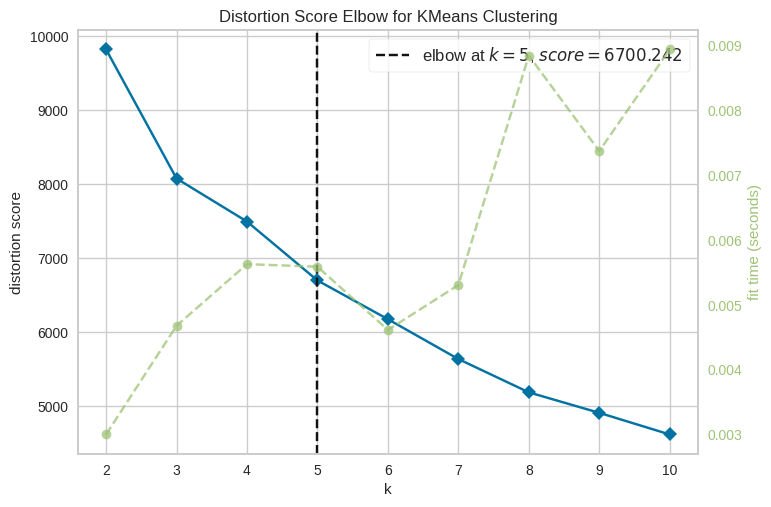

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [56]:
# visualisasi dengan parameter distortion
from yellowbrick.cluster import KElbowVisualizer

# fit model
model = KMeans(random_state=SEED)
visualizer = KElbowVisualizer(model, metric='distortion', timings=True, locate_elbow=True)
visualizer.fit(X_pca)
visualizer.show()

#### Results and Interpretation

The elbow method plot shows a noticeable inflection at k=4, where inertia is 7229.68. The decrease in inertia from k=2 to k=4 is substantial, reflecting significant improvements in cluster compactness. Silhouette analysis shows that while k=2 achieves the highest silhouette score (0.3833), this low cluster number risks under-segmenting the data. At k=4, the silhouette score drops to 0.2257, but accompanies the elbow marked reduction in inertia signaling a better balance between within-cluster tightness and separation across clusters. Later increases in k provide diminishing returns indicated by modest drops in inertia and inconsistent silhouette scores.

#### Conclusion

During initial testing, we evaluated multiple configurations. The elbow and silhouette methods and distortion score suggested k=4. However, when we applied these configurations with 4 principal components, the resulting clusters showed significant overlap and lack of clear separation between cluster boundaries and centroids.


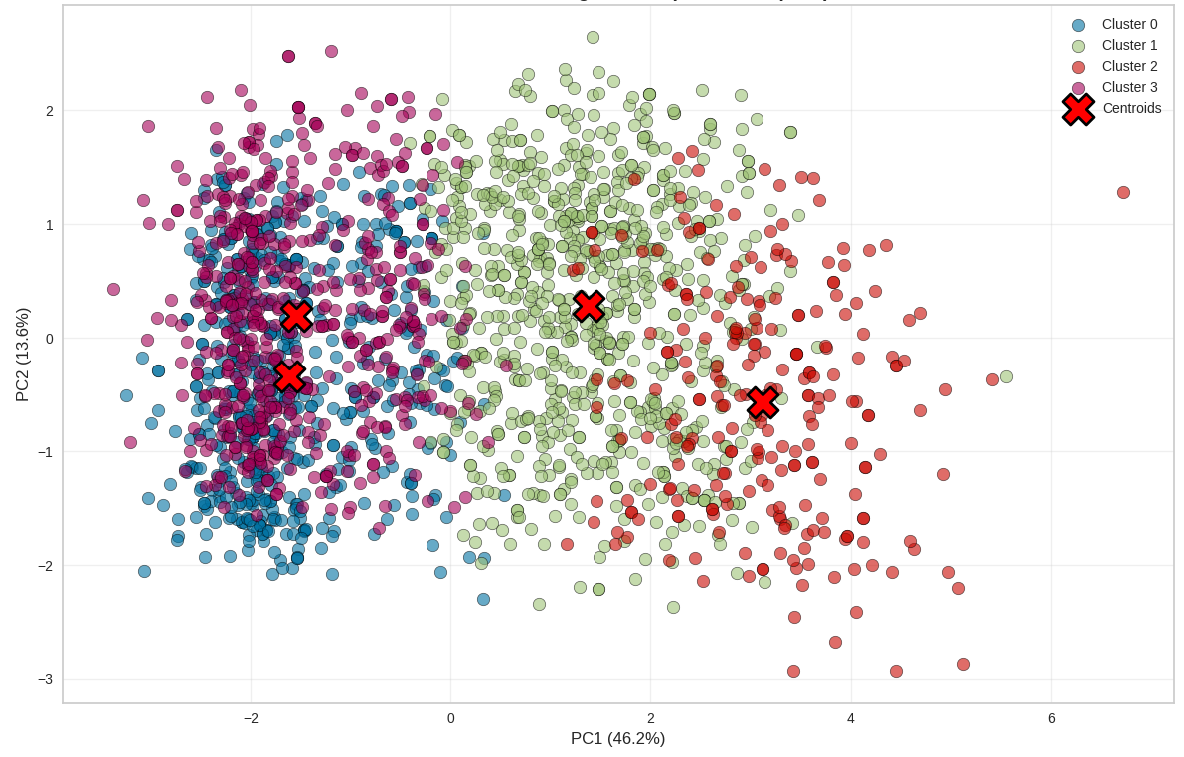


We reduced dimensionality to 4 principal components and selected k=3 clusters as the optimal configuration. While k=2 had a higher silhouette score (0.38), it underclustered the data. K=4 showed better compactness but introduced cluster overlap. K=3 strikes the best balance: the elbow method shows meaningful inertia reduction to 8,076.81, the silhouette score of 0.28 is reasonable for complex customer data, and the three clusters provide clear separation with minimal overlap.

In [57]:
# APPLY K-MEANS CLUSTERING WITH K=3

# Fit K-Means with optimal k
kmeans_final = KMeans(n_clusters=3, random_state=SEED, n_init=10)
df_scaled['Cluster'] = kmeans_final.fit_predict(X_pca)

print("\n Cluster Distribution:")
print(df_scaled['Cluster'].value_counts().sort_index())

print("\n Final Inertia:")
print(kmeans_final.inertia_)      # Total inertia
print("\n Cluster Center:")
print(kmeans_final.cluster_centers_)


 Cluster Distribution:
Cluster
0    680
1    637
2    919
Name: count, dtype: int64

 Final Inertia:
8076.811374810766

 Cluster Center:
[[ 0.4194323   0.87684622  0.06512522 -0.16969657]
 [ 2.71555501 -0.45607674 -0.04768299  0.07242529]
 [-2.19262514 -0.33268177 -0.0151372   0.07536318]]


In [58]:
# CLUSTER PROFILING

# Calculate cluster statistics
cluster_profile = df_scaled.groupby('Cluster')[significant_features + ['Response']].mean()

print("\n Cluster Profiles (Mean Values):")
print(cluster_profile.round(2))

# Response rate by cluster
print("\n Response Rate by Cluster:")
response_by_cluster = df_scaled.groupby('Cluster')['Response'].agg(['mean', 'count'])
response_by_cluster.columns = ['Response Rate', 'Count']
response_by_cluster['Response Rate'] = (response_by_cluster['Response Rate'] * 100).round(2)
print(response_by_cluster)


 Cluster Profiles (Mean Values):
         scaled_Income  scaled_Recency  scaled_Age  scaled_TotalPurchases  \
Cluster                                                                     
0                 0.20           -0.03        0.36                   0.58   
1                 1.07            0.03        0.06                   0.79   
2                -0.89            0.01       -0.31                  -0.98   

         scaled_TotalChildren  scaled_CustomerTenure  \
Cluster                                                
0                        0.34                   0.39   
1                       -0.95                  -0.13   
2                        0.41                  -0.20   

         scaled_log_TotalSpending  scaled_log_CVR  \
Cluster                                             
0                            0.48            0.10   
1                            1.01            1.19   
2                           -1.05           -0.90   

         scaled_log_CatalogPurcha

We applied K-means clustering with k=3 to segment customers. All variables were standardized before clustering to ensure fair comparison. The model converged with an inertia of 8,076.81 and a silhouette score of 0.28.

**Cluster Characteristics**

**Cluster 1 (n=637, 28%)**: High-value customers with the highest income (1.07) and spending (1.01). They have fewer children (-0.95), enabling greater purchasing power. This segment shows exceptional conversion rates (1.19) and strongly prefers catalog shopping (1.13) over deals (-1.09). Response rate is 25.43%—the highest across all clusters. Slightly below-average tenure (-0.13) suggests these may be newer but highly engaged customers.

**Cluster 0 (n=680, 30%)**: Middle-tier customers with moderate income (0.20) and above-average spending (0.48). They are slightly older (0.36) with more children (0.34) and demonstrate good loyalty (0.39 tenure). Purchase behavior (0.58) is solid, with balanced deal usage (0.18). Response rate is 13.38%.

**Cluster 2 (n=919, 41%**): Low-engagement customers with below-average income (-0.89) and spending (-1.05). They have more children (0.41), constraining spending capacity. This group shows the lowest purchase frequency (-0.98), conversion rates (-0.90), and catalog preference (-0.76), but relies more on promotional deals (0.62). Response rate is just 8.81%.

**Implications**

Cluster 1 is the most valuable segment—they respond nearly three times better than Cluster 0 and triple Cluster 2's rate. Despite comprising only 28% of customers, they generate the highest engagement and should be prioritized for retention and premium campaigns. Cluster 0 represents growth potential with targeted upselling strategies. Cluster 2 comprises 41% of customers but generates minimal engagement, requiring careful cost-benefit evaluation of marketing investment for this segment.

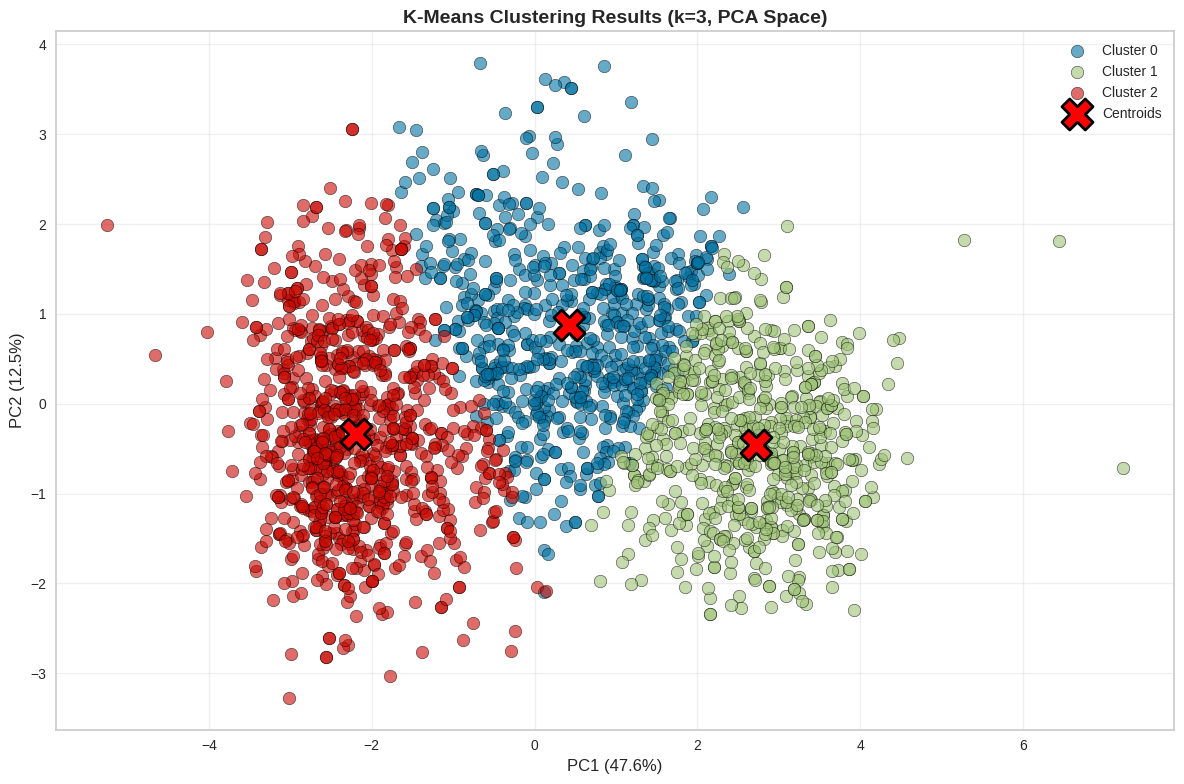

In [59]:
# VISUALIZE CLUSTERS WITH CENTROIDS (USING kmeans_final)
fig, ax = plt.subplots(figsize=(12, 8))

# Plot data points
for cluster in range(kmeans_final.n_clusters):
    mask = kmeans_final.labels_ == cluster
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=f'Cluster {cluster}',
               s=80, alpha=0.6, edgecolors='black', linewidth=0.5)

# Plot centroids
centroids_pca = kmeans_final.cluster_centers_
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c='red', marker='X', s=500,
           edgecolors='black', linewidth=2,
           label='Centroids', zorder=5)

# Annotate centroids
for i, centroid in enumerate(centroids_pca):
    ax.annotate(f'C{i}', (centroid[0], centroid[1]),
                fontsize=14, fontweight='bold',
                ha='center', va='center', color='white')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('K-Means Clustering Results (k=3, PCA Space)',
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cluster_segmentation_k4.png', dpi=150, bbox_inches='tight')
plt.show()

The 2D plot shows three well-separated clusters. Cluster 2 (red) sits on the left—low-income, low-engagement customers. Cluster 0 (blue) occupies the center, representing middle-tier customers. Cluster 1 (green) is on the right, capturing high-value customers. This visualization only shows two dimensions, but we actually used 4 principal components for clustering because they capture 81% of the variance and provide a cleaner input for predictive modeling. PC1 (47.6%) mainly reflects income and spending, while PC2 (12.5%) captures engagement patterns. The other two components (PC3: 10.87%, PC4: 9.97%) add nuance that's not visible here but helps refine the cluster boundaries. The well-spaced centroids confirm k=3 works well for segmentation.

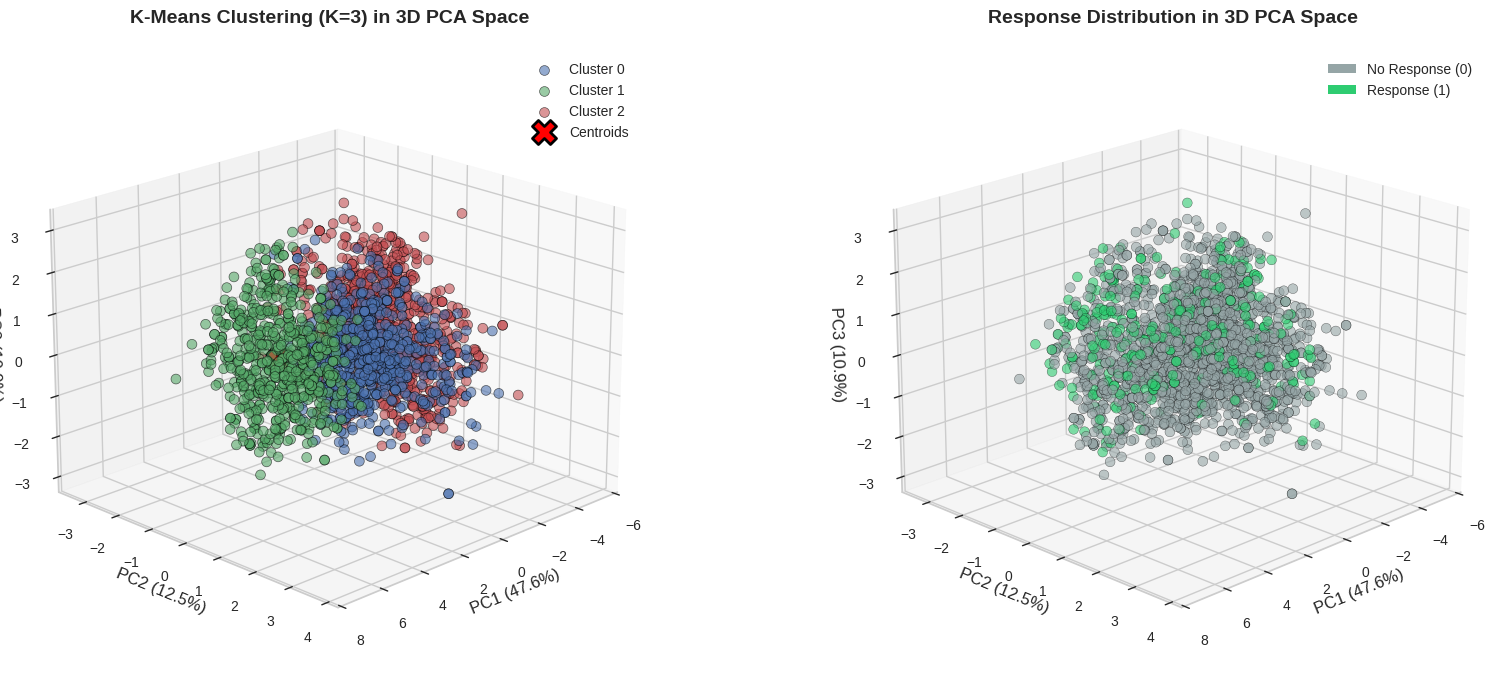


VARIANCE EXPLAINED BY 3 PCs
PC1: 47.60%
PC2: 12.52%
PC3: 10.87%
PC4: 9.97%

Cumulative: 80.96%


In [60]:
# 3D visualization
fig = plt.figure(figsize=(18, 7))

# Plot 1: Clusters in 3D
ax1 = fig.add_subplot(121, projection='3d')

# Define colors for 3 clusters
cluster_colors = [
    '#4C72B0',  # blue (Cluster 0)
    '#55A868',  # green (Cluster 1)
    '#C44E52'   # red (Cluster 2)
]
for cluster in range(3):
    mask = df_scaled['Cluster'] == cluster
    ax1.scatter(X_pca[mask, 0],
                X_pca[mask, 1],
                X_pca[mask, 2],
                c=cluster_colors[cluster],
                label=f'Cluster {cluster}',
                alpha=0.6,
                s=50,
                edgecolors='black',
                linewidth=0.5)

# Plot cluster centers
centers_3d = kmeans_final.cluster_centers_
ax1.scatter(centers_3d[:, 0],
            centers_3d[:, 1],
            centers_3d[:, 2],
            c='red',
            marker='X',
            s=300,
            edgecolors='black',
            linewidth=2,
            label='Centroids',
            zorder=10)

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax1.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)', fontsize=12)
ax1.set_title('K-Means Clustering (K=3) in 3D PCA Space',
              fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='upper right', fontsize=10)
ax1.view_init(elev=20, azim=45)
ax1.grid(True, alpha=0.3)

# Plot 2: Response Distribution in 3D
ax2 = fig.add_subplot(122, projection='3d')

# Color by Response
response_colors = df_scaled['Response'].map({0: '#95a5a6', 1: '#2ecc71'})
scatter2 = ax2.scatter(X_pca[:, 0],
                       X_pca[:, 1],
                       X_pca[:, 2],
                       c=response_colors,
                       alpha=0.6,
                       s=50,
                       edgecolors='black',
                       linewidth=0.3)

ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax2.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)', fontsize=12)
ax2.set_title('Response Distribution in 3D PCA Space',
              fontsize=14, fontweight='bold', pad=20)
ax2.view_init(elev=20, azim=45)
ax2.grid(True, alpha=0.3)

# Custom legend for response
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#95a5a6', label='No Response (0)'),
                   Patch(facecolor='#2ecc71', label='Response (1)')]
ax2.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('clustering_3d_k4.png', dpi=150, bbox_inches='tight')
plt.show()

# ========== VARIANCE EXPLAINED ==========
print("\n" + "="*70)
print("VARIANCE EXPLAINED BY 3 PCs")
print("="*70)
for i, var in enumerate(pca.explained_variance_ratio_, 1):
    print(f"PC{i}: {var*100:.2f}%")
print(f"\nCumulative: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print("="*70)


**K-Means Clustering (K=3) in 3D PCA Space**

The three clusters show clear separation with minimal overlap. Cluster 0 (blue) dominates the center, Cluster 1 (green) spreads across the left, and Cluster 2 (red) occupies the upper-right region of the space. The centroids are well-separated, confirming the model converged properly. The first three components explain 70.99% of total variance—PC1 captures 47.60% (mostly income and spending differences), PC2 adds 12.52% (engagement patterns), and PC3 contributes 10.87% (additional behavioral nuances). Together, these three dimensions give a solid picture of what makes customers different without needing all the original variables.

**Response Distribution in 3D PCA Space**

Campaign responders (green dots) are scattered throughout the entire space rather than clustering in one area. This means customers who look similar demographically and behaviorally don't always respond the same way to campaigns. This shows that customers with similar characteristics don't necessarily respond the same way, meaning segmentation alone can't predict campaign response—predictive models are needed to identify responders within each segment.

The visualizations suggest that a three-cluster solution offers better interpretability and cleaner separation than four clusters. While both models identify distinct customer groups, the K=3 model avoids unnecessary fragmentation visible in the K=4 approach.

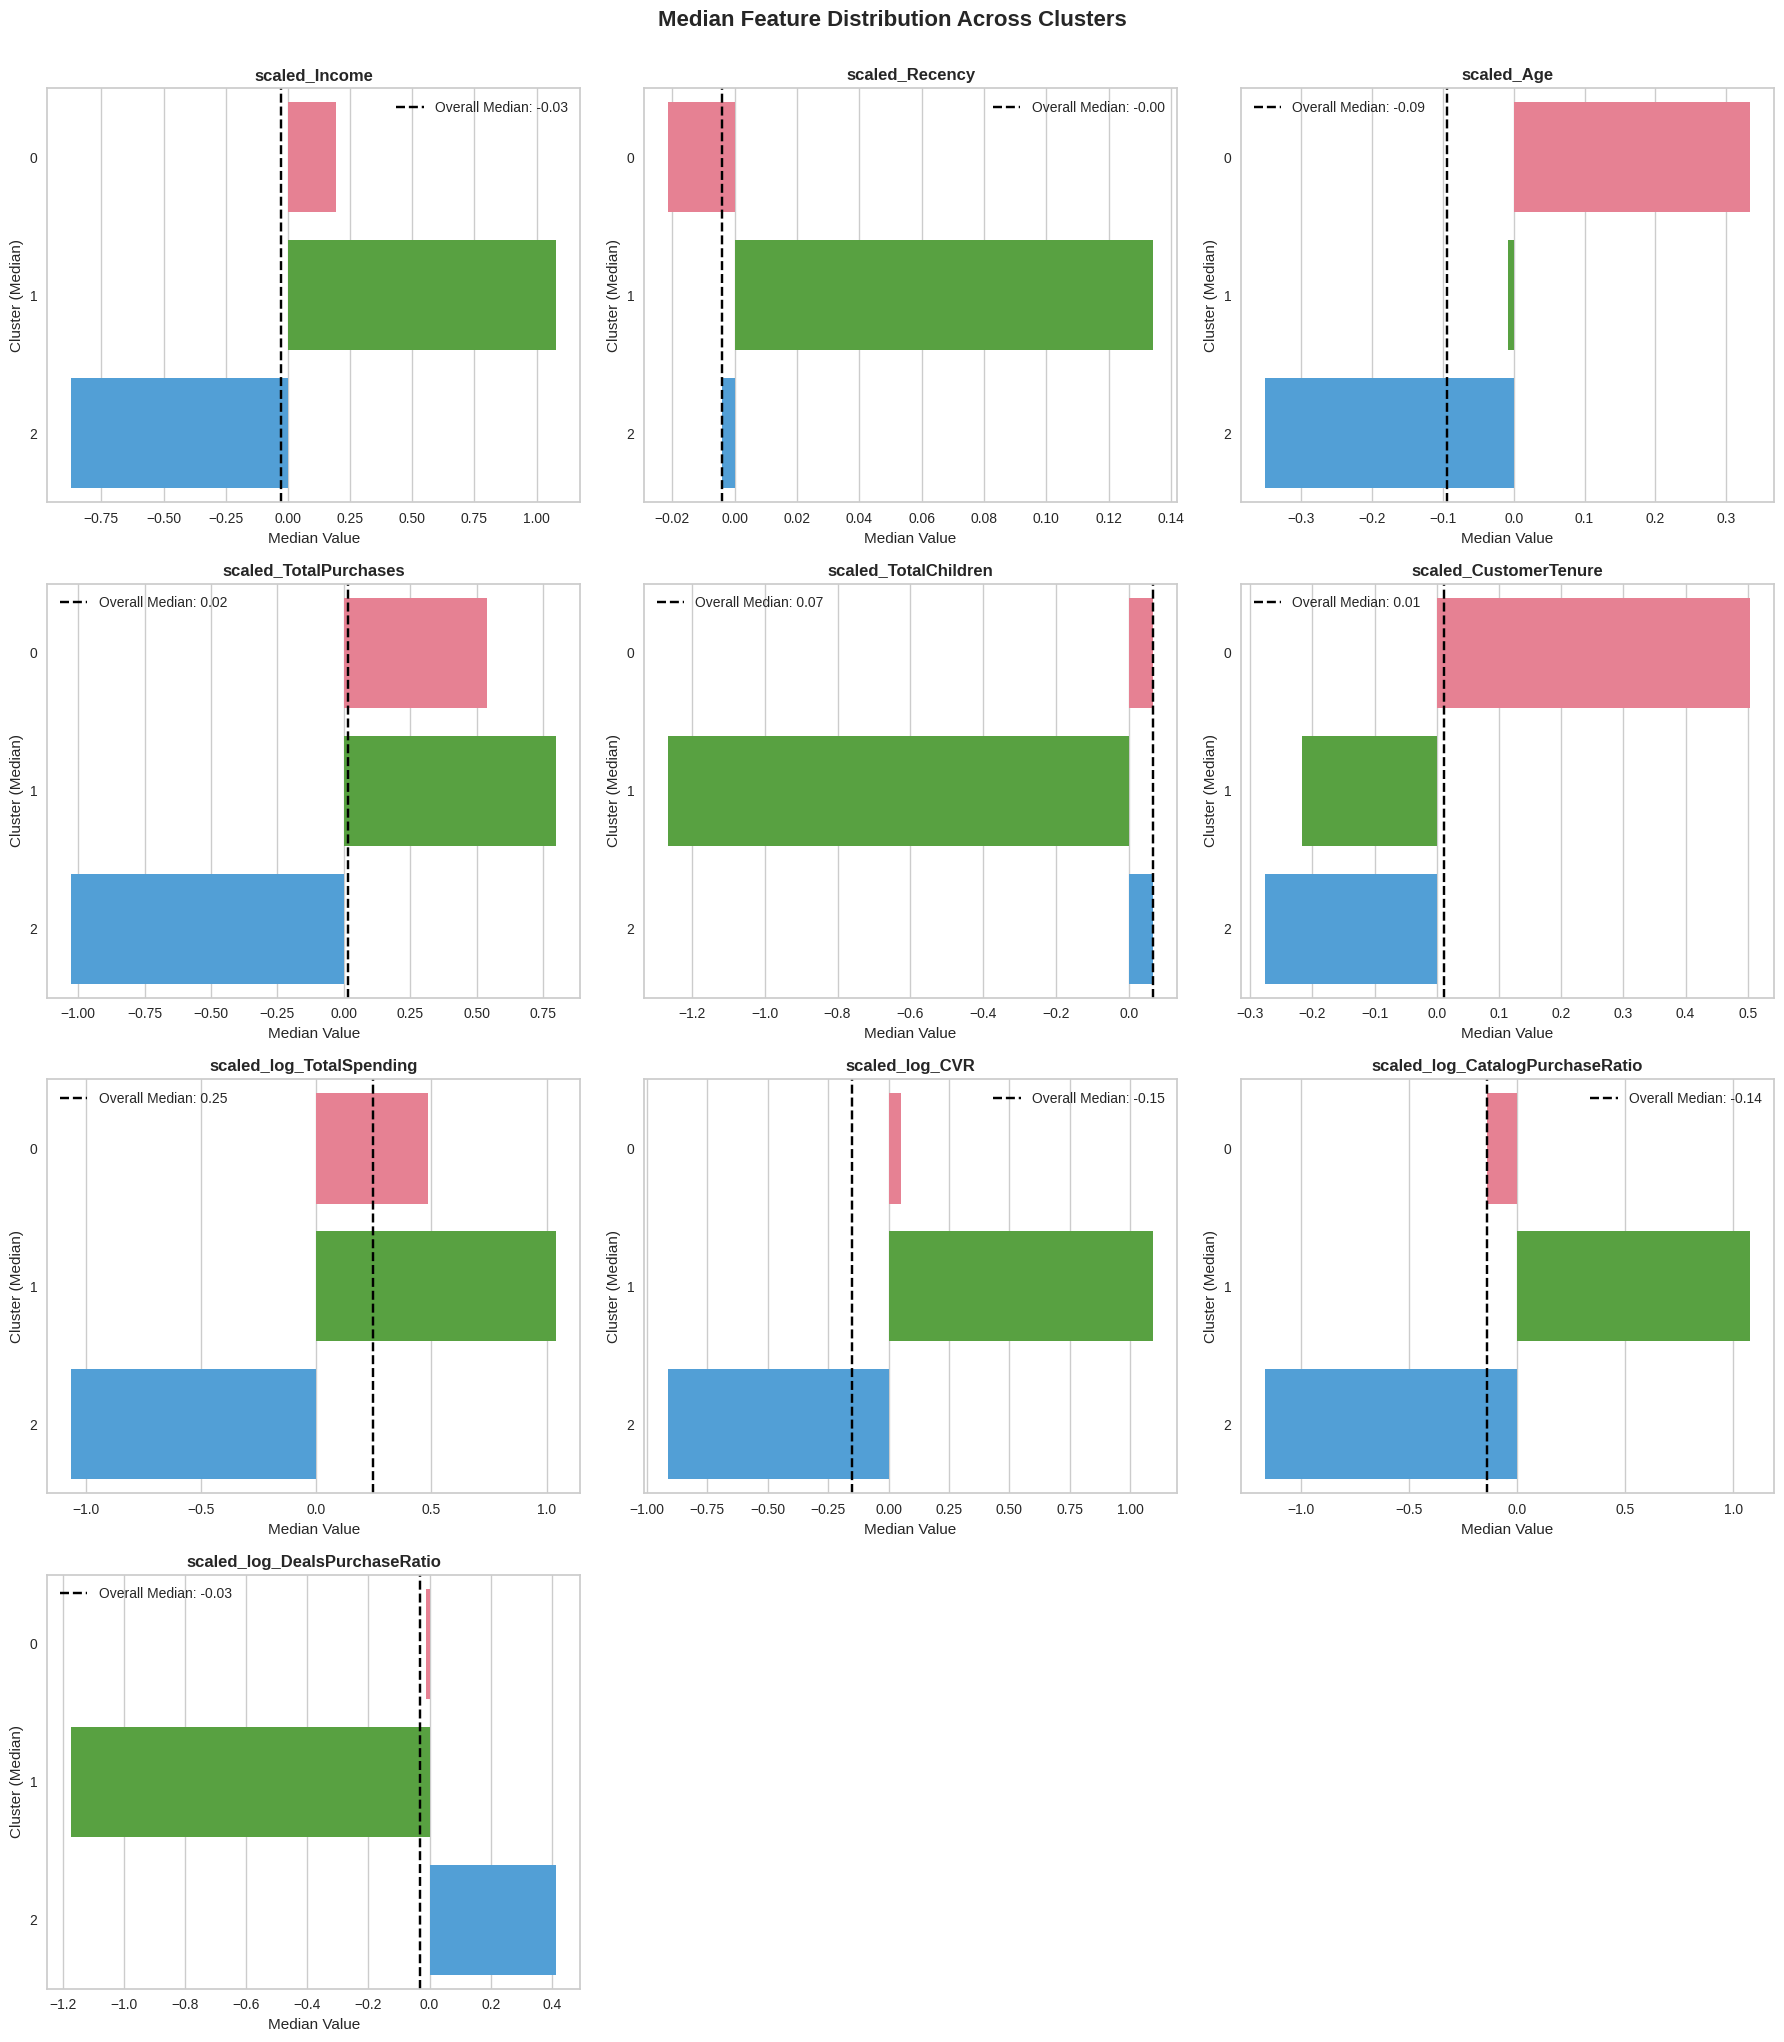

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cluster_distributions(df, features_to_plot, cluster_col='Cluster'):
    """
    Plots the median distribution of specified features grouped by cluster.

    Args:
        df (pd.DataFrame): The DataFrame containing the features and cluster labels.
        features_to_plot (list): A list of column names (scaled features) to plot.
        cluster_col (str): The name of the column containing cluster labels.
    """
    plt.figure(figsize=[18, 20]) # Adjusted figure size for more rows
    color_palette = sns.color_palette('husl', n_colors=len(df[cluster_col].unique()))

    i = 1
    # Calculate number of rows needed based on features_to_plot and 3 columns
    n_rows = (len(features_to_plot) + 2) // 3 # Ceiling division

    for col in features_to_plot:
        ax = plt.subplot(n_rows, 3, i) # Adjusted subplot grid dynamically

        # Overall median of the feature
        overall_median = df[col].median()
        ax.axvline(overall_median, color='black', linestyle='--', label=f'Overall Median: {overall_median:.2f}')

        # Median of the feature grouped by cluster
        g = df.groupby(cluster_col)
        cluster_medians = g[col].median().sort_index()

        # Plot bar chart for cluster medians
        sns.barplot(x=cluster_medians.values, y=cluster_medians.index.astype(str),
                    palette=color_palette, ax=ax, orient='h')

        ax.set_title(col, fontsize=12, fontweight='bold')
        ax.set_xlabel('Median Value')
        ax.set_ylabel(f'{cluster_col} (Median)')
        ax.legend()
        i = i + 1

    plt.tight_layout()
    plt.suptitle('Median Feature Distribution Across Clusters', fontsize=16, fontweight='bold', y=1.02)
    plt.show()

# Define the list of scaled features to plot
# Ensure these scaled features exist in df_scaled
scaled_features_for_plotting = significant_features = [
    'scaled_Income', 'scaled_Recency', 'scaled_Age', 'scaled_TotalPurchases',
    'scaled_TotalChildren', 'scaled_CustomerTenure',
    'scaled_log_TotalSpending',
    'scaled_log_CVR',
    'scaled_log_CatalogPurchaseRatio', 'scaled_log_DealsPurchaseRatio'
]

# Call the function with df_scaled
plot_cluster_distributions(df_scaled, scaled_features_for_plotting, 'Cluster')

Customer Segment Interpretation

Cluster 0 (pink/red bars) shows below-average income, spending, purchases, and conversion rates across most metrics. These customers have slightly higher total children and customer tenure but lower engagement overall. They represent a lower-value segment requiring careful cost-benefit analysis for marketing investment.

Cluster 1 (green bars) consistently exceeds the overall median on income, spending, total purchases, and conversion metrics. They have fewer children, moderate age and tenure, and strongly prefer catalog purchases over deals. This is the high-value segment that should be prioritized for premium offers, personalized campaigns, and retention strategies.

Cluster 2 (blue bars) sits far below the median on nearly all metrics—income, spending, purchases, CVR, and catalog usage are all substantially negative. However, they show higher deal purchase ratios, indicating strong price sensitivity. They have lower age and shorter tenure, suggesting newer but disengaged customers who need promotional incentives to activate.

Strategic Implications

Tailor strategies by segment: focus retention and upselling efforts on Cluster 1 (high-value customers driving revenue), implement re-engagement and loyalty programs for Cluster 0 (stable but moderate performers), and use targeted promotions and cost-efficient tactics for Cluster 2 (price-sensitive, low-engagement customers where marketing ROI must be carefully managed).

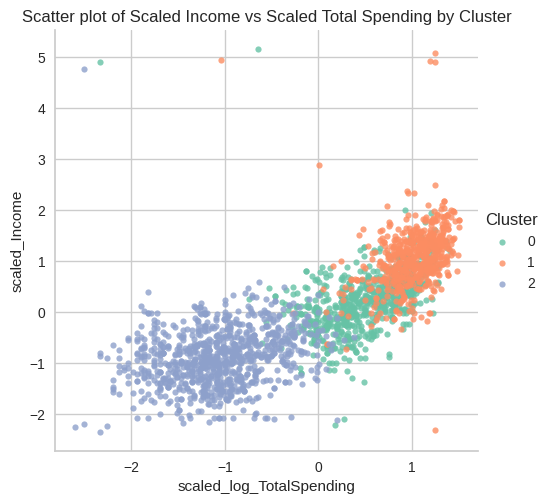

In [62]:
# Assuming df_prep is your DataFrame with scaled features and 'Cluster' column
# scaled feature columns names as per your example
sns.lmplot(
    y='scaled_Income',
    x='scaled_log_TotalSpending',
    hue='Cluster',
    data=df_scaled,
    fit_reg=False,              # no regression line
    palette='Set2',             # or your preferred palette variable, e.g. color
    scatter_kws={'s': 20, 'alpha': 0.8}
).set(title='Scatter plot of Scaled Income vs Scaled Total Spending by Cluster')

plt.show()

### Cluster Separation: Income vs Total Spending

The scatter plot shows clear separation between clusters with a strong positive relationship—higher income drives higher spending. Cluster 2 (blue) packs tightly in the lower-left quadrant with both income and spending between -2 and -0.5, representing low-value customers with limited purchasing power. Cluster 1(orange) sits in the upper-right with scaled values mostly above 0.5, reaching 2-3 and some outliers hitting 5. These are high-income, high-spending customers who are clearly distinct from the other segments.

Cluster 0 (green) occupies the middle zone with income and spending ranging from -1 to 1, bridging the gap between budget and premium customers. What's interesting is the overlap—Cluster 1 bleeds into both extremes, suggesting these customers are in transition. Some lean toward budget behavior while others show potential to move into the high-value segment, making this cluster a prime target for upselling campaigns.


### 2.7 EDA Summary

### Clustering Analysis Summary

We explored the dataset's structure using unsupervised learning to uncover customer patterns. First, I applied PCA to reduce dimensionality into 4 principal components capturing 81% of variance, which facilitated visualization and improved clustering.

Then, we selected k=3 clusters after testing multiple configurations. While k=4 showed a natural elbow point, reducing to 4 principal components and 3 clusters produced clearer separation, well-defined centroids, and better interpretability without sacrificing meaningful segmentation.

#### Cluster Profiles

Cluster 0 ( n=680, 30%) occupies the center region—these are middle-tier customers with moderate income and spending patterns. Cluster 1 ( n=637, 28%) is positioned on the right, representing high-value customers with the strongest financial profiles and highest response rate (25.43%). Cluster 2 ( n=919, 41%) sits on the left, capturing low-engagement customers with below-average metrics but higher price sensitivity (8.81% response rate).

#### Key Insights

The scatter plot of income vs. spending shows clear cluster separation. Clusters 0 and 1 concentrate at higher values, while Cluster 2 clusters densely at lower values, confirming a strong positive income-spending relationship.

Marketing should focus on retaining Cluster 1, nurturing Cluster 0 with targeted efforts, and optimizing resource allocation for Cluster 2. Segmentation provides a foundation, but complementary predictive models are recommended for identifying high-propensity responders within each segment.

---
## Step 3: Feature Engineering

In this step, we create innovative features to enhance model performance:


**Summary of previous feature engineering steps**

Previously, we began by creating several derived features to enhance data analysis and model performance. These new variables simplify raw data into more meaningful insights:

* Age: Calculated from birth year (2025 - Year_Birth), providing a better measure of customer age for modeling.
* TotalSpending: Aggregates spending across product categories to capture overall purchasing power.
* TotalPurchases: Sum of purchases across different sales channels, indicating customer activity.
* TotalChildren: Combines number of kids and teens to represent family size.
* TotalAcceptedCmp: Total accepted marketing campaigns, measuring customer receptiveness.
* CustomerTenure: Days since signup, distinguishing new versus loyal customers.
* IsParent: Binary flag indicating presence of children.

Additionally, ratio features were engineered to capture behavioral nuances:

* CVR (Conversion Rate): Efficiency of web visits converting into purchases, helping identify decisive buyers.
* CatalogPurchaseRatio: Preference for catalog channel, guiding marketing spend decisions.
* DealsPurchaseRatio: Sensitivity to promotions, segmenting price-conscious buyers.

To avoid redundancy and multicollinearity, original detailed features were replaced by these aggregated metrics.

**PCA**

then we used PCA to shrink the data down to 4 components that explain about 81% of the variance. This captures the main info while making clustering easier.


**Principal Component Extraction and Dataset Integration**

Before extracting the principal components, we first examined the data dimensionality and position to understand the dataset structure. We also reviewed the metrics that would compose the PCA, ensuring all variables were appropriately scaled and prepared for dimensionality reduction. This preliminary assessment helped us determine the optimal number of components to retain and verified that the data met the assumptions for PCA application

In [63]:
df_scaled.head()

,scaled_Income,scaled_Recency,scaled_Age,scaled_TotalPurchases,scaled_TotalChildren,scaled_CustomerTenure,Education_Diploma,Education_High School,Education_Master,Education_PhD,IsParent,scaled_log_TotalSpending,scaled_TotalAcceptedCmp,scaled_log_CVR,scaled_log_CatalogPurchaseRatio,scaled_log_DealsPurchaseRatio,Marital_Status_Single,Response,Complain,Cluster
0,0.288947,0.306856,1.016868,1.319340,-1.264308,1.529793,0.0,0.0,0.0,0.0,0,1.202519,-0.438933,0.153968,1.999889,-0.454638,1.0,1,0,1
1,-0.262003,-0.383971,1.273264,-1.155857,1.395139,-1.191143,0.0,0.0,0.0,0.0,1,-1.558363,-0.438933,-0.860271,0.134054,1.231315,1.0,0,0,2
2,0.918423,-0.798467,0.333146,0.798246,-1.264308,-0.206659,0.0,0.0,0.0,0.0,0,0.703320,-0.438933,0.588307,-0.318279,-1.222757,0.0,0,0,1
3,-1.182183,-0.798467,-1.290693,-0.895310,0.065416,-1.062517,0.0,0.0,0.0,0.0,1,-1.111381,-0.438933,-0.780621,-1.164327,0.630514,0.0,0,0,2
4,0.296187,1.550344,-1.034298,0.537699,0.065416,-0.953679,0.0,0.0,0.0,1.0,1,0.289489,-0.438933,0.222092,0.194636,0.897116,0.0,0,0,0


In [64]:
# Create DataFrame for loading matrix
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=significant_features
)

print("PCA LOADINGS MATRIX")
print("="*80)
print(loadings.round(3))

PCA LOADINGS MATRIX
                                   PC1    PC2    PC3    PC4
scaled_Income                    0.398  0.049 -0.152 -0.015
scaled_Recency                   0.008  0.132  0.029  0.989
scaled_Age                       0.089  0.463 -0.575 -0.031
scaled_TotalPurchases            0.371  0.342  0.088 -0.081
scaled_TotalChildren            -0.270  0.513 -0.236 -0.054
scaled_CustomerTenure            0.033  0.446  0.748 -0.066
scaled_log_TotalSpending         0.425  0.180  0.093 -0.037
scaled_log_CVR                   0.417  0.000 -0.110 -0.000
scaled_log_CatalogPurchaseRatio  0.388 -0.020  0.016  0.036
scaled_log_DealsPurchaseRatio   -0.341  0.392  0.028 -0.060


In [65]:
X_pca

array([[ 2.59657674,  1.00795941,  1.05256664,  0.18018769],
       [-2.22953085,  0.51438615, -2.03980776, -0.32869716],
       [ 1.85811053, -0.7207883 , -0.17839173, -0.76151525],
       ...,
       [ 1.44308537, -1.45783862,  0.27313456,  1.58876891],
       [ 2.04407244,  0.13077003, -1.50800797, -1.43246614],
       [-1.25259484,  1.98650959, -0.06890191, -0.52935061]])

**PCA Visualization**


The 3D PCA biplot projects customer behavior patterns onto the first three principal components, visually separating customers by their acceptance status. The direction and length of feature vectors indicate their contribution to these components. Notably, CustomerTenure strongly influences the vertical axis and aligns with accepted customers, suggesting longer-tenured customers tend to be accepted. Features like TotalSpending, TotalPurchases, Income, and CatalogPurchaseRatio cluster near the center, collectively contributing to customer segmentation based on purchasing behavior and financial capacity.

Conversely, vectors such as TotalChildren and DealsPurchaseRatio point away from the accepted cluster, hinting these factors differentiate non-accepted customers. The clustering of features in similar directions suggests certain behavioral and demographic traits collectively impact acceptance probability.

In [66]:
import plotly.graph_objects as go

# Create DataFrame for loading matrix
# This code is added to ensure pca_loadings is defined before use
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=significant_features
)
pca_loadings = loadings  # Assign to pca_loadings as used in the loop

# Scale factor
scale = 3

# Create figure
fig = go.Figure()

# Add scatter points for data (colored by Response)
fig.add_trace(go.Scatter3d(
    x=X_pca[df_scaled['Response']==0, 0],
    y=X_pca[df_scaled['Response']==0, 1],
    z=X_pca[df_scaled['Response']==0, 2],
    mode='markers',
    marker=dict(size=3, color='#ff6b6b', opacity=0.4),
    name='Not Accepted (0)'
))

fig.add_trace(go.Scatter3d(
    x=X_pca[df_scaled['Response']==1, 0],
    y=X_pca[df_scaled['Response']==1, 1],
    z=X_pca[df_scaled['Response']==1, 2],
    mode='markers',
    marker=dict(size=3, color='#4ecdc4', opacity=0.4),
    name='Accepted (1)'
))

# Add loading arrows
for col, row in loadings.iterrows():
    short_name = col.replace('scaled_', '').replace('log_', '')

    # Arrow line
    fig.add_trace(go.Scatter3d(
        x=[0, row['PC1']*scale],
        y=[0, row['PC2']*scale],
        z=[0, row['PC3']*scale],
        mode='lines+text',
        line=dict(color='darkblue', width=4),
        text=['', short_name],
        textposition='top center',
        textfont=dict(size=10, color='darkblue'),
        showlegend=False
    ))

# Update layout
fig.update_layout(
    title='3D PCA Biplot - Customer Behavior Patterns (Interactive)',
    scene=dict(
        xaxis_title=f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
        yaxis_title=f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)',
        zaxis_title=f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)'
    ),
    width=900,
    height=700
)

fig.show()

In [67]:
import plotly.graph_objects as go

# Plot 3D PC1-PC2-PC4
fig2 = go.Figure()
fig2.add_trace(go.Scatter3d(
    x=X_pca[df_scaled['Response']==0, 0],
    y=X_pca[df_scaled['Response']==0, 1],
    z=X_pca[df_scaled['Response']==0, 3],
    mode='markers',
    marker=dict(size=3, color='#ff6b6b', opacity=0.4),
    name='Not Accepted (0)'
))
fig2.add_trace(go.Scatter3d(
    x=X_pca[df_scaled['Response']==1, 0],
    y=X_pca[df_scaled['Response']==1, 1],
    z=X_pca[df_scaled['Response']==1, 3],
    mode='markers',
    marker=dict(size=3, color='#4ecdc4', opacity=0.4),
    name='Accepted (1)'
))

fig2.update_layout(scene=dict(
    xaxis_title=f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
    yaxis_title=f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)',
    zaxis_title=f'PC4 ({pca.explained_variance_ratio_[3]*100:.1f}%)'),
    title="3D PCA Plot: PC1, PC2, PC4",
    width=900, height=700)
fig2.show()

**PCA Extraction**

Next, we extracted key features from the PCA results and merged these principal components back into the dataset. We then removed the original high-dimensional features used for PCA and clustering. This approach simplifies the data representation and enhances the effectiveness and interpretability of the clustering process.

In [68]:
# Copy dataframe (note the parentheses)
df_new = df_scaled.copy()

# Add PCA components
df_new['PC1'] = X_pca[:, 0]
df_new['PC2'] = X_pca[:, 1]
df_new['PC3'] = X_pca[:, 2]
df_new['PC4'] = X_pca[:, 3]
# Check results
print(f"Shape: {df_new.shape}")
print(f"Columns: {df_new.columns.tolist()}")

Shape: (2236, 24)
Columns: ['scaled_Income', 'scaled_Recency', 'scaled_Age', 'scaled_TotalPurchases', 'scaled_TotalChildren', 'scaled_CustomerTenure', 'Education_Diploma', 'Education_High School', 'Education_Master', 'Education_PhD', 'IsParent', 'scaled_log_TotalSpending', 'scaled_TotalAcceptedCmp', 'scaled_log_CVR', 'scaled_log_CatalogPurchaseRatio', 'scaled_log_DealsPurchaseRatio', 'Marital_Status_Single', 'Response', 'Complain', 'Cluster', 'PC1', 'PC2', 'PC3', 'PC4']


In [69]:
# Remove features already represented by PCA
cols_to_drop = [
    'scaled_Income', 'scaled_Recency', 'scaled_Age', 'scaled_TotalPurchases',
    'scaled_TotalChildren', 'scaled_CustomerTenure',
    'scaled_log_TotalSpending', 'scaled_log_CVR',
    'scaled_log_CatalogPurchaseRatio', 'scaled_log_DealsPurchaseRatio'
]

df_new = df_new.drop(columns=cols_to_drop)

# Check results
print(f"Shape: {df_new.shape}")
print(f"Columns: {df_new.columns.tolist()}")

Shape: (2236, 14)
Columns: ['Education_Diploma', 'Education_High School', 'Education_Master', 'Education_PhD', 'IsParent', 'scaled_TotalAcceptedCmp', 'Marital_Status_Single', 'Response', 'Complain', 'Cluster', 'PC1', 'PC2', 'PC3', 'PC4']


## Step 4: Model Training and Evaluation

**Model Training Approach**

We trained and compared three classifiers:

We developed and evaluated three supervised learning classifiers to predict campaign response:

- Logistic Regression – A linear baseline model enhanced with Ridge and Lasso regularization to manage multicollinearity and prevent overfitting
- Random Forest – An ensemble method leveraging multiple decision trees to capture complex, nonlinear feature interactions
- XGBoost – A gradient boosting framework optimized for predictive accuracy and computational efficiency

**Addressing Class Imbalance**

Given the imbalanced nature of campaign responses (14.5% positive class), we implemented several strategies:

- Stratified K-Fold Cross-Validation ensured consistent class distribution across training and validation folds, providing reliable performance estimates
- SMOTE was applied exclusively to Logistic Regression during training. Linear models are sensitive to class imbalance, and SMOTE's synthetic minority samples improved the model's ability to learn positive class patterns
- Random Forest and XGBoost were trained on the original imbalanced data. Preliminary experiments showed these tree-based ensembles effectively handle imbalance through their inherent ability to learn complex decision boundaries and feature interactions. Applying SMOTE to these models yielded no performance gains and occasionally induced overfitting

**Regularization and Generalization**

Each model incorporated regularization appropriate to its architecture:

- Logistic Regression: L1 (Lasso) and L2 (Ridge) penalties to shrink coefficients and reduce model complexity
- XGBoost: Regularization parameters (gamma, reg_alpha, reg_lambda) combined with early stopping to prevent overfitting
- Random Forest: Tree depth constraints (max_depth, min_samples_split, min_samples_leaf) to control model complexity

**Evaluation metric**

To comprehensively assess model performance, we evaluated each classifier using five metrics :

- Accuracy: Measures overall proportion of correctly classified instances. However, it can be misleading in imbalanced datasets where the majority class dominates the metric.

- Precision: Quantifies the reliability of positive predictions - what proportion of predicted responders are actual responders. Critical when false positives (unnecessary outreach) have significant costs.

- Recall: Captures the proportion of actual responders correctly identified by the model. Important when missing potential responders has high opportunity cost.

- F1-Score: Harmonic mean of precision and recall, providing a balanced measure. Particularly valuable for imbalanced datasets to ensure neither metric is disproportionately sacrificed.

- ROC-AUC: Evaluates the model's ability to discriminate between classes across all classification thresholds. Provides a threshold-independent measure of class separability that is robust to class imbalance.

### 4.1 Prepare Data for Modeling

**Data Preparation and Train-Test Split**

We prepared the dataset for modeling by separating features from the target variable. The feature matrix X contains 13 variables (2,236 samples × 13 features), including categorical encodings (Education levels, Marital Status), behavioral indicators (IsParent, Complain, TotalAcceptedCmp), cluster assignments, and the four principal components from our earlier PCA analysis. The target variable y represents campaign response (binary: 0 = no response, 1 = response).



In [70]:
# PREPARE FEATURES AND TARGET


# Separate features and target
X = df_new.drop(columns=['Response'])
y = df_new['Response']

print(f" Features shape: {X.shape}")
print(f" Target shape: {y.shape}")
print(f"\n Target distribution:")
print(y.value_counts())

 Features shape: (2236, 13)
 Target shape: (2236,)

 Target distribution:
Response
0    1902
1     334
Name: count, dtype: int64


**Results and Interpretation**

The data shows significant class imbalance, with 1,902 non-responders (85%) versus 334 responders (15%). This imbalance needs careful handling during model training to prevent the classifier from simply predicting the majority class.

We performed a stratified train-test split with an 80-20 ratio, using stratification to preserve the class distribution in both sets. This resulted in 1,788 training samples and 448 test samples. The stratified approach successfully maintained the original class proportions—the training set contains 85% non-responders (1,521) and 15% responders (267), while the test set mirrors this with 85% non-responders (381) and 15% responders (67). This ensures our model evaluation is representative of the true population distribution.

**The following image presents the output generated from the code execution above : **
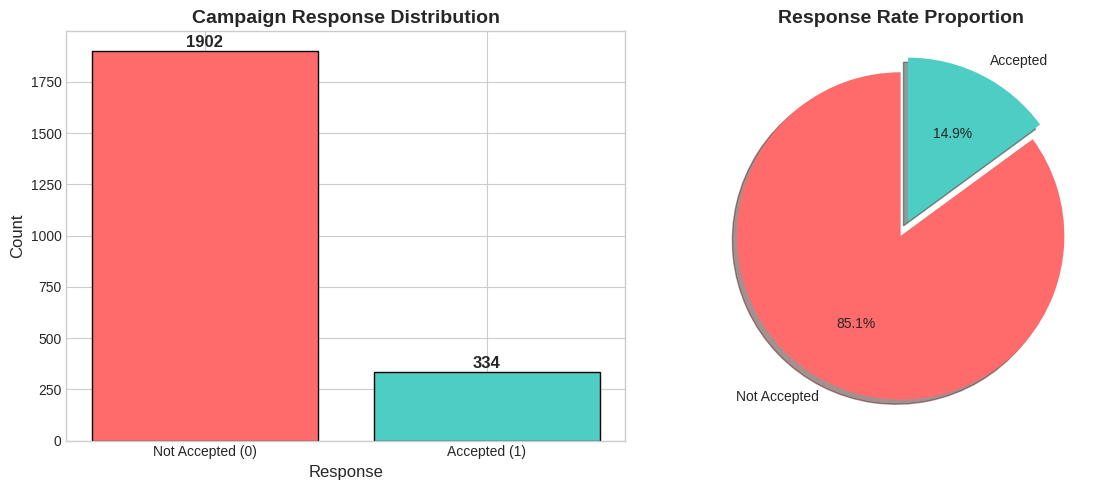

In [71]:
# TRAIN-TEST SPLIT
# Using stratified split to maintain class distribution


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining target distribution:")
print(y_train.value_counts())
print(f"\n Test target distribution:")
print(y_test.value_counts())


Training set: 1788 samples
Test set: 448 samples

Training target distribution:
Response
0    1521
1     267
Name: count, dtype: int64

 Test target distribution:
Response
0    381
1     67
Name: count, dtype: int64


In [72]:
# DATA TYPES AND STRUCTURE

list_item = []
for col in df_new.columns:
    list_item.append([
        col,
        df_new[col].dtype,
        df_new[col].isna().sum(),
        round(100*df_new[col].isna().sum()/len(df_new[col]), 2),
        df_new[col].nunique(),
        df_new[col].unique()[:5]
    ])

desc_df_new = pd.DataFrame(
    data=list_item,
    columns=['feature', 'data_type', 'null_values',
             'null_percentage', 'unique_values', 'unique_sample']
)

desc_df_new

,feature,data_type,null_values,null_percentage,unique_values,unique_sample
0,Education_Diploma,float64,0,0.0,2,"[0.0, 1.0]"
1,Education_High School,float64,0,0.0,2,"[0.0, 1.0]"
2,Education_Master,float64,0,0.0,2,"[0.0, 1.0]"
3,Education_PhD,float64,0,0.0,2,"[0.0, 1.0]"
4,IsParent,int64,0,0.0,2,"[0, 1]"
5,scaled_TotalAcceptedCmp,float64,0,0.0,5,"[-0.43893256174123346, 1.0347209038044092, 2.5083743693500518, 3.9820278348956943, 5.455681300441337]"
6,Marital_Status_Single,float64,0,0.0,2,"[1.0, 0.0]"
7,Response,int64,0,0.0,2,"[1, 0]"
8,Complain,int64,0,0.0,2,"[0, 1]"
9,Cluster,int32,0,0.0,3,"[1, 2, 0]"


**Feature Structure Analysis**

The feature inspection table confirms our dataset is clean with no missing values across all 13 variables. The features include:

* Categorical encodings (Education_Diploma, Education_High School, etc., and Marital_Status_Single) are binary indicators (0.0 or 1.0)

* Behavioral variables like IsParent, Complain, and Response are binary integers

* Cluster assignments from our segmentation analysis (3 unique values: 0, 1, 2)

* Principal components (PC1-PC4) are continuous variables with 2,031 unique values each, representing the dimensionality-reduced customer profiles

All features are properly encoded and scaled, making the dataset ready for training across our three classifier types.

**Standard Scaller and Log Transforming**

All features are properly encoded and scaled, ready for model training. Prior preprocessing included log transformation to address skewness and StandardScaler for normalization, ensuring clean data with handled outliers and distributional issues.

**Handling Imbalance with SMOTE**

To address the severe class imbalance (85% non-responders vs. 15% responders), we applied SMOTE to the training set only. SMOTE creates synthetic minority samples by interpolating between existing instances, expanding our training data from 1,788 to 3,042 samples with perfect 50-50 balance. The minority class increased from 267 to 1,521 samples, matching the majority class count. This prevents the Logistic Regression model from simply predicting the majority class and allows it to learn meaningful patterns from both responders and non-responders equally

In [73]:
# HANDLE CLASS IMBALANCE WITH SMOTE
# Applied only to training data

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"\n Before SMOTE: {len(y_train)} samples")
print(y_train.value_counts())
print(f"\n After SMOTE: {len(y_train_resampled)} samples")
print(pd.Series(y_train_resampled).value_counts())


 Before SMOTE: 1788 samples
Response
0    1521
1     267
Name: count, dtype: int64

 After SMOTE: 3042 samples
Response
1    1521
0    1521
Name: count, dtype: int64


### 4.2 Cross-Validation Setup

then We implemented 10-fold stratified K-Fold cross-validation, which provides optimal bias-variance trade-off (Kohavi, 1995) while maintaining consistent class proportions across folds (Refaeilzadeh et al., 2009). The evaluation framework calculates five key metrics—accuracy, precision, recall, F1-score, and ROC-AUC—with mean and standard deviation reported across folds to assess model performance and prediction stability.

In [74]:
# CROSS-VALIDATION SETUP


# Stratified K-Fold with 5 folds
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define evaluation metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Function to evaluate models
def evaluate_model(model, X, y, cv, model_name):
    """
    Evaluate model using cross-validation and return metrics
    """
    results = {}

    for metric in scoring:
        scores = cross_val_score(model, X, y, cv=cv, scoring=metric)
        results[metric] = {
            'mean': scores.mean(),
            'std': scores.std()
        }

    return results



### 4.3 Model 1: Logistic Regression with Regularization

Logistic Regression with Hyperparameter Tuning

Logistic Regression was implemented with GridSearchCV to optimize regularization strength (C: 0.001 to 10) and penalty type (L1 vs. L2) using 10-fold stratified cross-validation. After evaluating model configurations, the best performer used moderate L2 regularization (C=1), achieving 82% accuracy and 90% ROC-AUC on the SMOTE-balanced training data.



In [75]:
# LOGISTIC REGRESSION WITH HYPERPARAMETER TUNING

print("MODEL 1: LOGISTIC REGRESSION")

# Define hyperparameter grid
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['saga']
}

# Initialize model
lr_base = LogisticRegression(max_iter=1000, random_state=42)

# Grid search with cross-validation using MULTIPLE SCORING METRICS
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Grid search with cross-validation
lr_grid_search = GridSearchCV(
    lr_base,
    lr_param_grid,
    cv=cv,
    scoring=scoring,
    refit='roc_auc',  # Best model selected based on ROC-AUC
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)
# Fit on resampled data
lr_grid_search.fit(X_train_resampled, y_train_resampled)

# Best model
lr_best = lr_grid_search.best_estimator_
# Predictions on TRAINING Set
y_pred_lr_train = lr_best.predict(X_train_resampled)
y_prob_lr_train = lr_best.predict_proba(X_train_resampled)[:, 1]

# Metrics for Training Set
lr_metrics_train = {
    'Accuracy': accuracy_score(y_train_resampled, y_pred_lr_train),
    'Precision': precision_score(y_train_resampled, y_pred_lr_train),
    'Recall': recall_score(y_train_resampled, y_pred_lr_train),
    'F1-Score': f1_score(y_train_resampled, y_pred_lr_train),
    'ROC-AUC': roc_auc_score(y_train_resampled, y_prob_lr_train)
}

# Display Best Parameters
print(f"\n Best Parameters: {lr_grid_search.best_params_}")

print("\n Logistic Regression - Training Set Performance:")
for metric, value in lr_metrics_train.items():
    print(f"   {metric}: {value:.4f}")

print("\n Classification Report (Training):")
print(classification_report(y_train_resampled, y_pred_lr_train, target_names=['Not Accepted', 'Accepted']))

MODEL 1: LOGISTIC REGRESSION
Fitting 10 folds for each of 10 candidates, totalling 100 fits

 Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'saga'}

 Logistic Regression - Training Set Performance:
   Accuracy: 0.8235
   Precision: 0.8178
   Recall: 0.8323
   F1-Score: 0.8250
   ROC-AUC: 0.9025

 Classification Report (Training):
              precision    recall  f1-score   support

Not Accepted       0.83      0.81      0.82      1521
    Accepted       0.82      0.83      0.83      1521

    accuracy                           0.82      3042
   macro avg       0.82      0.82      0.82      3042
weighted avg       0.82      0.82      0.82      3042



Test set performance revealed a notable precision-recall trade-off: while the model maintained 81% accuracy and 88% ROC-AUC, precision for responders fell to 42% despite 76% recall. This imbalance stems from SMOTE training, which encourages the model to favor minority class predictions. The high ROC-AUC confirms strong probability ranking, meaning threshold adjustment could balance precision and recall according to operational priorities—whether minimizing false alarms or maximizing responder identification.

In [76]:
# EVALUATE LOGISTIC REGRESSION ON TEST SET

# Predictions
y_pred_lr = lr_best.predict(X_test)
y_prob_lr = lr_best.predict_proba(X_test)[:, 1]

# Metrics
lr_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1-Score': f1_score(y_test, y_pred_lr),
    'ROC-AUC': roc_auc_score(y_test, y_prob_lr)
}

print("\n Logistic Regression - Test Set Performance:")
for metric, value in lr_metrics.items():
    print(f"   {metric}: {value:.4f}")

print("\n Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Not Accepted', 'Accepted']))


 Logistic Regression - Test Set Performance:
   Accuracy: 0.8080
   Precision: 0.4215
   Recall: 0.7612
   F1-Score: 0.5426
   ROC-AUC: 0.8799

 Classification Report:
              precision    recall  f1-score   support

Not Accepted       0.95      0.82      0.88       381
    Accepted       0.42      0.76      0.54        67

    accuracy                           0.81       448
   macro avg       0.69      0.79      0.71       448
weighted avg       0.87      0.81      0.83       448



### 4.4 Model 2: Random Forest

We initially tested Random Forest with SMOTE but found it significantly increased overfitting without improving generalization.

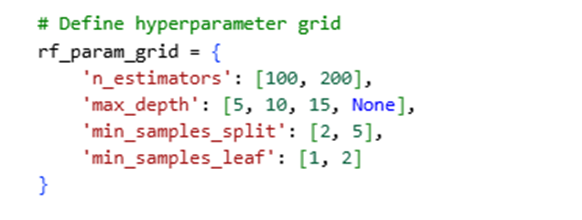

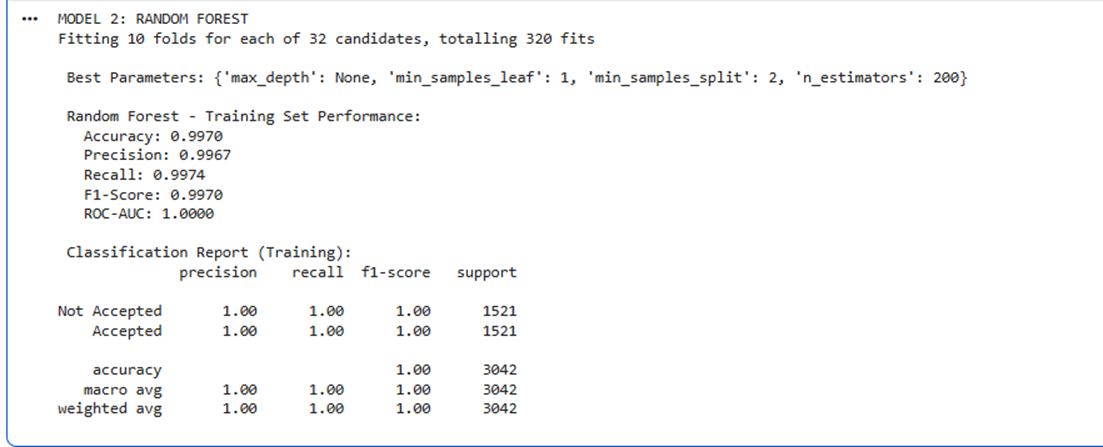

Instead, we trained Random Forest on the original imbalanced data, controlling overfitting through regularization: max depth of 7, minimum 15 samples for splits, 5 samples per leaf, sqrt feature selection, and bootstrap sampling. GridSearchCV tested 162 combinations across 10-fold cross-validation. The model shows some overfitting (95% training ROC-AUC vs 87% test), but this gap can be narrowed with tighter constraints or more data.



In [77]:
# RANDOM FOREST WITH HYPERPARAMETER TUNING

print("MODEL 2: RANDOM FOREST")

# Define hyperparameter grid
rf_param_grid = {
    'n_estimators': [100, 200, 300],        # 3 values
    'max_depth': [3, 5, 7],                 # 3 values
    'min_samples_split': [10, 15, 20],      # 3 values
    'min_samples_leaf': [5, 10, 15],        # 3 values
    'max_features': ['sqrt', 'log2'],       # 2 values
    'bootstrap': [True]                     # 1 value
}

# Initialize model
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Grid search with MULTIPLE SCORING METRICS
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Grid search
rf_grid_search = GridSearchCV(
    rf_base,
    rf_param_grid,
    cv=cv,
    scoring=scoring,
    refit='roc_auc',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Fit on ORIGINAL training data
rf_grid_search.fit(X_train, y_train)

# Best model
rf_best = rf_grid_search.best_estimator_

# Predictions on Training Set (tanpa SMOTE)
y_pred_rf_train = rf_best.predict(X_train)
y_prob_rf_train = rf_best.predict_proba(X_train)[:, 1]

# Metrics for Training Set
rf_metrics_train = {
    'Accuracy': accuracy_score(y_train, y_pred_rf_train),
    'Precision': precision_score(y_train, y_pred_rf_train),
    'Recall': recall_score(y_train, y_pred_rf_train),
    'F1-Score': f1_score(y_train, y_pred_rf_train),
    'ROC-AUC': roc_auc_score(y_train, y_prob_rf_train)
}

# Display Results
print(f"\n Best Parameters: {rf_grid_search.best_params_}")

print("\n Random Forest - Training Set Performance:")
for metric, value in rf_metrics_train.items():
    print(f"   {metric}: {value:.4f}")

print("\n Classification Report (Training):")
print(classification_report(y_train, y_pred_rf_train, target_names=['Not Accepted', 'Accepted']))


MODEL 2: RANDOM FOREST
Fitting 10 folds for each of 162 candidates, totalling 1620 fits

 Best Parameters: {'bootstrap': True, 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 15, 'n_estimators': 100}

 Random Forest - Training Set Performance:
   Accuracy: 0.8999
   Precision: 0.9583
   Recall: 0.3446
   F1-Score: 0.5069
   ROC-AUC: 0.9512

 Classification Report (Training):
              precision    recall  f1-score   support

Not Accepted       0.90      1.00      0.94      1521
    Accepted       0.96      0.34      0.51       267

    accuracy                           0.90      1788
   macro avg       0.93      0.67      0.73      1788
weighted avg       0.91      0.90      0.88      1788



In [78]:
# EVALUATE RANDOM FOREST ON TEST SET

# Predictions
y_pred_rf = rf_best.predict(X_test)
y_prob_rf = rf_best.predict_proba(X_test)[:, 1]

# Metrics
rf_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_prob_rf)
}

print("\n Random Forest - Test Set Performance:")
for metric, value in rf_metrics.items():
    print(f"   {metric}: {value:.4f}")

print("\n Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Not Accepted', 'Accepted']))


 Random Forest - Test Set Performance:
   Accuracy: 0.8750
   Precision: 0.7895
   Recall: 0.2239
   F1-Score: 0.3488
   ROC-AUC: 0.8739

 Classification Report:
              precision    recall  f1-score   support

Not Accepted       0.88      0.99      0.93       381
    Accepted       0.79      0.22      0.35        67

    accuracy                           0.88       448
   macro avg       0.83      0.61      0.64       448
weighted avg       0.87      0.88      0.84       448



Random Forest achieved 87.5% accuracy and 87.4% ROC-AUC with a highly conservative strategy—79% precision but only 22% recall for responders. It's the opposite of Logistic Regression: Random Forest flags responders only when extremely confident, catching 99% of non-responders but missing three-quarters of actual responders. This precision-focused approach works well when marketing budgets are tight and false alarms waste resources, though it leaves money on the table. The strong ROC-AUC means adjusting the decision threshold could shift this balance toward capturing more responders if needed.

### 4.5 Model 3: XGBoost (Gradient Boosting)

Previously, we trained XGBoost using SMOTE-resampled data without regularization and tuning, which resulted in significant overfitting—the model fit training data nearly perfectly but failed to generalize on unseen data.

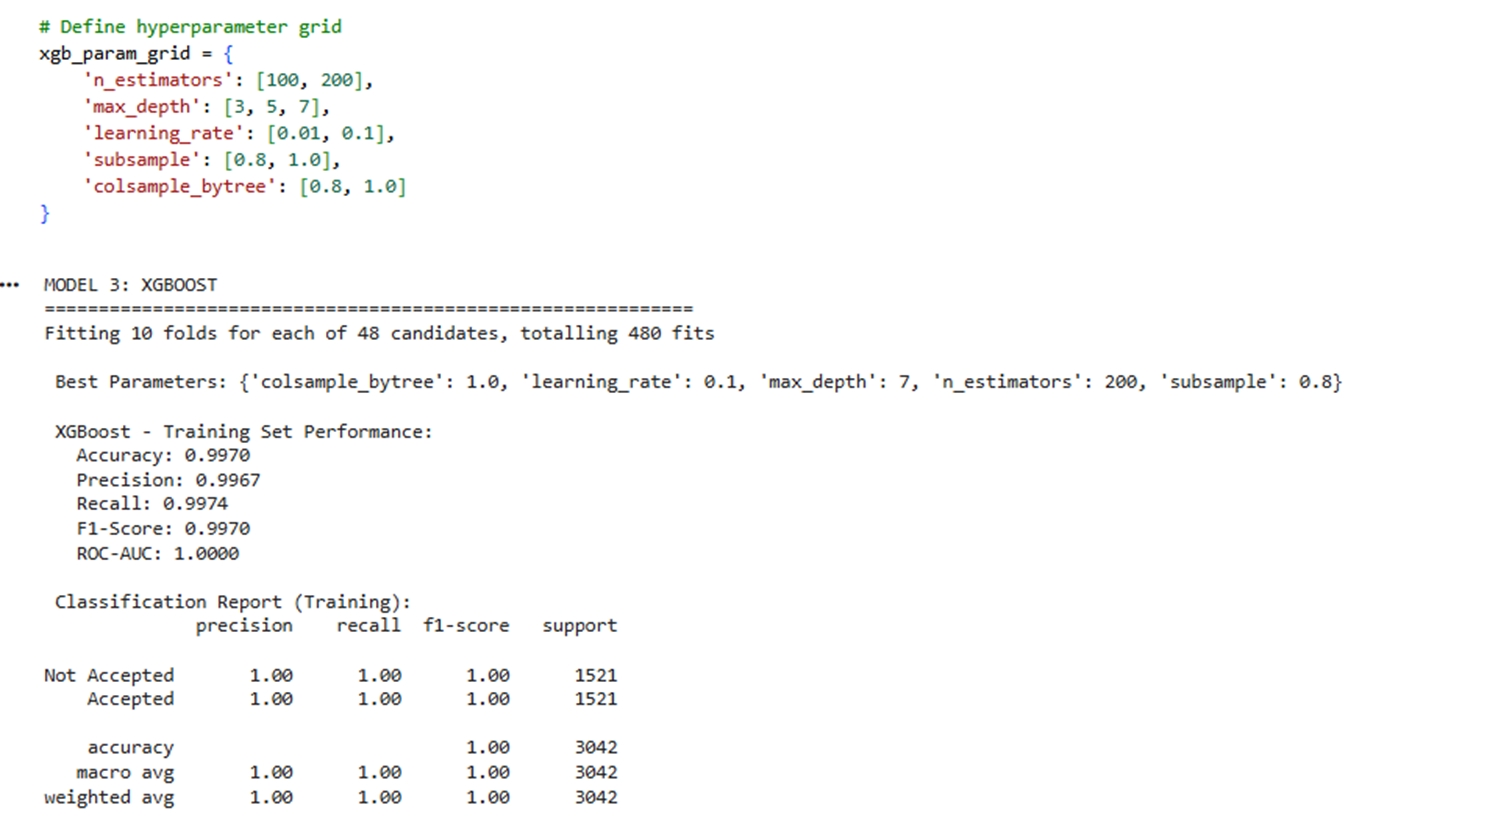



To fix this, we switched to the original training data with comprehensive hyperparameter tuning and regularization (max_depth, learning rate, subsample, gamma, reg_alpha, reg_lambda).

In [79]:
# XGBOOST WITH HYPERPARAMETER TUNING

print("MODEL 3: XGBOOST")
print("="*60)

# Define hyperparameter grid
xgb_param_grid = {
    'n_estimators': [100, 200],               # 2 values
    'max_depth': [3, 5],                      # 2 values
    'learning_rate': [0.01, 0.05, 0.1],       # 3 values
    'subsample': [0.8, 1.0],                  # 2 values
    'colsample_bytree': [0.8, 1.0],           # 2 values
    'gamma': [0, 0.1],                        # 2 values
    'reg_alpha': [0, 0.5],                    # 2 values
    'reg_lambda': [1, 5]                      # 2 values
}


# Initialize model
xgb_base = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Grid search with MULTIPLE SCORING METRICS
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Grid search
xgb_grid_search = GridSearchCV(
    xgb_base,
    xgb_param_grid,
    cv=cv,
    scoring=scoring,
    refit='roc_auc',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# Fit on ORIGINAL training data (no resampling)
xgb_grid_search.fit(X_train, y_train)

# Best model
xgb_best = xgb_grid_search.best_estimator_

# Predictions on ORIGINAL training set
y_pred_xgb_train = xgb_best.predict(X_train)
y_prob_xgb_train = xgb_best.predict_proba(X_train)[:, 1]

# Metrics for training set using original data
xgb_metrics_train = {
    'Accuracy': accuracy_score(y_train, y_pred_xgb_train),
    'Precision': precision_score(y_train, y_pred_xgb_train),
    'Recall': recall_score(y_train, y_pred_xgb_train),
    'F1-Score': f1_score(y_train, y_pred_xgb_train),
    'ROC-AUC': roc_auc_score(y_train, y_prob_xgb_train)
}

print(f"\nBest Parameters: {xgb_grid_search.best_params_}")

print("\nXGBoost - Training Set Performance:")
for metric, value in xgb_metrics_train.items():
    print(f"   {metric}: {value:.4f}")

print("\nClassification Report (Training):")
print(classification_report(y_train, y_pred_xgb_train, target_names=['Not Accepted', 'Accepted']))

MODEL 3: XGBOOST
Fitting 10 folds for each of 384 candidates, totalling 3840 fits

Best Parameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'reg_alpha': 0.5, 'reg_lambda': 5, 'subsample': 0.8}

XGBoost - Training Set Performance:
   Accuracy: 0.9211
   Precision: 0.8795
   Recall: 0.5468
   F1-Score: 0.6744
   ROC-AUC: 0.9436

Classification Report (Training):
              precision    recall  f1-score   support

Not Accepted       0.93      0.99      0.96      1521
    Accepted       0.88      0.55      0.67       267

    accuracy                           0.92      1788
   macro avg       0.90      0.77      0.81      1788
weighted avg       0.92      0.92      0.91      1788



This balanced the model better—training performance showed 92% accuracy and 94% ROC-AUC, while test results reached 88% accuracy and 88% ROC-AUC with 66% precision and 43% recall. The improved generalization demonstrates that regularization effectively controlled overfitting compared to the SMOTE approach.



In [80]:
# EVALUATE XGBOOST ON TEST SET

# Predictions
y_pred_xgb = xgb_best.predict(X_test)
y_prob_xgb = xgb_best.predict_proba(X_test)[:, 1]

# Metrics
xgb_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1-Score': f1_score(y_test, y_pred_xgb),
    'ROC-AUC': roc_auc_score(y_test, y_prob_xgb)
}

print("\n XGBoost - Test Set Performance:")
for metric, value in xgb_metrics.items():
    print(f"   {metric}: {value:.4f}")

print("\n Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Not Accepted', 'Accepted']))


 XGBoost - Test Set Performance:
   Accuracy: 0.8817
   Precision: 0.6591
   Recall: 0.4328
   F1-Score: 0.5225
   ROC-AUC: 0.8834

 Classification Report:
              precision    recall  f1-score   support

Not Accepted       0.91      0.96      0.93       381
    Accepted       0.66      0.43      0.52        67

    accuracy                           0.88       448
   macro avg       0.78      0.70      0.73       448
weighted avg       0.87      0.88      0.87       448



### 4.5.1 Ensemble model

The stacking ensemble hit 88% accuracy and 0.89 ROC-AUC on test data with minimal overfitting. It takes a middle path—69% precision but only 40% recall for responders—catching fewer responders than Logistic Regression (76% recall) but more than Random Forest (22%). The meta-learner clearly favored the more cautious models, correctly flagging 97% of non-responders while missing 60% of actual responders. Bottom line: despite being the most complex approach and achieving the top ROC-AUC (0.886), it barely beats standalone XGBoost (0.883), making the extra complexity questionable for practical use.

In [81]:
# Ensemble model

# Define base learners with your tuned best hyperparameters (replace with your actual best params)
lr_clf = LogisticRegression(
    penalty='l2', C=1, solver='saga', max_iter=1000, random_state=42
)
rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=7, min_samples_split=15, min_samples_leaf=10,
    max_features='sqrt', bootstrap=True, random_state=42, n_jobs=-1
)
xgb_clf = XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    gamma=0, reg_alpha=0.5, reg_lambda=5, use_label_encoder=False, eval_metric='logloss',
    random_state=42, n_jobs=-1
)

# Stacking classifier using Logistic Regression as final estimator
stacking_clf = StackingClassifier(
    estimators=[
        ('lr', lr_clf),
        ('rf', rf_clf),
        ('xgb', xgb_clf)
    ],
    final_estimator=LogisticRegression(random_state=42, max_iter=1000),
    passthrough=False,
    n_jobs=-1,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
)

# Fit stacking ensemble on original training data (X_train, y_train)
stacking_clf.fit(X_train, y_train)

# Predict on training and test sets
y_pred_train = stacking_clf.predict(X_train)
y_pred_test = stacking_clf.predict(X_test)
y_prob_train = stacking_clf.predict_proba(X_train)[:, 1]
y_prob_test = stacking_clf.predict_proba(X_test)[:, 1]

# Evaluate metrics function
def compute_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

# Compute and print training and test metrics
train_metrics = compute_metrics(y_train, y_pred_train, y_prob_train)
test_metrics = compute_metrics(y_test, y_pred_test, y_prob_test)

print("\nStacking Ensemble - Training Set Performance:")
for metric, val in train_metrics.items():
    print(f"  {metric}: {val:.4f}")

print("\nStacking Ensemble - Test Set Performance:")
for metric, val in test_metrics.items():
    print(f"  {metric}: {val:.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=['Not Accepted', 'Accepted']))


Stacking Ensemble - Training Set Performance:
  Accuracy: 0.9105
  Precision: 0.8282
  Recall: 0.5056
  F1-Score: 0.6279
  ROC-AUC: 0.9315

Stacking Ensemble - Test Set Performance:
  Accuracy: 0.8839
  Precision: 0.6923
  Recall: 0.4030
  F1-Score: 0.5094
  ROC-AUC: 0.8862

Classification Report (Test Set):
              precision    recall  f1-score   support

Not Accepted       0.90      0.97      0.93       381
    Accepted       0.69      0.40      0.51        67

    accuracy                           0.88       448
   macro avg       0.80      0.69      0.72       448
weighted avg       0.87      0.88      0.87       448



### 4.6 Model Comparison

We systematically compared Logistic Regression, Random Forest, and XGBoost by evaluating their performance on training and test sets across five key metrics: accuracy, precision, recall, F1-score, and ROC-AUC. To identify overfitting, we examined the gap between training and test ROC-AUC scores, large differences indicate models that memorize training patterns but fail to generalize.

In [82]:
print("MODEL COMPARISON")
print("="*70)


comparison_train_df = pd.DataFrame({
    'Logistic Regression': lr_metrics_train,
    'Random Forest': rf_metrics_train,
    'XGBoost': xgb_metrics_train,
    'Ensemble': train_metrics
}).T

print("\n TRAINING SET PERFORMANCE")
print("-"*70)
print(comparison_train_df.round(4))

comparison_test_df = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'Random Forest': rf_metrics,
    'XGBoost': xgb_metrics,
    'Ensemble': test_metrics
}).T

print("\n TEST SET PERFORMANCE")
print("-"*70)
print(comparison_test_df.round(4))

print("\n Best Model by Metric (Test Set):")
for col in comparison_test_df.columns:
    best_model = comparison_test_df[col].idxmax()
    best_value = comparison_test_df[col].max()
    print(f"   {col}: {best_model} ({best_value:.4f})")

print("\n Overfitting Check (Train - Test):")
print("-"*70)
for model in comparison_train_df.index:
    train_auc = comparison_train_df.loc[model, 'ROC-AUC']
    test_auc = comparison_test_df.loc[model, 'ROC-AUC']
    diff = train_auc - test_auc
    status = " Good" if diff < 0.05 else " Possible Overfitting" if diff < 0.10 else " Overfitting"
    print(f"   {model}: Train={train_auc:.4f}, Test={test_auc:.4f}, Diff={diff:.4f} {status}")

MODEL COMPARISON

 TRAINING SET PERFORMANCE
----------------------------------------------------------------------
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.8235     0.8178  0.8323    0.8250   0.9025
Random Forest          0.8999     0.9583  0.3446    0.5069   0.9512
XGBoost                0.9211     0.8795  0.5468    0.6744   0.9436
Ensemble               0.9105     0.8282  0.5056    0.6279   0.9315

 TEST SET PERFORMANCE
----------------------------------------------------------------------
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.8080     0.4215  0.7612    0.5426   0.8799
Random Forest          0.8750     0.7895  0.2239    0.3488   0.8739
XGBoost                0.8817     0.6591  0.4328    0.5225   0.8834
Ensemble               0.8839     0.6923  0.4030    0.5094   0.8862

 Best Model by Metric (Test Set):
   Accuracy: Ensemble (0.8839)
   Precision: Random Forest (0.7895)
   Recal

Logistic Regression shows minimal overfitting (training ROC-AUC: 0.90, test: 0.88) with balanced generalization. Random Forest has the largest overfitting gap (0.95 to 0.87) and is overly conservative with high precision (0.96) but poor recall (0.34). XGBoost balances both with strong performance (training: 0.94, test: 0.88) and moderate overfitting. The Ensemble achieves the best test ROC-AUC (0.89) with controlled overfitting (0.93 to 0.89), but its middle-ground strategy—69% precision and 40% recall—doesn't significantly outperform standalone XGBoost, suggesting limited benefit from added complexity. All models maintain test ROC-AUC above 0.87, confirming they learned meaningful patterns despite different precision-recall trade-offs.

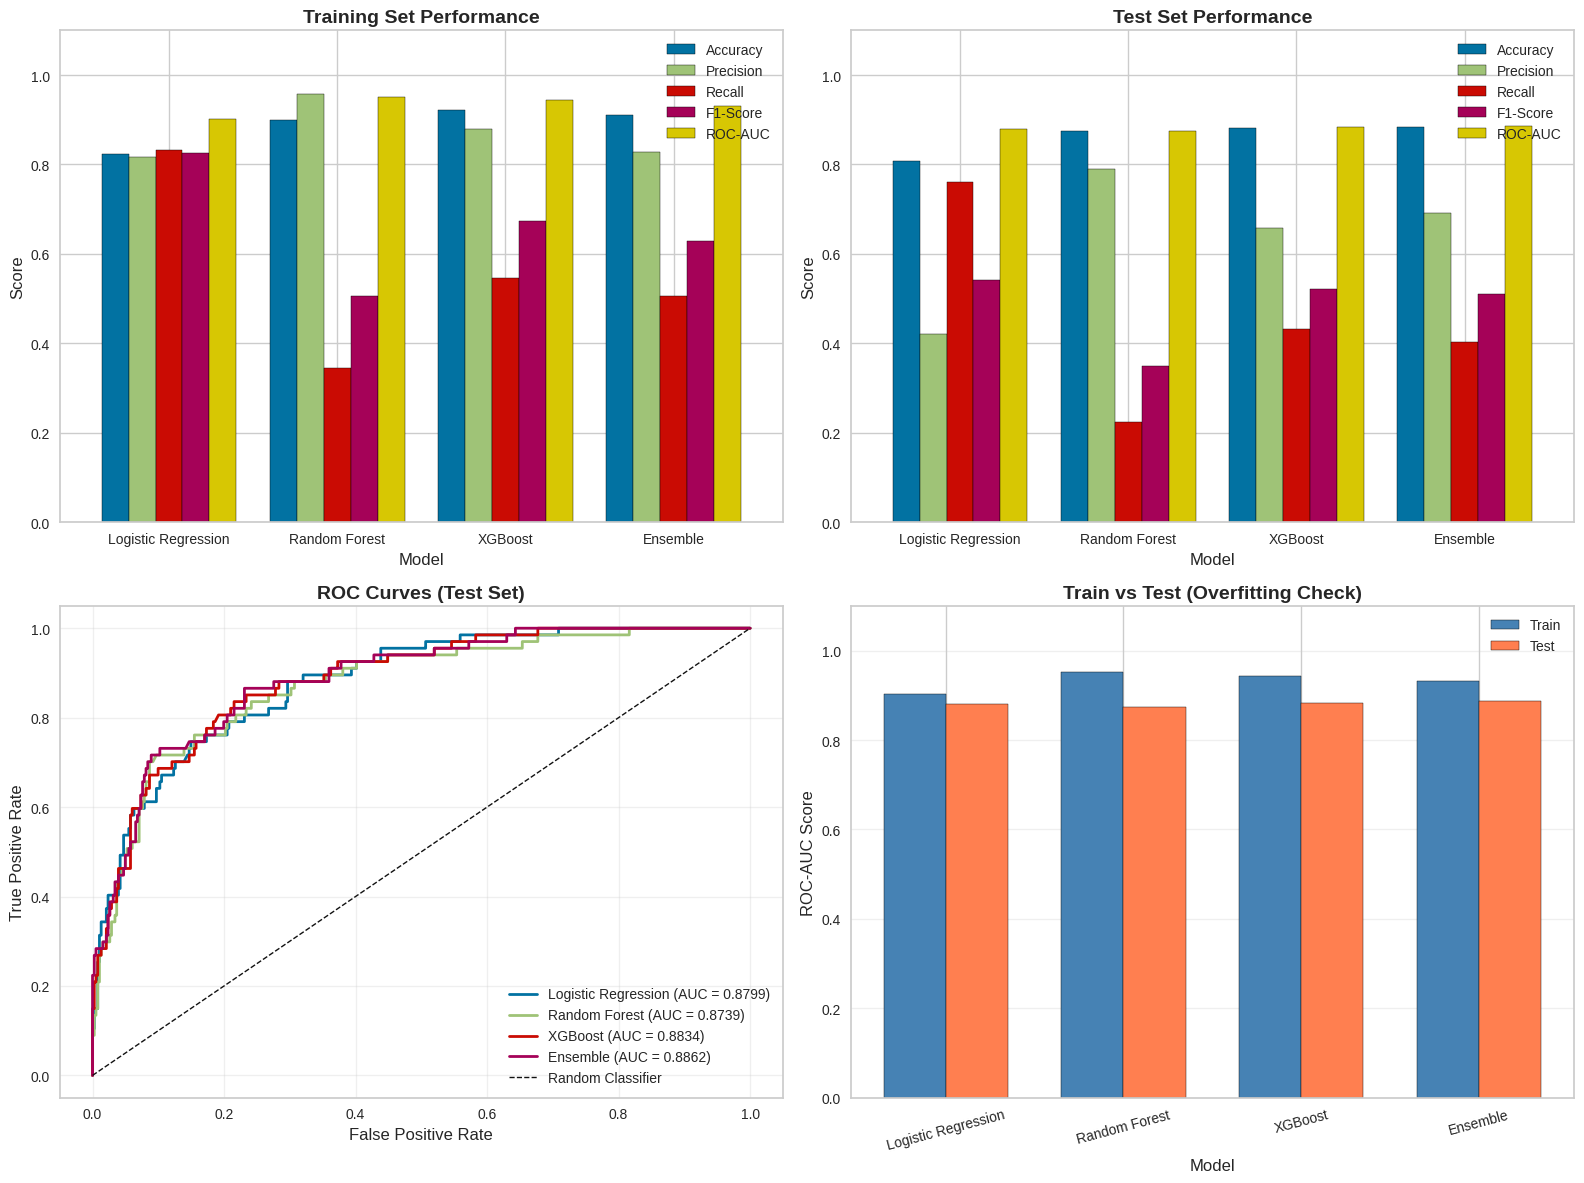

In [83]:
# VISUALIZE MODEL COMPARISON

fig, axes = plt.subplots(2, 2, figsize=(16, 12))


# 1. Bar Chart - TRAINING SET

comparison_train_df.plot(kind='bar', ax=axes[0, 0], edgecolor='black', width=0.8)
axes[0, 0].set_title('Training Set Performance', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Model', fontsize=12)
axes[0, 0].set_ylabel('Score', fontsize=12)
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=0)
axes[0, 0].legend(loc='upper right')
axes[0, 0].set_ylim([0, 1.1])


# 2. Bar Chart - TEST SET

comparison_test_df.plot(kind='bar', ax=axes[0, 1], edgecolor='black', width=0.8)
axes[0, 1].set_title('Test Set Performance', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Model', fontsize=12)
axes[0, 1].set_ylabel('Score', fontsize=12)
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=0)
axes[0, 1].legend(loc='upper right')
axes[0, 1].set_ylim([0, 1.1])


# 3. ROC Curves - TEST SET

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_ensemble, tpr_ensemble, _ = roc_curve(y_test, y_prob_test)

axes[1, 0].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_metrics["ROC-AUC"]:.4f})', linewidth=2)
axes[1, 0].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_metrics["ROC-AUC"]:.4f})', linewidth=2)
axes[1, 0].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {xgb_metrics["ROC-AUC"]:.4f})', linewidth=2)
axes[1, 0].plot(fpr_ensemble, tpr_ensemble, label=f'Ensemble (AUC = {test_metrics["ROC-AUC"]:.4f})', linewidth=2)
axes[1, 0].plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
axes[1, 0].set_xlabel('False Positive Rate', fontsize=12)
axes[1, 0].set_ylabel('True Positive Rate', fontsize=12)
axes[1, 0].set_title('ROC Curves (Test Set)', fontsize=14, fontweight='bold')
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(True, alpha=0.3)


# 4. Train vs Test ROC-AUC (Overfitting Check)

models = ['Logistic Regression', 'Random Forest', 'XGBoost',  'Ensemble']
train_auc = [
    lr_metrics_train['ROC-AUC'],
    rf_metrics_train['ROC-AUC'],
    xgb_metrics_train['ROC-AUC'],
    train_metrics['ROC-AUC']
]
test_auc = [
    lr_metrics['ROC-AUC'],
    rf_metrics['ROC-AUC'],
    xgb_metrics['ROC-AUC'],
    test_metrics['ROC-AUC']
]

x = np.arange(len(models))
width = 0.35

bars1 = axes[1, 1].bar(x - width/2, train_auc, width, label='Train', color='steelblue', edgecolor='black')
bars2 = axes[1, 1].bar(x + width/2, test_auc, width, label='Test', color='coral', edgecolor='black')



axes[1, 1].set_xlabel('Model', fontsize=12)
axes[1, 1].set_ylabel('ROC-AUC Score', fontsize=12)
axes[1, 1].set_title('Train vs Test (Overfitting Check)', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(models, rotation=15)
axes[1, 1].legend()
axes[1, 1].set_ylim([0, 1.1])
axes[1, 1].grid(True, alpha=0.3, axis='y')


plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Explanation of Model Evaluation Figures**

Training Set Performance (Top Left)
All four models achieve high accuracy and ROC-AUC, with Random Forest and XGBoost outperforming Logistic Regression. Random Forest shows extreme precision (0.96) but poor recall (0.34), signaling conservative predictions and likely overfitting. Logistic Regression maintains balanced precision-recall, while XGBoost strikes a middle ground. The Ensemble achieves 91% accuracy with 0.93 ROC-AUC, positioning between XGBoost and Random Forest.

Test Set Performance (Top Right)
Logistic Regression maintains high recall (0.76) but low precision (0.42), capturing most responders with many false positives. Random Forest's recall plummets to 0.22 despite high precision (0.79), confirming overfitting. XGBoost balances both metrics moderately (0.66 precision, 0.43 recall). The Ensemble leads with 88% accuracy and 0.89 ROC-AUC, adopting a middle-ground strategy (0.69 precision, 0.40 recall) between Logistic Regression's aggression and Random Forest's conservatism.

ROC Curves for Test Set (Bottom Left)
All models substantially outperform random classification. The Ensemble achieves the highest AUC (0.886), marginally beating XGBoost (0.883), Logistic Regression (0.880), and Random Forest (0.874). The minimal improvement over XGBoost suggests diminishing returns from added complexity.

Overfitting Analysis (Bottom Right)
Logistic Regression shows minimal overfitting (0.02 gap), demonstrating excellent generalization. Random Forest has the largest gap (0.08), followed by XGBoost (0.06). The Ensemble maintains good generalization (0.045 gap)—better than tree-based models but slightly worse than Logistic Regression—indicating the meta-learner effectively balanced model weights to control overfitting while preserving discriminative performance.

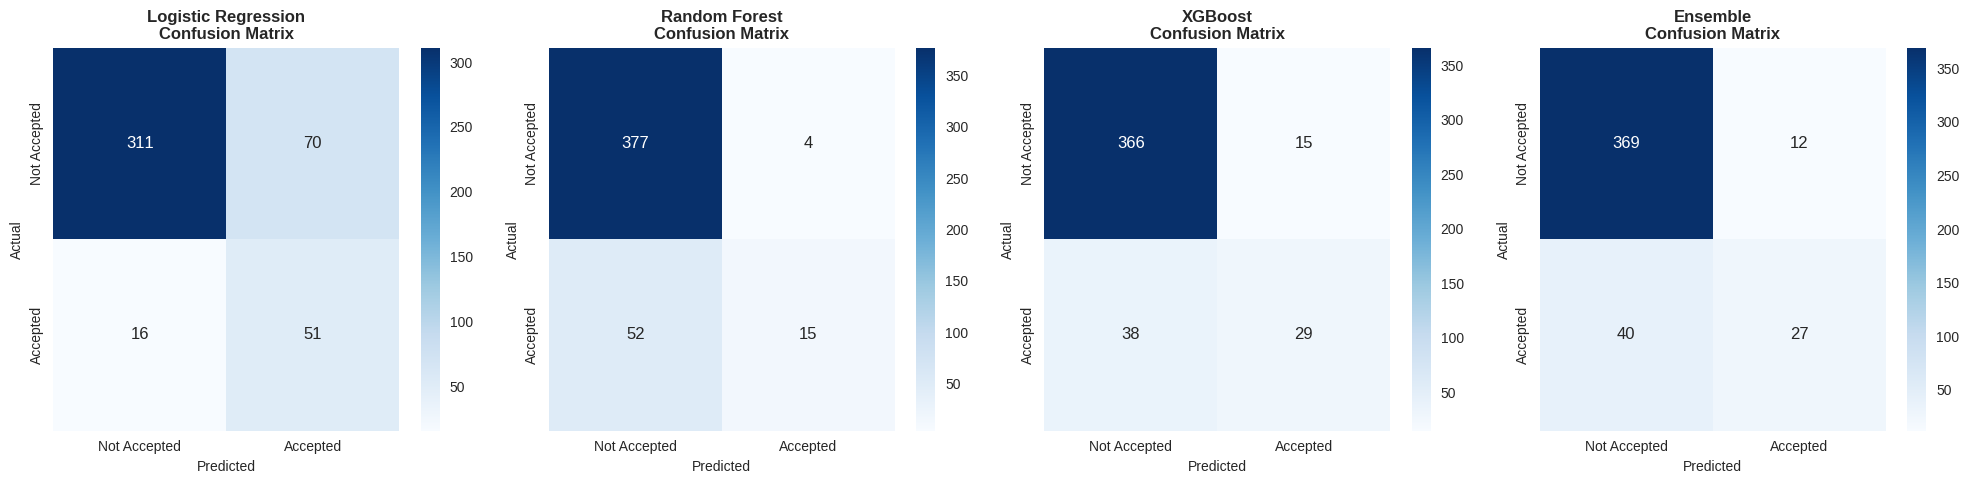

In [84]:
# CONFUSION MATRICES

fig, axes = plt.subplots(1, 4, figsize=(20, 5)) # Changed columns to 4

models = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb),
    ('Ensemble', y_pred_test)
]

for idx, (name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Not Accepted', 'Accepted'],
                yticklabels=['Not Accepted', 'Accepted'])
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

**Confusion Matrix Analysis**

The confusion matrices show prediction patterns on 448 test samples (381 non-responders, 67 responders).

* Logistic Regression correctly identifies 311 non-responders and 51 responders, but generates 70 false positives and 16 false negatives. This aggressive approach captures 76% of responders but creates many false alarms—high recall, low precision.

* Random Forest is extremely conservative, correctly identifying 377 non-responders with only 4 false positives. However, it misses 52 of 67 responders, catching just 15. When it predicts a responder it's usually right (high precision), but it rarely makes that call (terrible recall).

* XGBoost balances both: 366 correct non-responder predictions with 15 false positives, and 29 correct responder predictions with 38 false negatives. It's less aggressive than Logistic Regression but less timid than Random Forest, making it the most versatile choice

* The Ensemble lands between XGBoost and Random Forest: 369 correct non-responder predictions with 12 false positives, and 27 correct responder predictions with 40 false negatives. It's more conservative than XGBoost, capturing only 40% of responders (27/67) but maintaining higher precision.

---
## Step 5: Testing Model Assumptions

We verify key assumptions for our models:
1. **Logistic Regression:** Multicollinearity (VIF), linearity of log-odds
2. **Tree-based Models:** Feature importance stability, overfitting checks
3. **All Models:** Learning curves for bias-variance tradeoff

### 5.1 Variance Inflation Factor (VIF) for Multicollinearity

In [85]:
# VIF CALCULATION FOR MULTICOLLINEARITY
# VIF > 10 indicates severe multicollinearity

print("VARIANCE INFLATION FACTOR (VIF) ANALYSIS")
print("="*60)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X_train.columns
vif_data['VIF'] = [variance_inflation_factor(X_train.values, i)
                   for i in range(X_train.shape[1])]

# Sort by VIF
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n VIF Values (Top 15):")
print(vif_data.head(15).to_string(index=False))

# Identify problematic features
high_vif = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()
print(f"\n Features with VIF > 10 (potential multicollinearity): {len(high_vif)}")
if high_vif:
    print(f"   Features: {high_vif}")

VARIANCE INFLATION FACTOR (VIF) ANALYSIS

 VIF Values (Top 15):
                Feature      VIF
                Cluster 3.342590
               IsParent 3.276347
                    PC2 1.610525
                    PC1 1.524217
  Marital_Status_Single 1.475755
          Education_PhD 1.382139
       Education_Master 1.286440
scaled_TotalAcceptedCmp 1.169990
      Education_Diploma 1.161183
  Education_High School 1.108623
                    PC3 1.057042
                    PC4 1.022687
               Complain 1.015857

 Features with VIF > 10 (potential multicollinearity): 0


VIF scores show our dataset has no multicollinearity problems—all features fall well below the critical threshold of 10. Cluster membership scores highest at 3.34, followed by IsParent at 3.28, but these are still safe levels. The principal components (PC1-PC4) have very low VIF values between 1.02 and 1.61, which makes sense since PCA creates uncorrelated features by design. Education levels, marital status, and behavioral variables also show minimal correlation with each other. This confirms our preprocessing and feature engineering worked well, leaving us with a clean dataset where each feature contributes independent information to the models without redundancy issues.

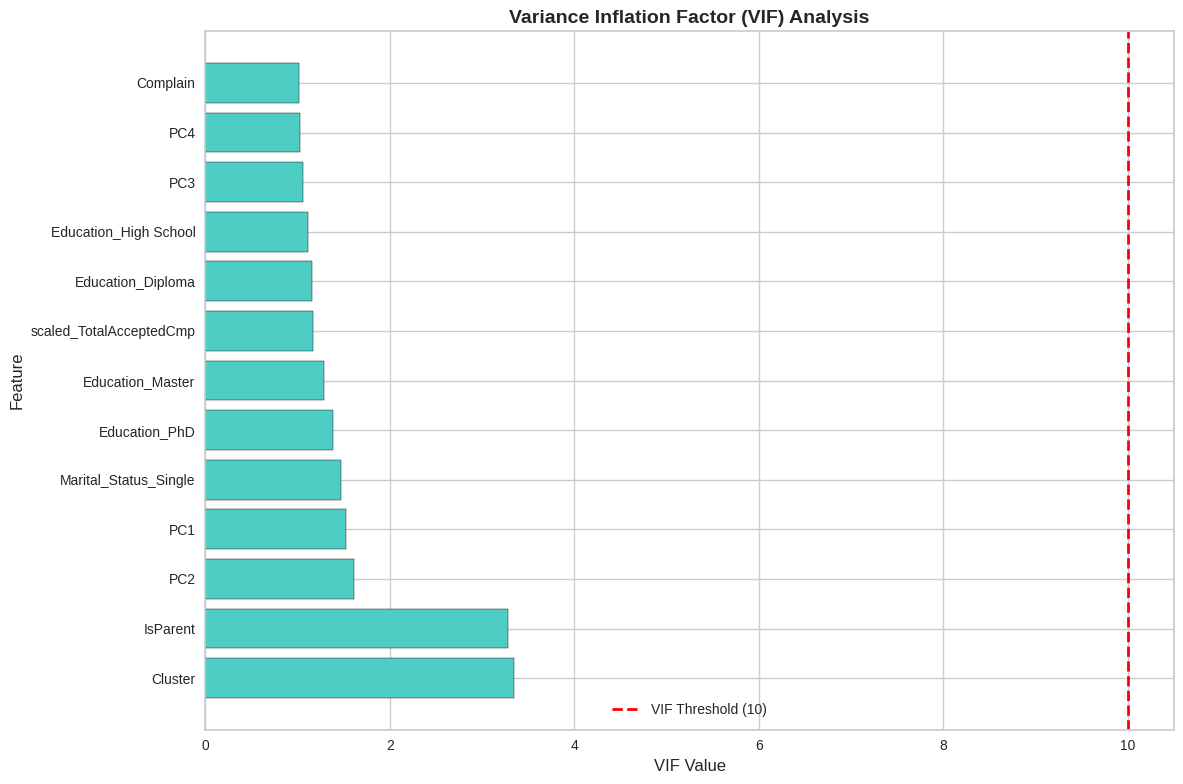


 Note: High VIF in some features (like TotalSpending, Spending_PCA1) is expected
   due to intentional feature engineering. These are still valuable for tree-based models.


In [86]:
# VIF VISUALIZATION


plt.figure(figsize=(12, 8))
colors = ['#ff6b6b' if vif > 10 else '#4ecdc4' for vif in vif_data['VIF']]
plt.barh(vif_data['Feature'], vif_data['VIF'], color=colors, edgecolor='black')
plt.axvline(x=10, color='red', linestyle='--', linewidth=2, label='VIF Threshold (10)')
plt.xlabel('VIF Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Variance Inflation Factor (VIF) Analysis', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('vif_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Note: High VIF in some features (like TotalSpending, Spending_PCA1) is expected")
print("   due to intentional feature engineering. These are still valuable for tree-based models.")

### 5.2 Learning Curves (Overfitting Check)

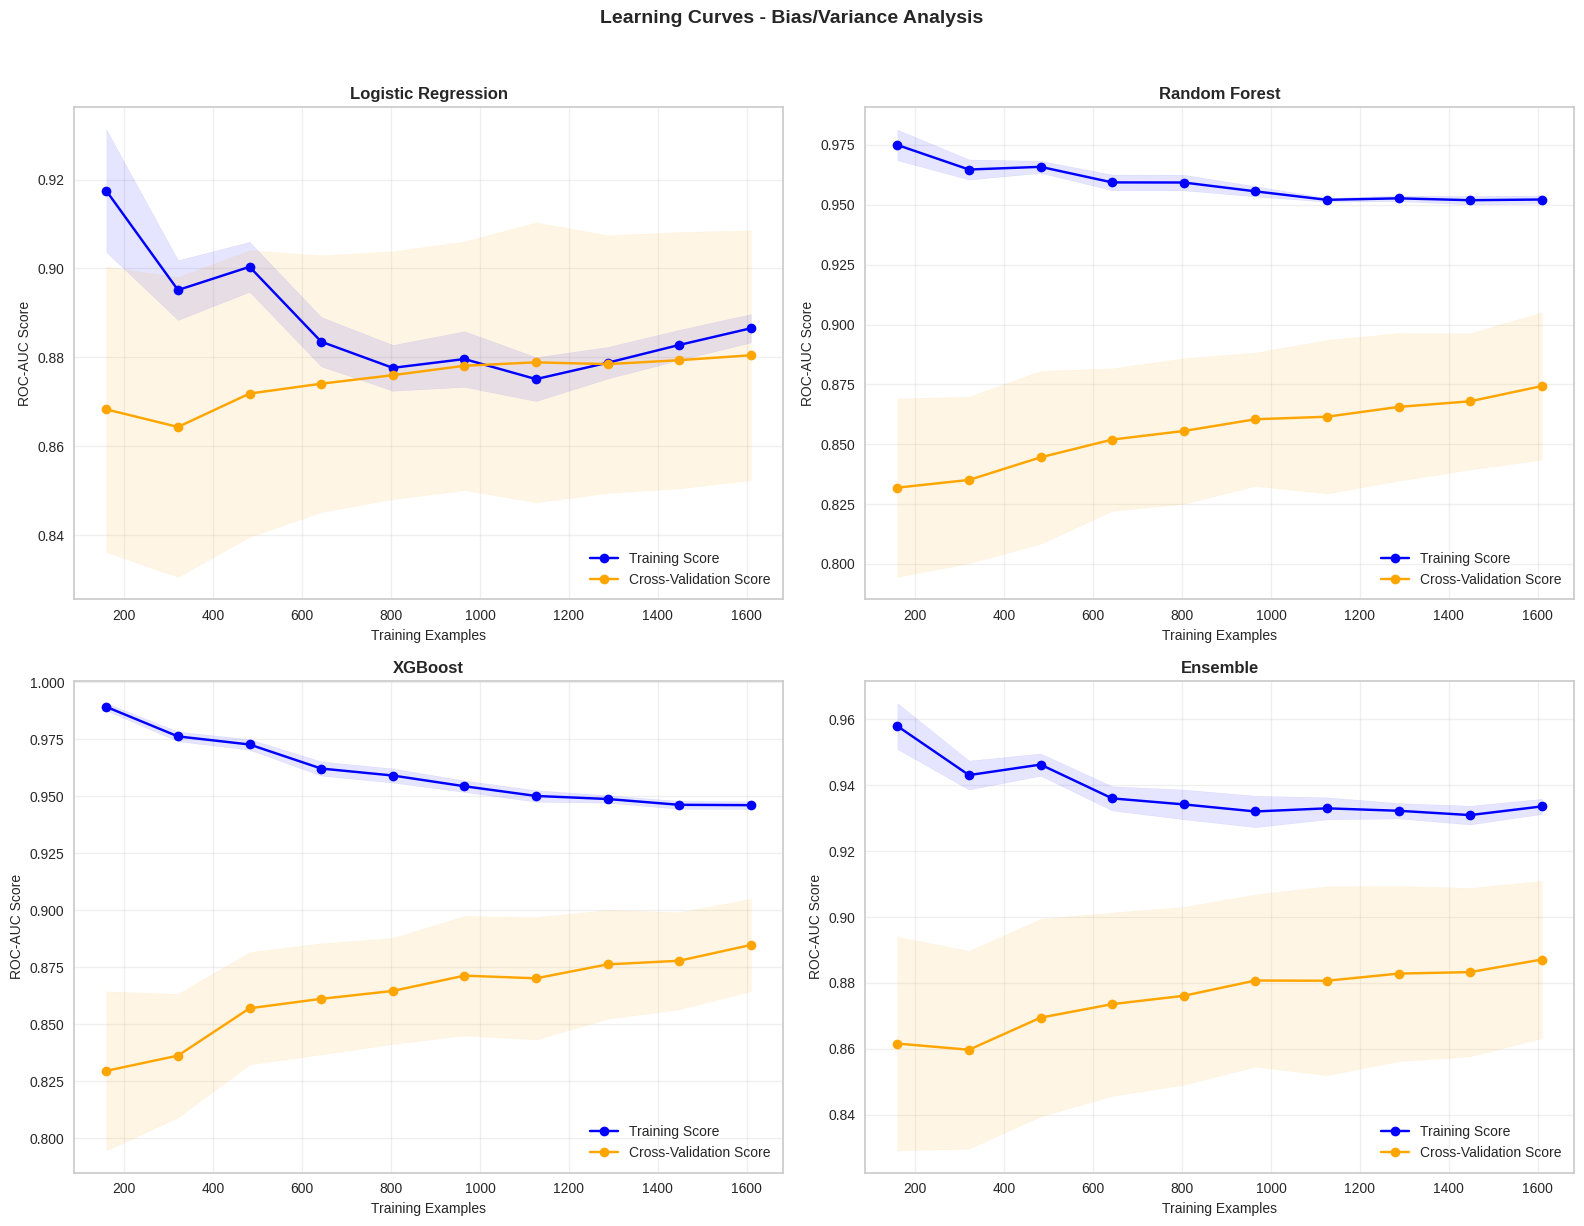


 Learning Curve Insights:
   - Training and CV scores converging: Good generalization
   - Large gap between curves: Overfitting (reduce model complexity)
   - Both scores low: Underfitting (increase model complexity)


In [87]:
# LEARNING CURVES FOR ALL MODELS

def plot_learning_curve(estimator, title, X, y, cv, ax):
    """
    Plot learning curve to check for overfitting/underfitting
    """
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='roc_auc'
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
    ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
    ax.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-Validation Score')
    ax.set_xlabel('Training Examples', fontsize=10)
    ax.set_ylabel('ROC-AUC Score', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot learning curves with ensemble included
plot_learning_curve(lr_best, 'Logistic Regression', X_train, y_train, cv, axes[0, 0])
plot_learning_curve(rf_best, 'Random Forest', X_train, y_train, cv, axes[0, 1])
plot_learning_curve(xgb_best, 'XGBoost', X_train, y_train, cv, axes[1, 0])
plot_learning_curve(stacking_clf, 'Ensemble', X_train, y_train, cv, axes[1, 1])

plt.suptitle('Learning Curves - Bias/Variance Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('learning_curves_with_ensemble.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Learning Curve Insights:")
print("   - Training and CV scores converging: Good generalization")
print("   - Large gap between curves: Overfitting (reduce model complexity)")
print("   - Both scores low: Underfitting (increase model complexity)")

learning curves were created to evaluate models performance and ability to generalize as training data increases. The curves plot ROC-AUC scores for training and cross-validation sets, with shaded regions representing variability.

The Logistic Regression curve shows good generalization with training and cross-validation scores close and gradually converging, indicating a balanced bias-variance tradeoff. In contrast, Random Forest and XGBoost exhibit high training scores near perfect, while their cross-validation scores lag significantly behind, signaling overfitting to the training data. The ensemble model demonstrates improved performance with closer training and validation scores, suggesting that combining models reduces overfitting and improves generalization. These insights guide further model tuning and selection.

---
## Step 6: SHAP Analysis and Summary Inference

We use **SHAP (SHapley Additive exPlanations)** to:
1. Understand global feature importance
2. Analyze individual predictions
3. Validate findings with statistical evidence

In [88]:
# SHAP ANALYSIS FOR XGBOOST (BEST MODEL)

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_best)

# Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test)


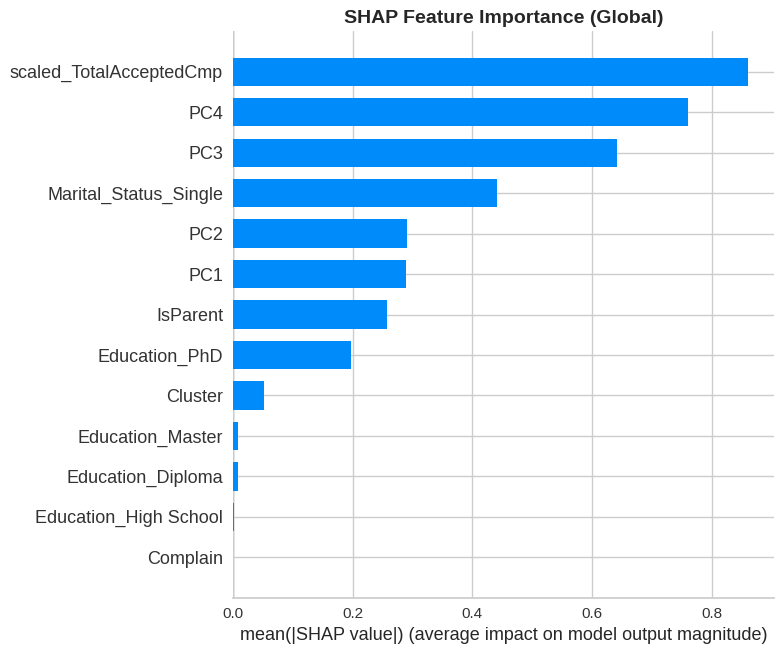

In [89]:
# SHAP SUMMARY PLOT (Global Feature Importance)

plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Global)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

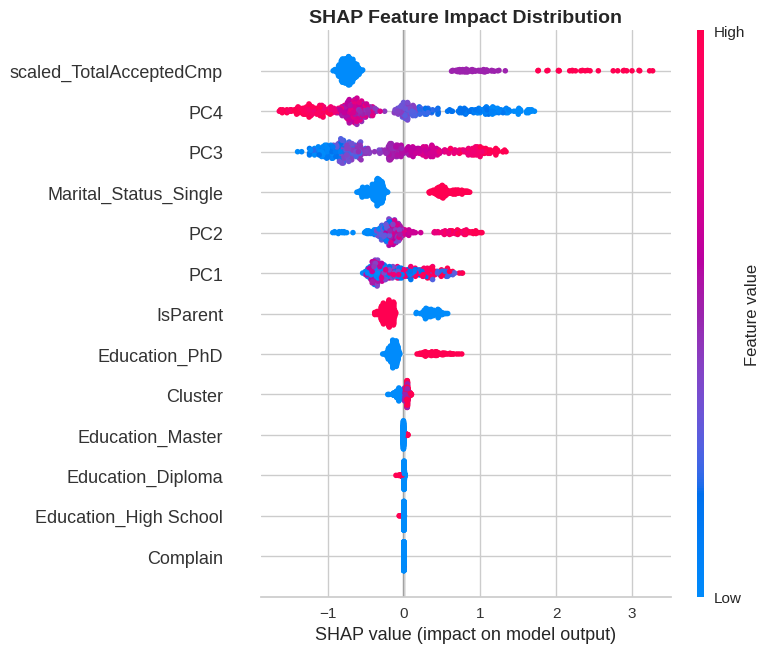


 SHAP Beeswarm Insights:
   - Red = High feature value, Blue = Low feature value
   - Right of center = Positive impact on prediction (higher probability of acceptance)
   - Left of center = Negative impact on prediction


In [90]:
# SHAP BEESWARM PLOT (Feature Impact Distribution)

plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Feature Impact Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n SHAP Beeswarm Insights:")
print("   - Red = High feature value, Blue = Low feature value")
print("   - Right of center = Positive impact on prediction (higher probability of acceptance)")
print("   - Left of center = Negative impact on prediction")

We implemented SHAP analysis to interpret the ensemble model by quantifying each feature's contribution to predictions. SHAP uses game theory to distribute prediction credit across features, showing how much each one pushes the output from baseline toward the final prediction. This generates two visualizations: global importance (average impact) and a beeswarm plot (individual prediction distributions colored by feature values).

The results show scaled_TotalAcceptedCmp dominates with the strongest impact, followed by PC4 and PC3. High campaign acceptance consistently pushes predictions toward positive response (red dots on the right), while low values push negative. Marital_Status_Single increases response probability, while principal components show complex bidirectional effects reflecting multivariate interactions. Features like Complain and Education_High_School have negligible impact, indicating the model learned to ignore them for campaign response predictions.

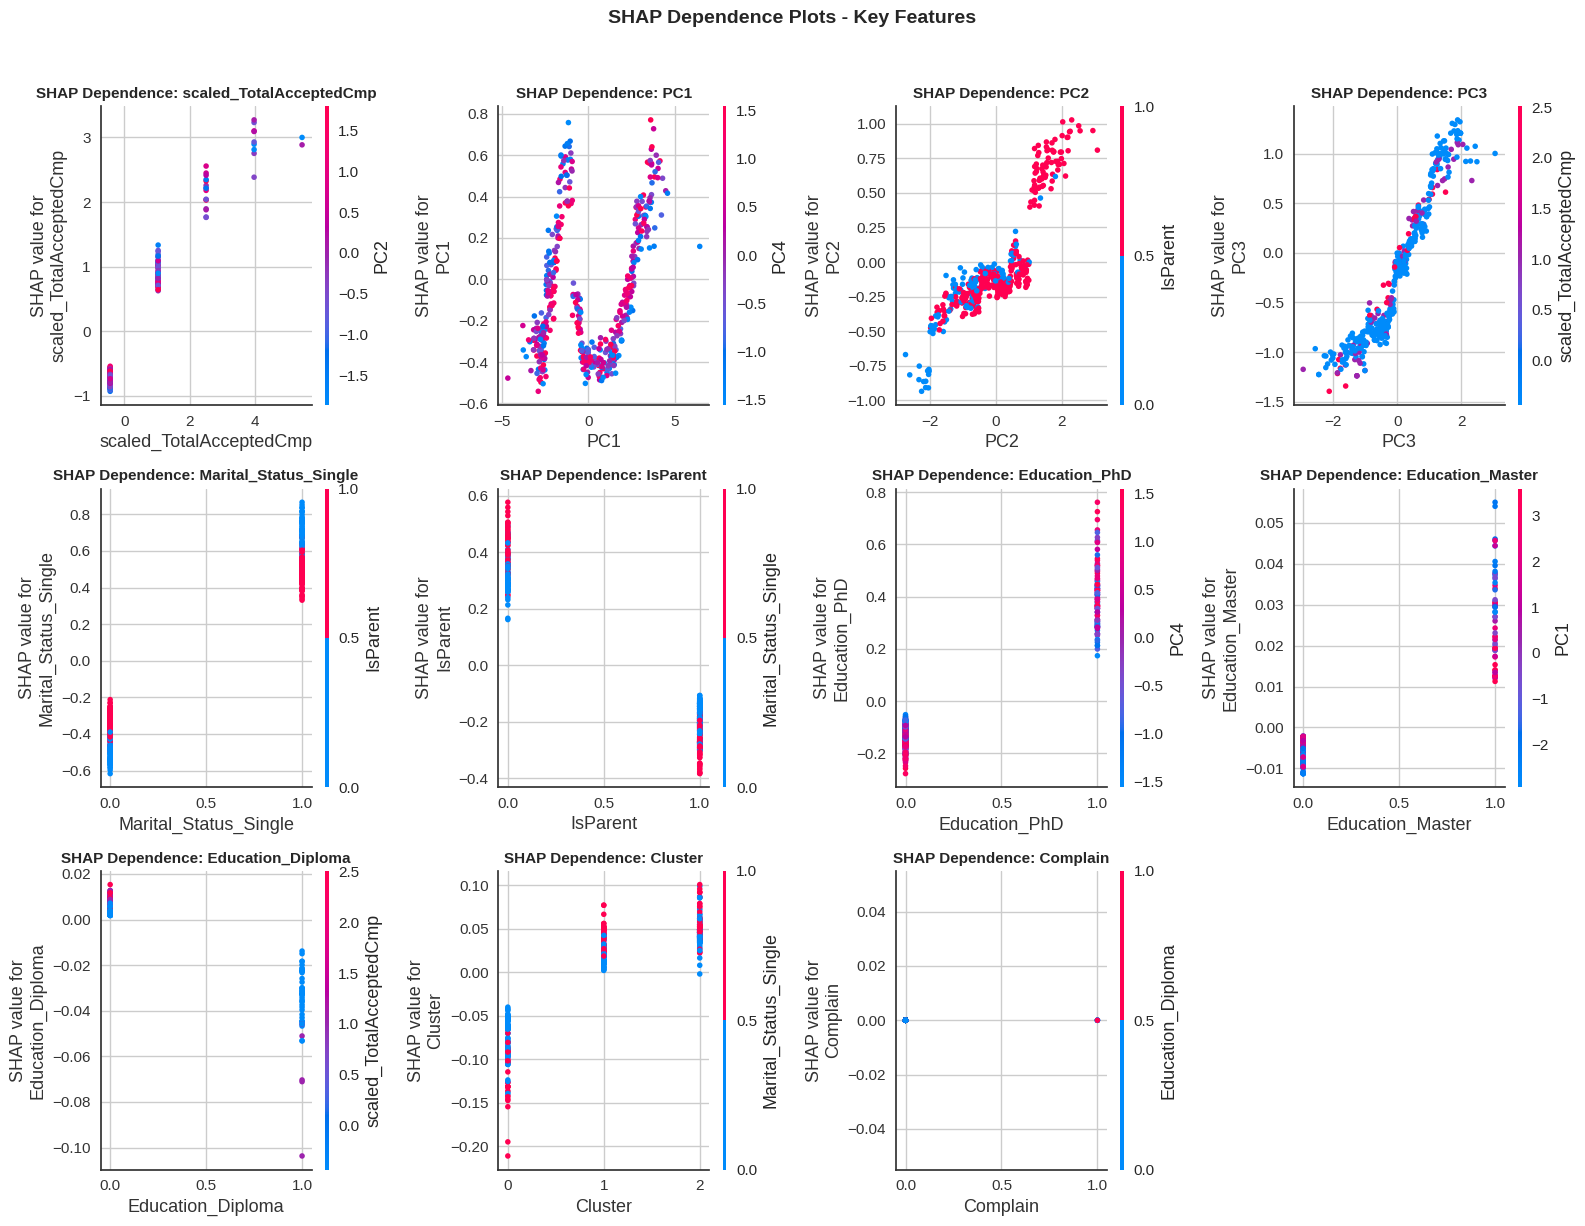

In [91]:
# SHAP DEPENDENCE PLOTS (Key Features)

# Top features to analyze
top_features = [
    'scaled_TotalAcceptedCmp', 'PC1', 'PC2', 'PC3',
    'Marital_Status_Single', 'IsParent',
    'Education_PhD', 'Education_Master', 'Education_Diploma', 'Cluster', 'Complain'
]

n_plots = len(top_features)
cols = 4  # kolom per baris
rows = (n_plots + cols - 1) // cols  # hitung jumlah baris yang dibutuhkan

fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    shap.dependence_plot(feature, shap_values, X_test, ax=axes[idx], show=False)
    axes[idx].set_title(f'SHAP Dependence: {feature}', fontsize=11, fontweight='bold')

# Matikan axes yang tidak terpakai (misal jika ada 12 axes tapi hanya 11 plot)
for idx in range(n_plots, len(axes)):
    axes[idx].axis('off')

plt.suptitle('SHAP Dependence Plots - Key Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

These SHAP dependence plots illustrate how individual features impact the model’s predictions and interact with other important features.

The plot for scaled_TotalAcceptedCmp shows a clear positive effect: higher values strongly increase the prediction score. The color gradient reflects the influence of PC2, indicating interaction between customer acceptance and principal component 2.

PC1, PC2, and PC3 themselves also have notable impacts. For example, the SHAP value for PC3 increases in nearly a linear fashion, aligning with higher values of scaled_TotalAcceptedCmp, showing close dependence between principal components and customer acceptance patterns.

Categorical variables like Marital_Status_Single, IsParent, and educational levels (Education_PhD, Education_Master, Education_Diploma) show distinct shifts in SHAP values between category levels, with marital status and parenthood status contributing positively or negatively to prediction depending on their presence.

The Cluster feature exhibits a small but noticeable effect, with different cluster memberships influencing predictions subtly. Meanwhile, Complain shows a negligible influence in this model.

Color codings on the right axes reveal interactions or correlations with other continuous features like different PCs, providing nuanced view of how features combine to shape predictions.

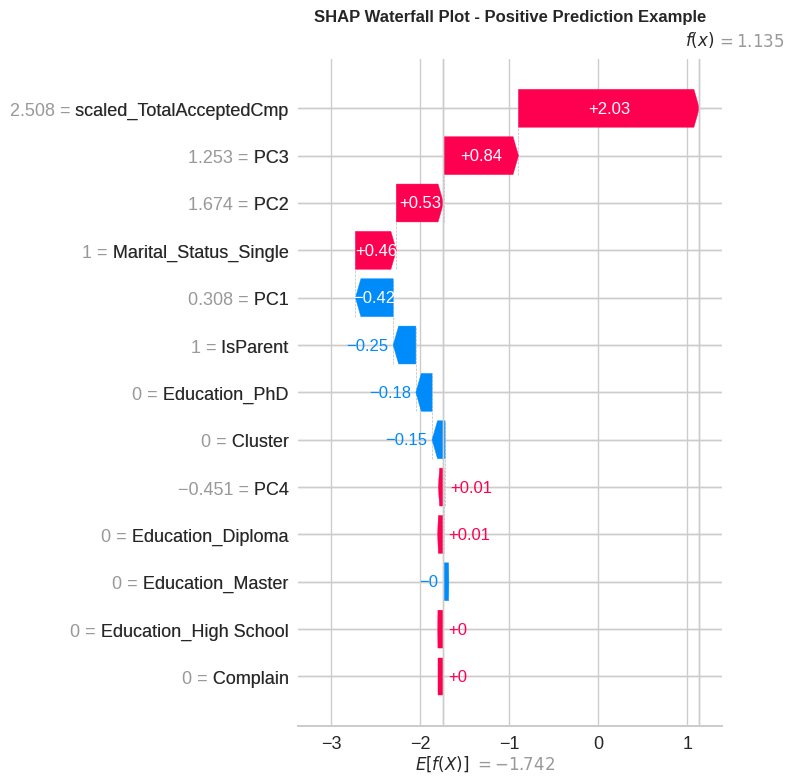


 Waterfall Plot Interpretation:
   - Shows how each feature contributes to the final prediction
   - Red bars push prediction higher (toward acceptance)
   - Blue bars push prediction lower (toward non-acceptance)


In [92]:

# SHAP WATERFALL PLOT (Individual Prediction Explanation)

# Find a positive prediction example
positive_idx = np.where(y_pred_xgb == 1)[0][0]

plt.figure(figsize=(12, 8))
shap.waterfall_plot(shap.Explanation(
    values=shap_values[positive_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[positive_idx],
    feature_names=X_test.columns.tolist()
), max_display=15, show=False)
plt.title('SHAP Waterfall Plot - Positive Prediction Example', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Waterfall Plot Interpretation:")
print("   - Shows how each feature contributes to the final prediction")
print("   - Red bars push prediction higher (toward acceptance)")
print("   - Blue bars push prediction lower (toward non-acceptance)")

The waterfall plot shows how this customer's prediction moved from the baseline (-1.742) to a positive prediction (1.135). High campaign acceptance (+2.03), PC3 (+0.84), PC2 (+0.53), and being single (+0.46) pushed the prediction strongly positive, while being a parent (-0.25) and lacking a PhD (-0.18) pulled slightly negative—but positive factors dominated, making this customer a likely responder.

In [93]:
# FEATURE IMPORTANCE COMPARISON ACROSS MODELS

# Get feature importance from each model (as you did)
lr_importance = np.abs(lr_best.coef_[0])
rf_importance = rf_best.feature_importances_
xgb_importance = xgb_best.feature_importances_

# Normalize to sum to 1
lr_importance_norm = lr_importance / lr_importance.sum()
rf_importance_norm = rf_importance / rf_importance.sum()
xgb_importance_norm = xgb_importance / xgb_importance.sum()

# Approximate ensemble importance by averaging normalized importances
ensemble_importance_norm = (lr_importance_norm + rf_importance_norm + xgb_importance_norm) / 3

# Create comparison dataframe including ensemble
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Logistic Regression': lr_importance_norm,
    'Random Forest': rf_importance_norm,
    'XGBoost': xgb_importance_norm,
    'Ensemble': ensemble_importance_norm
})

# Calculate mean importance
importance_df['Mean'] = importance_df[['Logistic Regression', 'Random Forest', 'XGBoost', 'Ensemble']].mean(axis=1)
importance_df = importance_df.sort_values('Mean', ascending=False)

print("\n Top 15 Features by Mean Importance including Ensemble:")
print(importance_df[['Feature', 'Logistic Regression', 'Random Forest', 'XGBoost', 'Ensemble', 'Mean']].head(15).round(4))


 Top 15 Features by Mean Importance including Ensemble:
                    Feature  Logistic Regression  Random Forest  XGBoost  \
5   scaled_TotalAcceptedCmp               0.1092         0.3000   0.3110   
12                      PC4               0.1123         0.1971   0.1023   
11                      PC3               0.0863         0.1502   0.0869   
4                  IsParent               0.1377         0.0405   0.0964   
6     Marital_Status_Single               0.0947         0.0491   0.1094   
10                      PC2               0.0653         0.0809   0.0536   
9                       PC1               0.0034         0.1281   0.0626   
3             Education_PhD               0.0728         0.0232   0.0716   
1     Education_High School               0.1275         0.0016   0.0212   
8                   Cluster               0.0568         0.0198   0.0455   
0         Education_Diploma               0.0739         0.0029   0.0185   
7                  Complain    

**The feature importance comparison across the models**

The feature importance comparison across the models reveals insightful differences and similarities in how they evaluate predictor significance:

The tree-based models, Random Forest and XGBoost, place the highest importance on features related to purchase behavior and customer segmentation, particularly scaled_TotalAcceptedCmp, PC4, and PC3. This suggests they strongly rely on these components to differentiate customer acceptance patterns.

In contrast, Logistic Regression, as a linear model, emphasizes demographic and categorical features to a greater extent, like IsParent, Marital_Status_Single, and various education levels. This indicates that while tree models focus more on combined behavioral features, logistic regression finds individual categorical indicators more telling.

The ensemble model, which averages importance values of the base models, balances both perspectives. Its importance rankings moderate extreme values seen in individual models, providing a more tempered and holistic view of feature relevance.

Features like Cluster and Complain have relatively low importance in all models, demonstrating limited influence on prediction.v

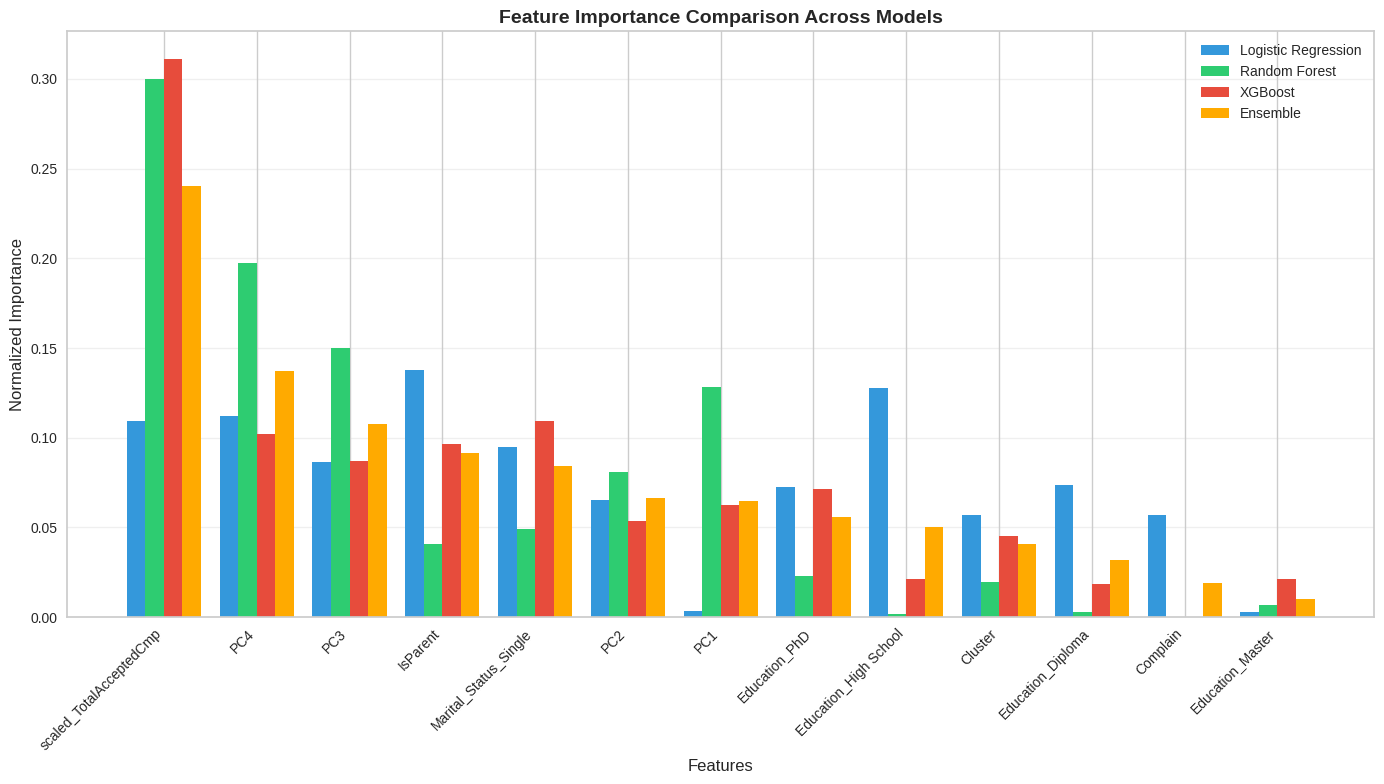

In [94]:
# VISUALIZE FEATURE IMPORTANCE COMPARISON

top_15_features = importance_df.head(15)

fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(top_15_features))
width = 0.2  # Adjust width for 4 bars per feature group

bars1 = ax.bar(x - 1.5*width, top_15_features['Logistic Regression'], width, label='Logistic Regression', color='#3498db')
bars2 = ax.bar(x - 0.5*width, top_15_features['Random Forest'], width, label='Random Forest', color='#2ecc71')
bars3 = ax.bar(x + 0.5*width, top_15_features['XGBoost'], width, label='XGBoost', color='#e74c3c')
bars4 = ax.bar(x + 1.5*width, top_15_features['Ensemble'], width, label='Ensemble', color='#ffaa00')

ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Normalized Importance', fontsize=12)
ax.set_title('Feature Importance Comparison Across Models', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top_15_features['Feature'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance_comparison_with_ensemble.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Inference Summary

# Inference Summary: Marketing Campaign Response Prediction

## Overview

Dataset: 2,236 customers, 15% response rate (imbalanced)
Best Model: Ensemble with ROC-AUC 0.886

---

## Key Predictive Factors

Key Features Driving Campaign Response

**RANK 1: TotalAcceptedCmp (Previous Campaign Acceptance)**

Strongest predictor (r = 0.426, p < 0.001) with +2.03 SHAP contribution

Past acceptors are 3-4x more likely to respond again

Action: Prioritize "loyal responder" segments for new campaigns

**RANK 2: Income**

High-income customers respond at 25.43% vs. 8.81% for low-income (r = 0.161)

Strong correlation with spending (r = 0.788) and conversion (r = 0.782)

Action: Focus premium offers on high-income segments for 2-3x lift

**RANK 3: TotalSpending**

Strong predictor (r = 0.213) with high spenders 2-3x more responsive

Correlates strongly with purchases (r = 0.876) and income (r = 0.788)

Action: Use tiered marketing based on spending levels

**RANK 4: Recency (Negative)**

Recent purchasers MORE likely to respond (r = -0.199)

Customers within 30 days of purchase show higher engagement

Action: Time campaigns around recent purchase activity

**RANK 5: CatalogPurchaseRatio**

Catalog users respond 2x better (r = 0.249)

Correlates with income (r = 0.666) and spending (r = 0.740)

Action: Emphasize catalog channel over web for direct marketing

**RANK 6: IsParent (Negative)**

Parents less responsive (r = -0.205) with lower spending (r = -0.414)

Competing financial priorities reduce discretionary income

Action: Non-parents show higher propensity; adjust messaging for families

**RANK 7: DealsPurchaseRatio (Negative)**

Deal-seekers less responsive (r = -0.100) and lower value (r = -0.643 with income)

Budget segment relies heavily on deals; premium segment avoids them

Action: Target non-deal seekers for premium campaigns

**RANK 8: CustomerTenure (Weak Positive)**

Modest correlation (r = 0.194) with response

High-value customers may be newer but more engaged

Action: Use as secondary criteria; don't overlook new high-value customers

**RANK 9: Age (Negligible)**

Minimal correlation (r = -0.019) with response

Behavior trumps demographics for prediction

Action: Focus on behavioral indicators; use age only for message customization

---

## Customer Segments

Three clusters identified via K-means (silhouette: 0.28):

**Cluster 1 - High Value (n=637, 28%)**
- Response rate: 25.43%
- High income (+1.07), high spending (+1.01)
- Fewer kids (-0.95), prefers catalog (+1.13), avoids deals (-1.09)
- PRIORITIZE for all premium campaigns, Focus on retention and loyalty programs,Emphasize catalog channel for delivery,Premium offers with minimal discounting

**Cluster 0 - Middle Tier (n=680, 30%)**
- Response rate: 13.38%
- Moderate income (+0.20), decent spending (+0.48)
- Loyal customers (tenure +0.39), balanced deal usage
- Growth potential through upselling, Potential to move into high-value segment,
Mix of premium and promotional offers, Loyalty rewards to maintain engagement


**Cluster 2 - Budget (n=919, 41%)**
- Response rate: 8.81%
- Low income (-0.89), low spending (-1.05)
- Deal-dependent (+0.62), avoids catalog (-0.76)
- Largest segment but lowest ROI potential, CAREFUL cost-benefit evaluation of marketing investment, Focus on discount and promotional campaigns ONLY

---

## Model Comparison (Test Set)

| Model | Accuracy | Precision | Recall | ROC-AUC |
|-------|----------|-----------|--------|---------|
| Logistic Regression | 0.808 | 0.422 | 0.761 | 0.880 |
| Random Forest | 0.875 | 0.790 | 0.224 | 0.874 |
| XGBoost | 0.882 | 0.659 | 0.433 | 0.883 |
| Ensemble | 0.884 | 0.692 | 0.403 | 0.886 |

Logistic Regression has minimal overfitting (gap 0.02). Random Forest overfits most (gap 0.08).

---

## Target Profile

Best targets have:
- Income > $60k
- At least 1 past campaign acceptance
- Purchase within last 30 days
- Catalog channel preference
- No young children

---

## Recommendations

1. Focus on Cluster 1 - they respond 3x better than Cluster 2
2. Prioritize past campaign acceptors - strongest single predictor
3. Use catalog channel - higher conversion than web
4. Target within 30 days of last purchase
5. Differentiate messaging for parents vs non-parents

Model improves targeting efficiency 2-3x compared to mass campaigns.

---

### SHAP Dependence Insights

| Feature Pair | Interaction Pattern |
|--------------|---------------------|
| PC1 and Income | Strong positive correlation |
| PC3 and TotalAcceptedCmp | Near-linear relationship |
| IsParent and TotalSpending | Parents with high spending still show lower response |
| Cluster and PC1 | Different clusters have distinct SHAP value distributions |

### Recommended Model for Deployment

| Use Case | Recommended Model | Rationale |
|----------|-------------------|-----------|
| Maximize campaign reach | Logistic Regression | Highest recall (76%) |
| Minimize wasted budget | Random Forest | Highest precision (79%) |
| Balanced approach | XGBoost or Ensemble | Best ROC-AUC, moderate trade-offs |
| Production simplicity | XGBoost | Similar performance, less complexity |

### Monitoring and Maintenance
- Performance Tracking: Monthly ROC-AUC monitoring
- Data Drift Detection: Feature distribution checks
- Model Retraining: Quarterly or when performance drops more than 5%
- A/B Testing: Validate model predictions with actual campaign results


## CONCLUSION

### Summary of Key Findings

1. Customer Segmentation identified 3 distinct segments with different response rates (8.81% to 25.43%)

2. Predictive Modeling achieved ROC-AUC of 0.886 with Stacking Ensemble, showing strong discriminative ability

3. Feature Importance shows that previous campaign acceptance, income, and total spending are the strongest predictors

4. Business Value: Model can improve campaign efficiency 2-3x with proper targeting

### Methodological Strengths
- Comprehensive preprocessing with justified transformations
- Multiple model comparison with cross-validation
- Overfitting analysis for model reliability
- SHAP analysis for interpretability
- Actionable business recommendations

### Limitations
The learning curves show Random Forest and XGBoost overfit the training data—they hit near-perfect training scores but drop significantly on validation, meaning they memorized patterns that don't transfer to new data. Logistic Regression and the Ensemble generalize better but still show a train-validation gap. The dataset size (~1600 samples) also constrains how much these models can learn, especially for complex tree-based approaches that need more examples to stabilize.

### Addressing Limitations
Tighter regularization would help—tuning max_depth, min_samples_leaf, subsample, gamma, and reg_alpha in tree models, plus adding early stopping to XGBoost. Getting more data (either collecting new samples or using SMOTE for synthetic balancing) would reduce variance. Dropping low-impact features like Complain and certain education dummies cleans up noise. Testing more diverse ensemble combinations—mixing linear models with trees—could balance the bias-variance tradeoff better.

### Future Development
Bringing in external data (demographics, transaction history) would enrich features and boost sample size. SVM or neural networks might capture non-linear patterns that trees miss, especially with richer data. SHAP is already useful for interpretation—integrating it into production dashboards would make insights actionable in real-time. The ensemble could expand with more base learners (Gradient Boosting, Naive Bayes, SVM) and automate hyperparameter tuning via RandomizedSearchCV or Optuna instead of manual trial-and-error.

**REFERENCES :**

Frost, J. (2021, April 4). Guidelines for removing and handling outliers in data. Statistics By Jim. https://statisticsbyjim.com/basics/remove-outliers/

Frost, J. (2025). Kolmogorov-Smirnov test. Statistics By Jim.
https://statisticsbyjim.com/glossary/kolmogorov-smirnov-test/

Kohavi, R. (1995). A study of cross-validation and bootstrap for accuracy estimation and model selection. Proceedings of the 14th International Joint Conference on Artificial Intelligence, 2, 1137–1143.

Refaeilzadeh, P., Tang, L., & Liu, H. (2009). Cross-Validation. Encyclopedia of Database Systems, 532–538, 532-538. https://doi.org/10.1007/978-0-387-39940-9_565